# 05_Advanced_EDA

## Objective

Perform comprehensive exploratory data analysis to understand the distribution, trends, relationships and spatial-temporal behaviour of air pollutants across Indian cities. The insights generated in this notebook will guide feature selection and machine learning model development.

In [1]:
# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

# File handling
from pathlib import Path

# Numerical computing
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Interactive visualization
import plotly.express as px
import plotly.graph_objects as go
from matplotlib.ticker import FuncFormatter

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

In [2]:
# Project directory
PROJECT_DIR = Path("../")

# Data directory
DATA_DIR = PROJECT_DIR / "data"

# Report directory
REPORT_DIR = PROJECT_DIR / "reports"

# Input dataset
INPUT_PATH = DATA_DIR / "processed" / "feature_engineered_airintel.parquet"

## Configure Visualization Style


In [3]:
# Professional pastel palette
PALETTE = [

    "#7FB3D5",
    "#82E0AA",
    "#F8C471",
    "#F1948A",
    "#BB8FCE",
    "#73C6B6",
    "#F7DC6F",
    "#AED6F1"

]

# Seaborn theme
sns.set_theme(

    style="whitegrid",
    palette=PALETTE,
    font_scale=1.05

)

# Figure settings
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

# Plotly theme
PLOTLY_TEMPLATE = "plotly_white"

# Common figure sizes
FIG_SIZE = (10, 6)
LARGE_FIG = (14, 7)
HEATMAP_SIZE = (12, 8)

In [4]:
# Load feature engineered dataset
df = pd.read_parquet(INPUT_PATH)

# Display dataset information
print(f"Dataset Shape : {df.shape}")

df.head()

Dataset Shape : (842160, 248)


,City,State,Latitude,Longitude,Datetime,Year,Month,Day,Hour,Day_of_Week,Day_Name,Week_of_Year,Is_Weekend,Quarter,Season,Time_of_Day,Temp_2m_C,Humidity_Percent,Dew_Point_C,Humidity_Category,Wind_Speed_10m_kmh,Wind_Dir_10m,Wind_Gusts_kmh,Wind_Category,Wind_Stagnation,Precipitation_mm,Rain_mm,Is_Raining,Heavy_Rain,Pressure_MSL_hPa,Surface_Pressure_hPa,Solar_Radiation_Wm2,Direct_Radiation_Wm2,Diffuse_Radiation_Wm2,Cloud_Cover_Percent,Cloud_Low_Percent,Cloud_Mid_Percent,Cloud_High_Percent,Is_Daytime,Sunshine_Seconds,PM2_5_ugm3,PM10_ugm3,PM_Ratio,CO_ugm3,NO2_ugm3,SO2_ugm3,O3_ugm3,Dust_ugm3,AOD,US_AQI,US_AQI_PM25,US_AQI_PM10,US_AQI_NO2,US_AQI_O3,US_AQI_CO,EU_AQI,EU_AQI_PM25,EU_AQI_PM10,AQI_Category,PM25_Category_India,Temp_Inversion,Festival_Period,Crop_Burning_Season,Date,Week,Day_of_Month,Day_of_Year,Week_of_Month,Days_in_Month,Is_Month_Start,Is_Month_End,Is_Quarter_Start,Is_Quarter_End,Hour_Sin,Hour_Cos,Month_Sin,Month_Cos,Weekday_Sin,Weekday_Cos,Total_Pollution,Mean_Pollution,Maximum_Pollution,Minimum_Pollution,Pollution_Range,Pollution_Count,PM_Difference,CO_NO2_Ratio,PM25_NO2_Ratio,O3_NO2_Ratio,Dominant_Pollutant,Temp_Dew_Diff,Pressure_Difference,High_Wind,Heavy_Cloud,Dry_Day,Weather_Stress_Index,Temp_Humidity,Temp_Wind,Rain_PM10,Wind_PM25,Solar_O3,Humidity_PM25,Wind_Gust_Ratio,Latitude_Band,Longitude_Band,Coastal_State,Northern_India,Inland_State,Absolute_Latitude,Lat_Long_Interaction,PM2_5_ugm3_Lag_1H,PM2_5_ugm3_Lag_3H,PM2_5_ugm3_Lag_6H,PM2_5_ugm3_Lag_12H,PM2_5_ugm3_Lag_24H,PM10_ugm3_Lag_1H,PM10_ugm3_Lag_3H,PM10_ugm3_Lag_6H,PM10_ugm3_Lag_12H,PM10_ugm3_Lag_24H,CO_ugm3_Lag_1H,CO_ugm3_Lag_3H,CO_ugm3_Lag_6H,CO_ugm3_Lag_12H,CO_ugm3_Lag_24H,NO2_ugm3_Lag_1H,NO2_ugm3_Lag_3H,NO2_ugm3_Lag_6H,NO2_ugm3_Lag_12H,NO2_ugm3_Lag_24H,SO2_ugm3_Lag_1H,SO2_ugm3_Lag_3H,SO2_ugm3_Lag_6H,SO2_ugm3_Lag_12H,SO2_ugm3_Lag_24H,O3_ugm3_Lag_1H,O3_ugm3_Lag_3H,O3_ugm3_Lag_6H,O3_ugm3_Lag_12H,O3_ugm3_Lag_24H,PM2_5_ugm3_RollingMean_6H,PM2_5_ugm3_RollingStd_6H,PM2_5_ugm3_RollingMean_12H,PM2_5_ugm3_RollingStd_12H,PM2_5_ugm3_RollingMean_24H,PM2_5_ugm3_RollingStd_24H,PM10_ugm3_RollingMean_6H,PM10_ugm3_RollingStd_6H,PM10_ugm3_RollingMean_12H,PM10_ugm3_RollingStd_12H,PM10_ugm3_RollingMean_24H,PM10_ugm3_RollingStd_24H,CO_ugm3_RollingMean_6H,CO_ugm3_RollingStd_6H,CO_ugm3_RollingMean_12H,CO_ugm3_RollingStd_12H,CO_ugm3_RollingMean_24H,CO_ugm3_RollingStd_24H,NO2_ugm3_RollingMean_6H,NO2_ugm3_RollingStd_6H,NO2_ugm3_RollingMean_12H,NO2_ugm3_RollingStd_12H,NO2_ugm3_RollingMean_24H,NO2_ugm3_RollingStd_24H,SO2_ugm3_RollingMean_6H,SO2_ugm3_RollingStd_6H,SO2_ugm3_RollingMean_12H,SO2_ugm3_RollingStd_12H,SO2_ugm3_RollingMean_24H,SO2_ugm3_RollingStd_24H,O3_ugm3_RollingMean_6H,O3_ugm3_RollingStd_6H,O3_ugm3_RollingMean_12H,O3_ugm3_RollingStd_12H,O3_ugm3_RollingMean_24H,O3_ugm3_RollingStd_24H,PM2_5_ugm3_RollingMin_6H,PM2_5_ugm3_RollingMax_6H,PM2_5_ugm3_RollingMin_12H,PM2_5_ugm3_RollingMax_12H,PM2_5_ugm3_RollingMin_24H,PM2_5_ugm3_RollingMax_24H,PM10_ugm3_RollingMin_6H,PM10_ugm3_RollingMax_6H,PM10_ugm3_RollingMin_12H,PM10_ugm3_RollingMax_12H,PM10_ugm3_RollingMin_24H,PM10_ugm3_RollingMax_24H,CO_ugm3_RollingMin_6H,CO_ugm3_RollingMax_6H,CO_ugm3_RollingMin_12H,CO_ugm3_RollingMax_12H,CO_ugm3_RollingMin_24H,CO_ugm3_RollingMax_24H,NO2_ugm3_RollingMin_6H,NO2_ugm3_RollingMax_6H,NO2_ugm3_RollingMin_12H,NO2_ugm3_RollingMax_12H,NO2_ugm3_RollingMin_24H,NO2_ugm3_RollingMax_24H,SO2_ugm3_RollingMin_6H,SO2_ugm3_RollingMax_6H,SO2_ugm3_RollingMin_12H,SO2_ugm3_RollingMax_12H,SO2_ugm3_RollingMin_24H,SO2_ugm3_RollingMax_24H,O3_ugm3_RollingMin_6H,O3_ugm3_RollingMax_6H,O3_ugm3_RollingMin_12H,O3_ugm3_RollingMax_12H,O3_ugm3_RollingMin_24H,O3_ugm3_RollingMax_24H,PM2_5_ugm3_EMA_6H,PM2_5_ugm3_EMA_12H,PM2_5_ugm3_EMA_24H,PM10_ugm3_EMA_6H,PM10_ugm3_EMA_12H,PM10_ugm3_EMA_24H,CO_ugm3_EMA_6H,CO_ugm3_EMA_12H,CO_ugm3_EMA_24H,NO2_ugm3_EMA_6H,NO2_ugm3_EMA_12H,NO2_ugm3_EMA_24H,SO2_ugm3_EMA_6H,SO2_ugm3_EMA_12H,SO2_ugm3_EMA_24H,O3_ugm3_EMA_6H,O3_ugm3_EMA_12H,O3_ugm3_EMA_24H,PM2_5_ugm3_Change,PM2_5_ugm3_PctChange,PM10_ugm3_Change,PM

In [25]:
# Preview dataset
df.sample(5)

,City,State,Latitude,Longitude,Datetime,Year,Month,Day,Hour,Day_of_Week,Day_Name,Week_of_Year,Is_Weekend,Quarter,Season,Time_of_Day,Temp_2m_C,Humidity_Percent,Dew_Point_C,Humidity_Category,Wind_Speed_10m_kmh,Wind_Dir_10m,Wind_Gusts_kmh,Wind_Category,Wind_Stagnation,Precipitation_mm,Rain_mm,Is_Raining,Heavy_Rain,Pressure_MSL_hPa,Surface_Pressure_hPa,Solar_Radiation_Wm2,Direct_Radiation_Wm2,Diffuse_Radiation_Wm2,Cloud_Cover_Percent,Cloud_Low_Percent,Cloud_Mid_Percent,Cloud_High_Percent,Is_Daytime,Sunshine_Seconds,PM2_5_ugm3,PM10_ugm3,PM_Ratio,CO_ugm3,NO2_ugm3,SO2_ugm3,O3_ugm3,Dust_ugm3,AOD,US_AQI,US_AQI_PM25,US_AQI_PM10,US_AQI_NO2,US_AQI_O3,US_AQI_CO,EU_AQI,EU_AQI_PM25,EU_AQI_PM10,AQI_Category,PM25_Category_India,Temp_Inversion,Festival_Period,Crop_Burning_Season,Date,Week,Day_of_Month,Day_of_Year,Week_of_Month,Days_in_Month,Is_Month_Start,Is_Month_End,Is_Quarter_Start,Is_Quarter_End,Hour_Sin,Hour_Cos,Month_Sin,Month_Cos,Weekday_Sin,Weekday_Cos,Total_Pollution,Mean_Pollution,Maximum_Pollution,Minimum_Pollution,Pollution_Range,Pollution_Count,PM_Difference,CO_NO2_Ratio,PM25_NO2_Ratio,O3_NO2_Ratio,Dominant_Pollutant,Temp_Dew_Diff,Pressure_Difference,High_Wind,Heavy_Cloud,Dry_Day,Weather_Stress_Index,Temp_Humidity,Temp_Wind,Rain_PM10,Wind_PM25,Solar_O3,Humidity_PM25,Wind_Gust_Ratio,Latitude_Band,Longitude_Band,Coastal_State,Northern_India,Inland_State,Absolute_Latitude,Lat_Long_Interaction,PM2_5_ugm3_Lag_1H,PM2_5_ugm3_Lag_3H,PM2_5_ugm3_Lag_6H,PM2_5_ugm3_Lag_12H,PM2_5_ugm3_Lag_24H,PM10_ugm3_Lag_1H,PM10_ugm3_Lag_3H,PM10_ugm3_Lag_6H,PM10_ugm3_Lag_12H,PM10_ugm3_Lag_24H,CO_ugm3_Lag_1H,CO_ugm3_Lag_3H,CO_ugm3_Lag_6H,CO_ugm3_Lag_12H,CO_ugm3_Lag_24H,NO2_ugm3_Lag_1H,NO2_ugm3_Lag_3H,NO2_ugm3_Lag_6H,NO2_ugm3_Lag_12H,NO2_ugm3_Lag_24H,SO2_ugm3_Lag_1H,SO2_ugm3_Lag_3H,SO2_ugm3_Lag_6H,SO2_ugm3_Lag_12H,SO2_ugm3_Lag_24H,O3_ugm3_Lag_1H,O3_ugm3_Lag_3H,O3_ugm3_Lag_6H,O3_ugm3_Lag_12H,O3_ugm3_Lag_24H,PM2_5_ugm3_RollingMean_6H,PM2_5_ugm3_RollingStd_6H,PM2_5_ugm3_RollingMean_12H,PM2_5_ugm3_RollingStd_12H,PM2_5_ugm3_RollingMean_24H,PM2_5_ugm3_RollingStd_24H,PM10_ugm3_RollingMean_6H,PM10_ugm3_RollingStd_6H,PM10_ugm3_RollingMean_12H,PM10_ugm3_RollingStd_12H,PM10_ugm3_RollingMean_24H,PM10_ugm3_RollingStd_24H,CO_ugm3_RollingMean_6H,CO_ugm3_RollingStd_6H,CO_ugm3_RollingMean_12H,CO_ugm3_RollingStd_12H,CO_ugm3_RollingMean_24H,CO_ugm3_RollingStd_24H,NO2_ugm3_RollingMean_6H,NO2_ugm3_RollingStd_6H,NO2_ugm3_RollingMean_12H,NO2_ugm3_RollingStd_12H,NO2_ugm3_RollingMean_24H,NO2_ugm3_RollingStd_24H,SO2_ugm3_RollingMean_6H,SO2_ugm3_RollingStd_6H,SO2_ugm3_RollingMean_12H,SO2_ugm3_RollingStd_12H,SO2_ugm3_RollingMean_24H,SO2_ugm3_RollingStd_24H,O3_ugm3_RollingMean_6H,O3_ugm3_RollingStd_6H,O3_ugm3_RollingMean_12H,O3_ugm3_RollingStd_12H,O3_ugm3_RollingMean_24H,O3_ugm3_RollingStd_24H,PM2_5_ugm3_RollingMin_6H,PM2_5_ugm3_RollingMax_6H,PM2_5_ugm3_RollingMin_12H,PM2_5_ugm3_RollingMax_12H,PM2_5_ugm3_RollingMin_24H,PM2_5_ugm3_RollingMax_24H,PM10_ugm3_RollingMin_6H,PM10_ugm3_RollingMax_6H,PM10_ugm3_RollingMin_12H,PM10_ugm3_RollingMax_12H,PM10_ugm3_RollingMin_24H,PM10_ugm3_RollingMax_24H,CO_ugm3_RollingMin_6H,CO_ugm3_RollingMax_6H,CO_ugm3_RollingMin_12H,CO_ugm3_RollingMax_12H,CO_ugm3_RollingMin_24H,CO_ugm3_RollingMax_24H,NO2_ugm3_RollingMin_6H,NO2_ugm3_RollingMax_6H,NO2_ugm3_RollingMin_12H,NO2_ugm3_RollingMax_12H,NO2_ugm3_RollingMin_24H,NO2_ugm3_RollingMax_24H,SO2_ugm3_RollingMin_6H,SO2_ugm3_RollingMax_6H,SO2_ugm3_RollingMin_12H,SO2_ugm3_RollingMax_12H,SO2_ugm3_RollingMin_24H,SO2_ugm3_RollingMax_24H,O3_ugm3_RollingMin_6H,O3_ugm3_RollingMax_6H,O3_ugm3_RollingMin_12H,O3_ugm3_RollingMax_12H,O3_ugm3_RollingMin_24H,O3_ugm3_RollingMax_24H,PM2_5_ugm3_EMA_6H,PM2_5_ugm3_EMA_12H,PM2_5_ugm3_EMA_24H,PM10_ugm3_EMA_6H,PM10_ugm3_EMA_12H,PM10_ugm3_EMA_24H,CO_ugm3_EMA_6H,CO_ugm3_EMA_12H,CO_ugm3_EMA_24H,NO2_ugm3_EMA_6H,NO2_ugm3_EMA_12H,NO2_ugm3_EMA_24H,SO2_ugm3_EMA_6H,SO2_ugm3_EMA_12H,SO2_ugm3_EMA_24H,O3_ugm3_EMA_6H,O3_ugm3_EMA_12H,O3_ugm3_EMA_24H,PM2_5_ugm3_Change,PM2_5_ugm3_PctChange,PM10_ugm3_Change,PM

In [6]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 842160 entries, 0 to 842159
Columns: 248 entries, City to O3_ugm3_Volatility_24H
dtypes: category(2), datetime64[ns](1), float64(196), int32(4), int64(34), object(11)
memory usage: 1.5+ GB


In [26]:
# Dataset statistics
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Latitude,842160.00,23.13,8.52,20.30,23.83,26.91,31.10,5.54
Longitude,842160.00,82.77,72.57,77.17,80.95,88.61,94.11,6.94
Datetime,842160,2024-03-31 23:30:00,2022-08-05 00:00:00,2023-06-03 11:45:00,2024-03-31 23:30:00,2025-01-28 11:15:00,2025-11-26 23:00:00,NaN
Year,842160.00,2023.72,2022.00,2023.00,2024.00,2025.00,2025.00,1.00
Month,842160.00,6.80,1.00,4.00,7.00,10.00,12.00,3.41
...,...,...,...,...,...,...,...,...
PM10_ugm3_Volatility_24H,842131.00,14.73,0.05,5.07,8.71,15.50,911.24,28.32
CO_ugm3_Volatility_24H,842131.00,142.04,0.00,43.27,83.71,161.49,4983.65,202.47
NO2_ugm3_Volatility_24H,842131.00,9.12,0.00,3.22,6.16,11.63,96.65,8.97
SO2_ugm3_Volatility_24H,842131.00,4.26,0.00,0.92,2.11,4.75,124.66,6.80


In [9]:
# Dataset summary

dataset_summary = pd.DataFrame({

    "Metric":[

        "Rows",
        "Columns",
        "Cities",
        "States",
        "Numerical Columns",
        "Categorical Columns",
        "Datetime Range",
        "Memory Usage (MB)"

    ],

    "Value":[

        len(df),

        df.shape[1],

        df["City"].nunique(),

        df["State"].nunique(),

        len(df.select_dtypes(include=np.number).columns),

        len(df.select_dtypes(exclude=np.number).columns),

        f"{df['Datetime'].min()}  →  {df['Datetime'].max()}",

        round(
            df.memory_usage(deep=True).sum()/1024**2,
            2
        )

    ]

})

dataset_summary

,Metric,Value
0,Rows,842160
1,Columns,248
2,Cities,29
3,States,29
4,Numerical Columns,234
5,Categorical Columns,14
6,Datetime Range,2022-08-05 00:00:00 → 2025-11-26 23:00:00
7,Memory Usage (MB),1986.17


## 1. Missing Value Analysis


In [10]:
# Missing value summary

missing_summary = pd.DataFrame({

    "Missing Values":df.isna().sum(),

    "Missing %":(
        df.isna().mean()*100
    ).round(2)

})

missing_summary = (

    missing_summary

    .query("`Missing Values`>0")

    .sort_values(

        "Missing Values",
        ascending=False

    )

)

missing_summary

,Missing Values,Missing %
O3_ugm3_PctChange,3671,0.44
AQI_Category,2516,0.30
NO2_ugm3_PctChange,2292,0.27
CO_ugm3_Lag_24H,696,0.08
PM10_ugm3_Lag_24H,696,0.08
PM2_5_ugm3_Lag_24H,696,0.08
SO2_ugm3_Lag_24H,696,0.08
NO2_ugm3_Lag_24H,696,0.08
O3_ugm3_Lag_24H,696,0.08
SO2_ugm3_PctChange,540,0.06


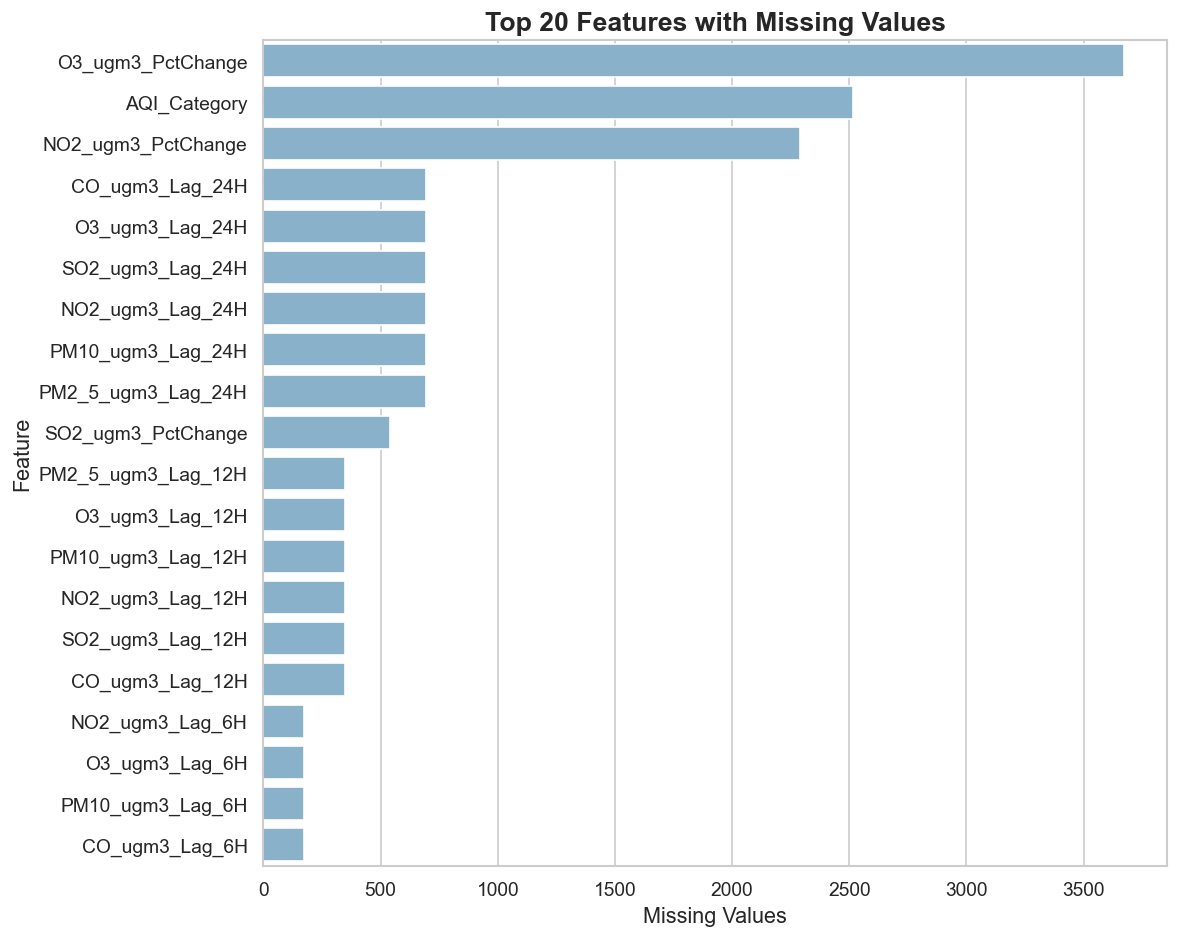

In [19]:
# Top 20 features with missing values

missing_top20 = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .head(20)
)

plt.figure(figsize=(10, 8))

sns.barplot(
    x=missing_top20.values,
    y=missing_top20.index,
    color=PALETTE[0]
)

plt.title("Top 20 Features with Missing Values")

plt.xlabel("Missing Values")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

## 2. Univariate Analysis

Univariate analysis helps understand the distribution, spread and variability of individual variables before exploring relationships between multiple variables.

In [13]:
# Pollutant columns

pollutant_cols = [

    "PM2_5_ugm3",
    "PM10_ugm3",
    "NO2_ugm3",
    "SO2_ugm3",
    "CO_ugm3",
    "O3_ugm3"

]

weather_cols = [

    "Temp_2m_C",
    "Humidity_Percent",
    "Pressure_MSL_hPa",
    "Wind_Speed_10m_kmh"

]

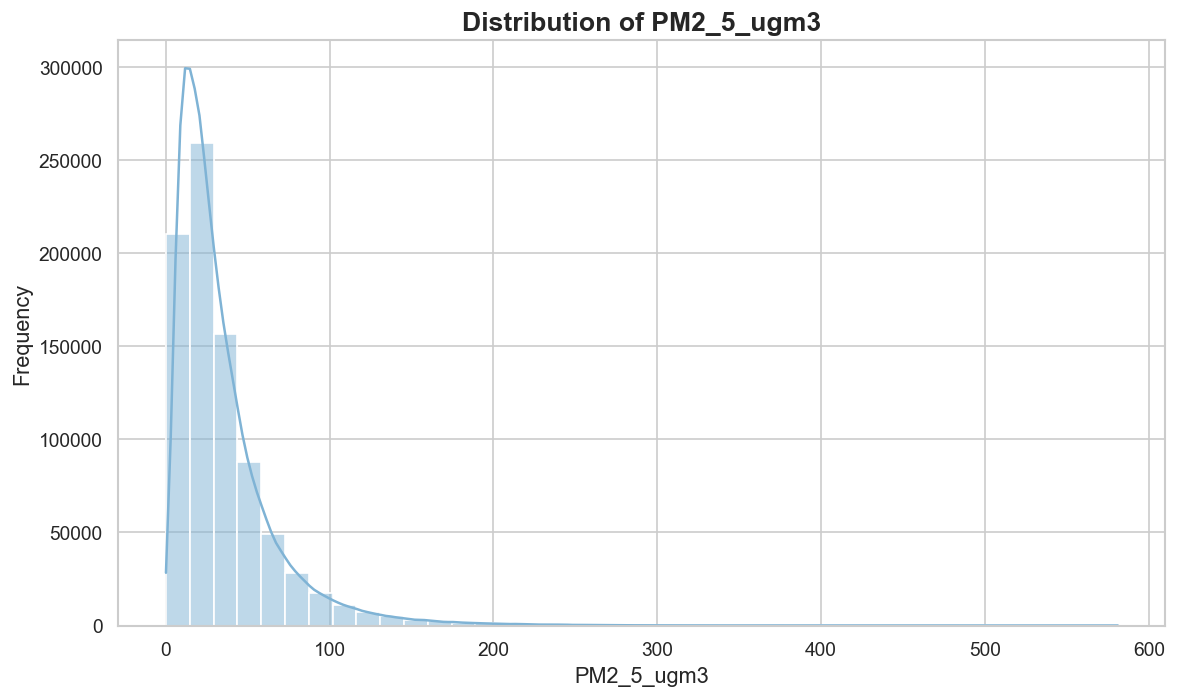

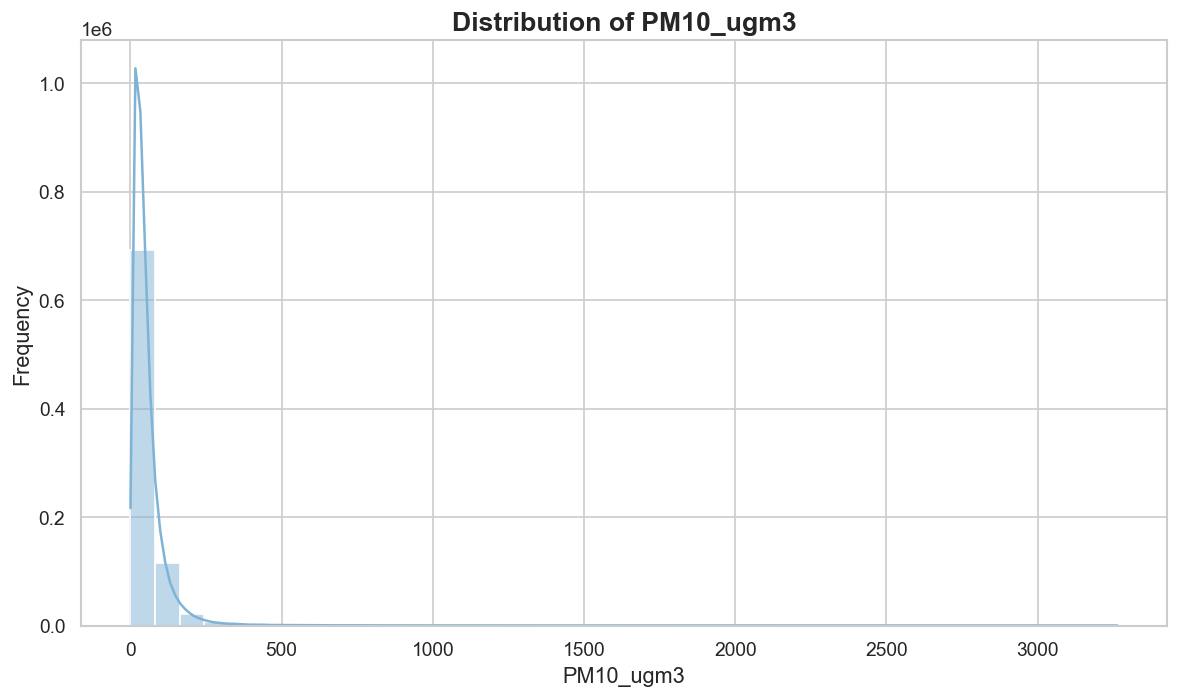

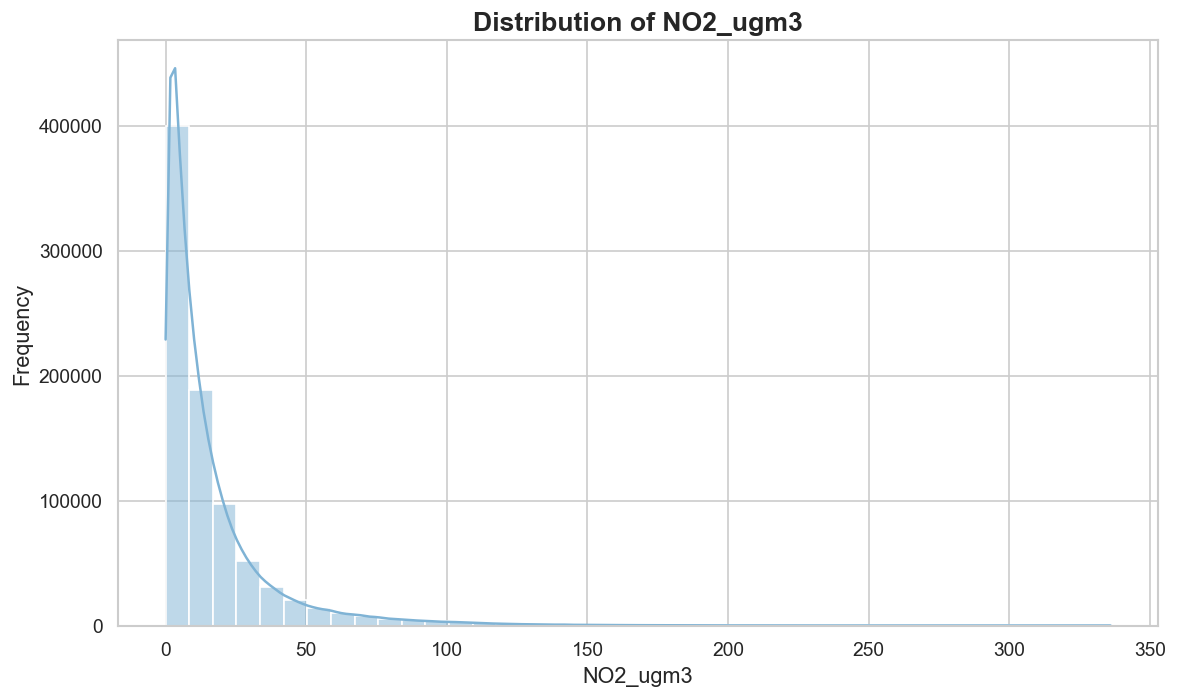

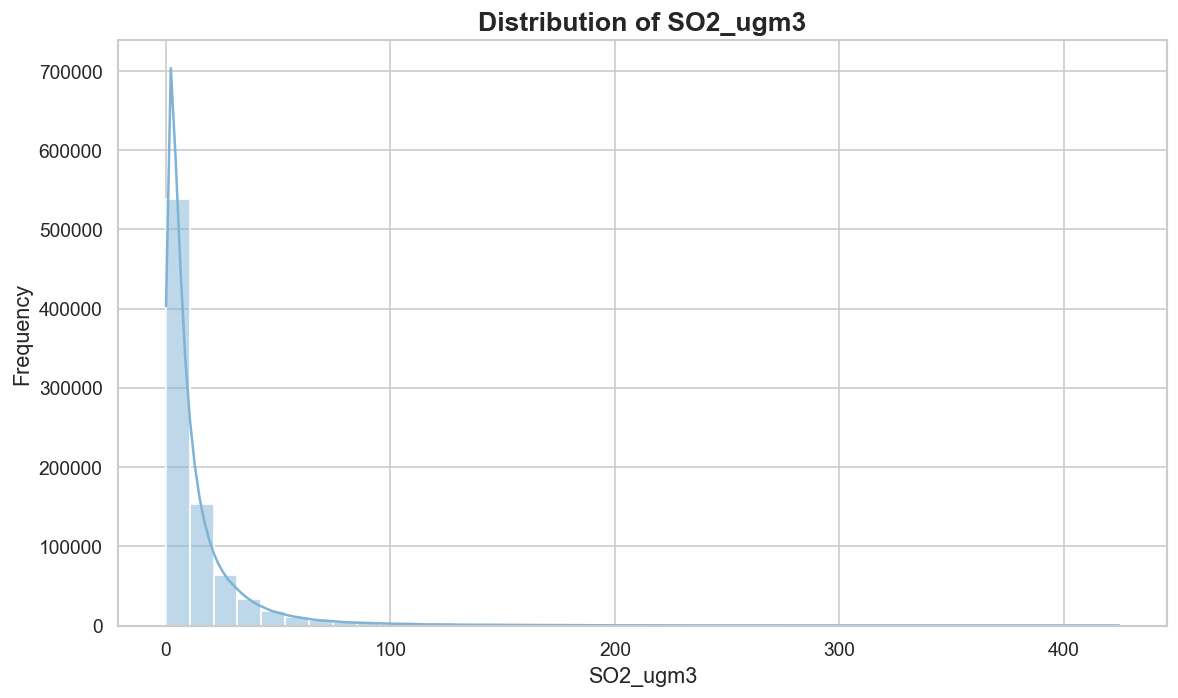

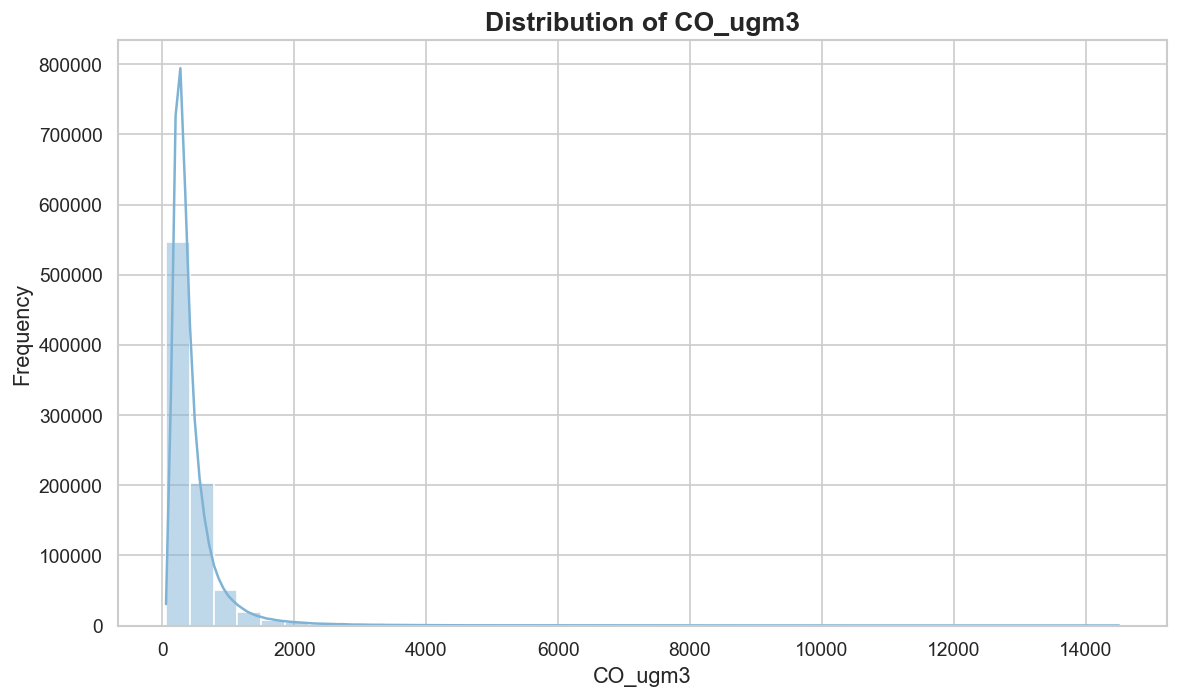

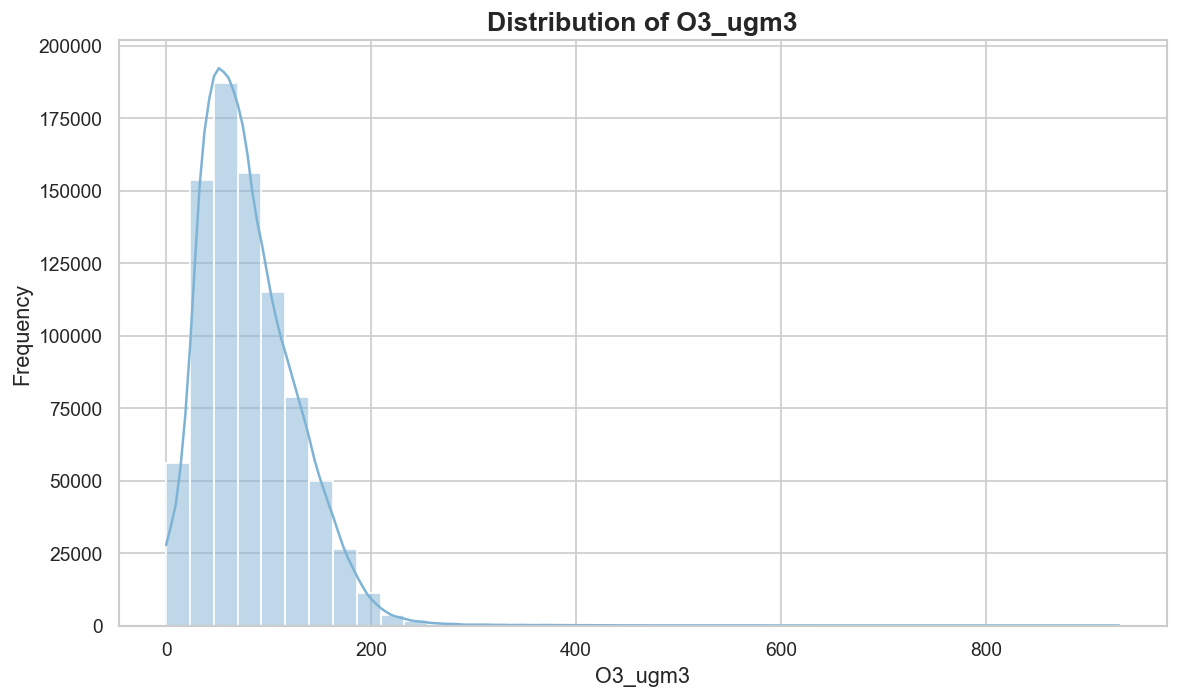

In [14]:
# Distribution plots for pollutants

for col in pollutant_cols:

    plt.figure(figsize=FIG_SIZE)

    sns.histplot(

        data=df,

        x=col,

        kde=True,

        bins=40,

        color=PALETTE[0]

    )

    plt.title(f"Distribution of {col}")

    plt.xlabel(col)

    plt.ylabel("Frequency")

    plt.tight_layout()

    plt.show()

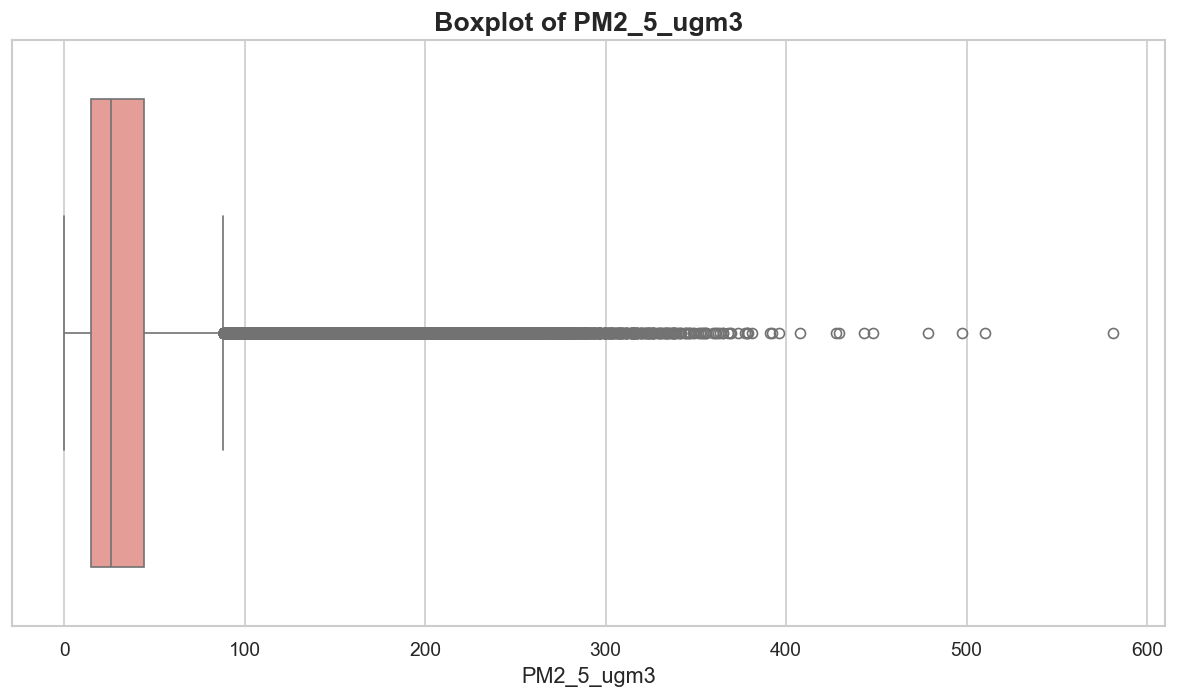

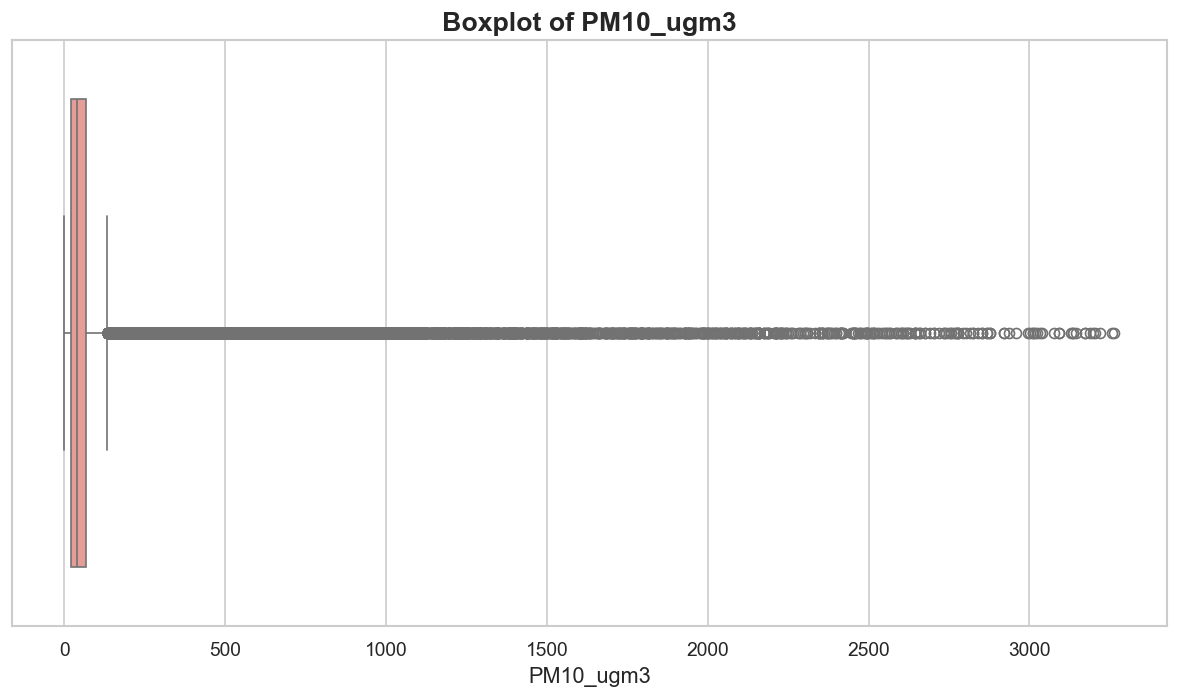

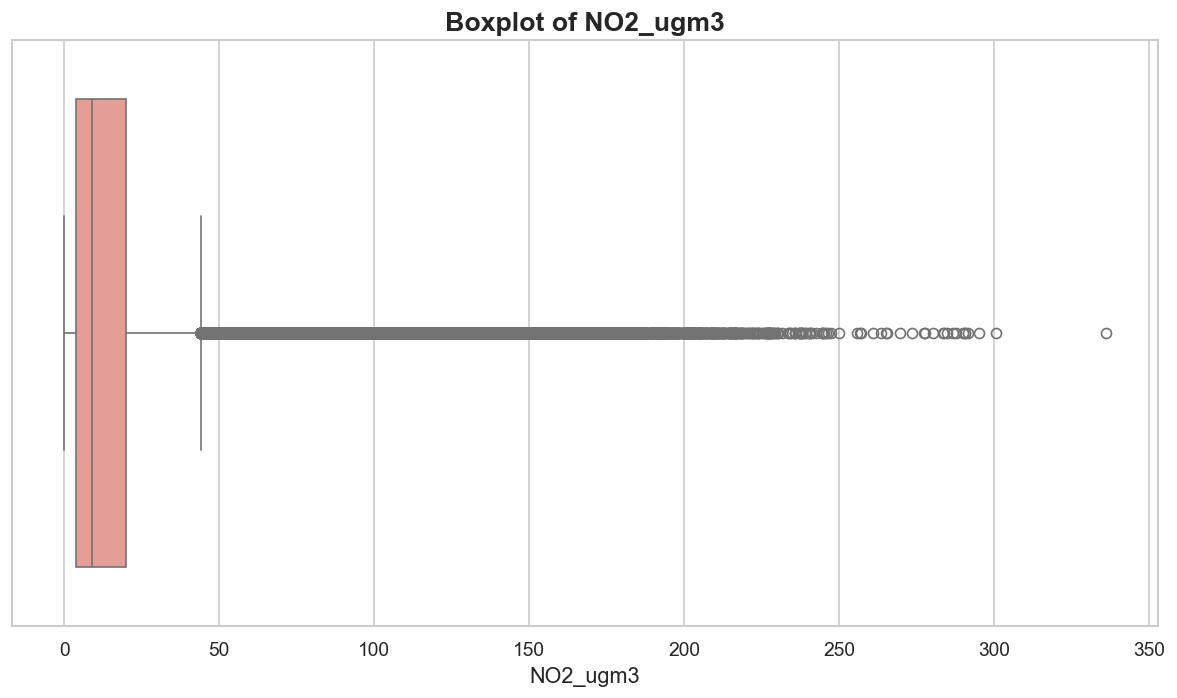

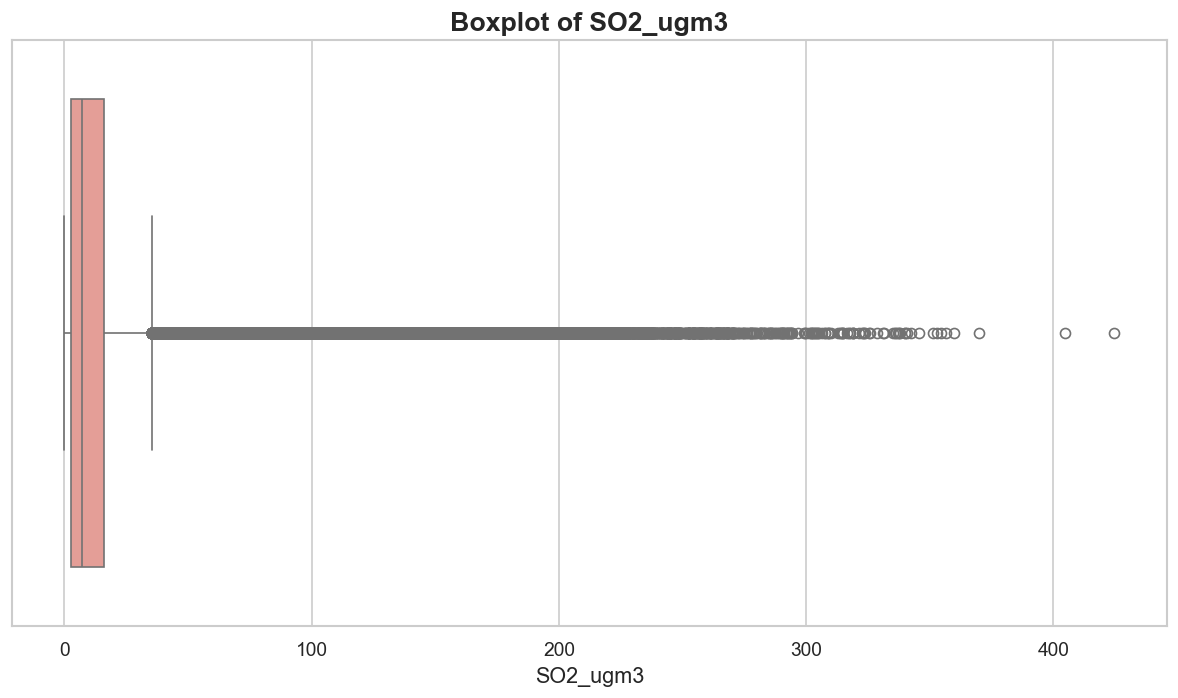

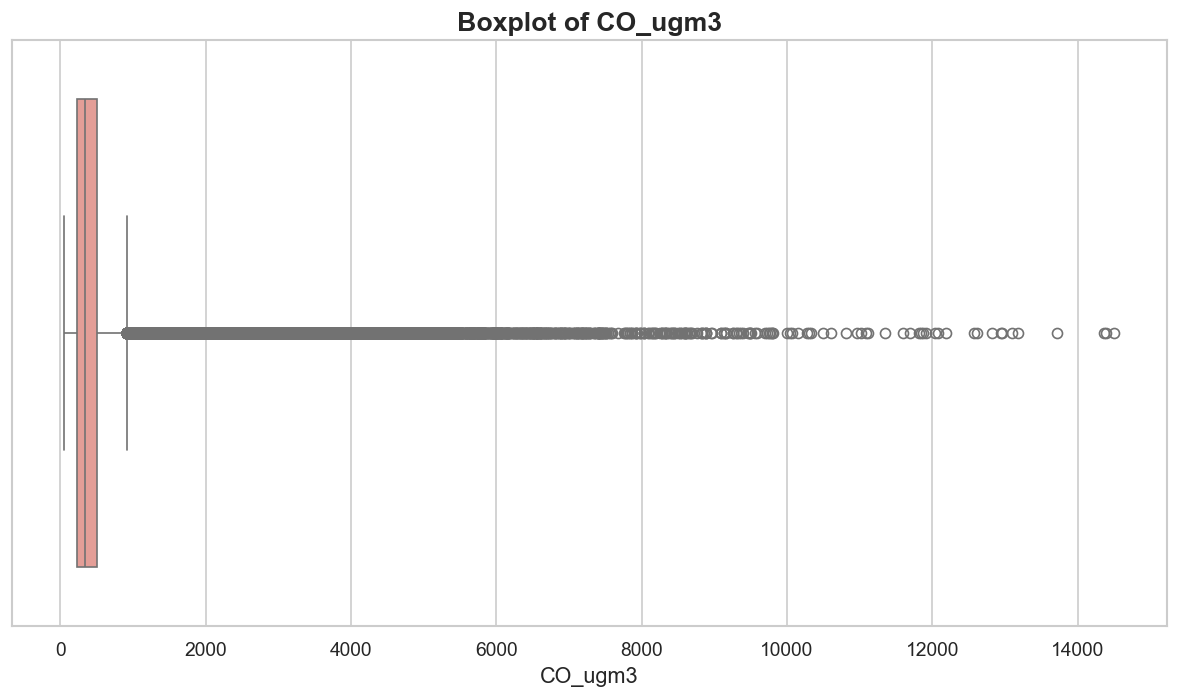

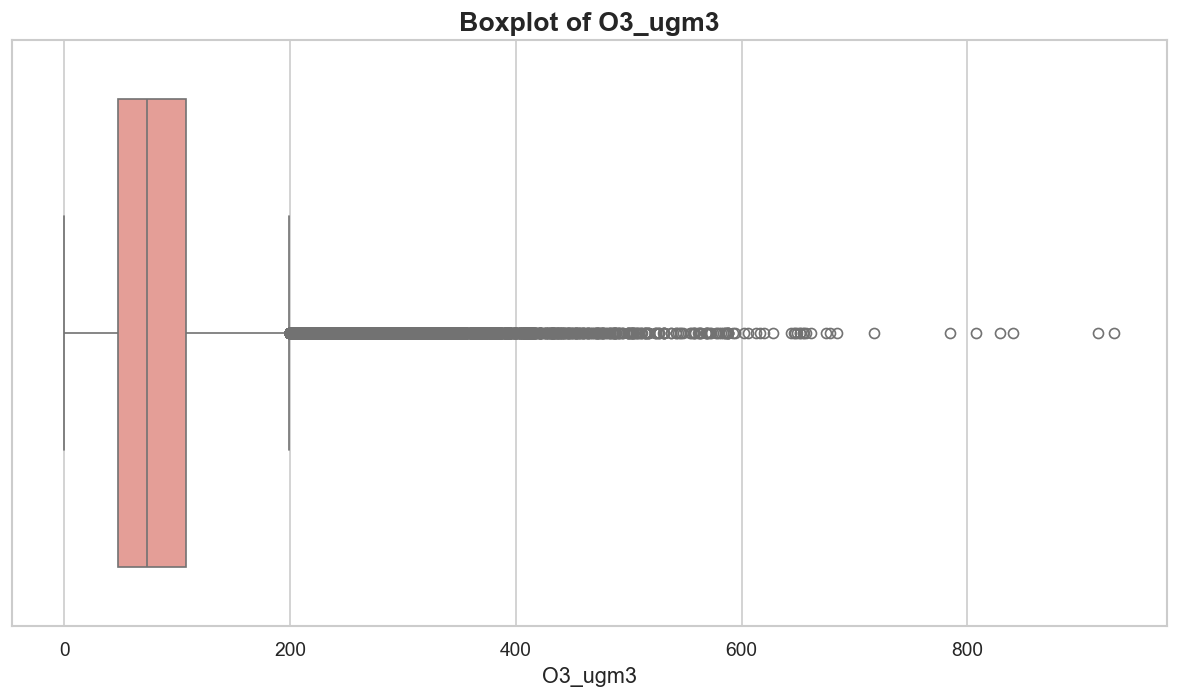

In [15]:
# Boxplots of Air Pollutants

for col in pollutant_cols:

    plt.figure(figsize=FIG_SIZE)

    sns.boxplot(

        x=df[col],

        color=PALETTE[3]

    )

    plt.title(f"Boxplot of {col}")

    plt.xlabel(col)

    plt.tight_layout()

    plt.show()

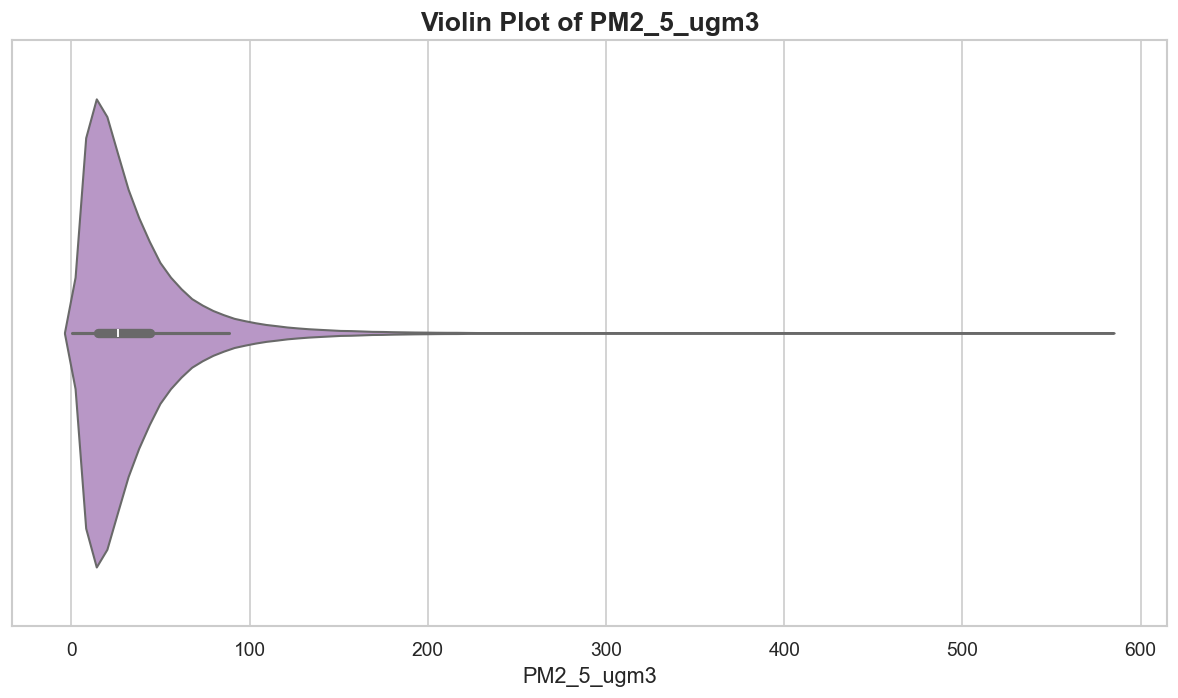

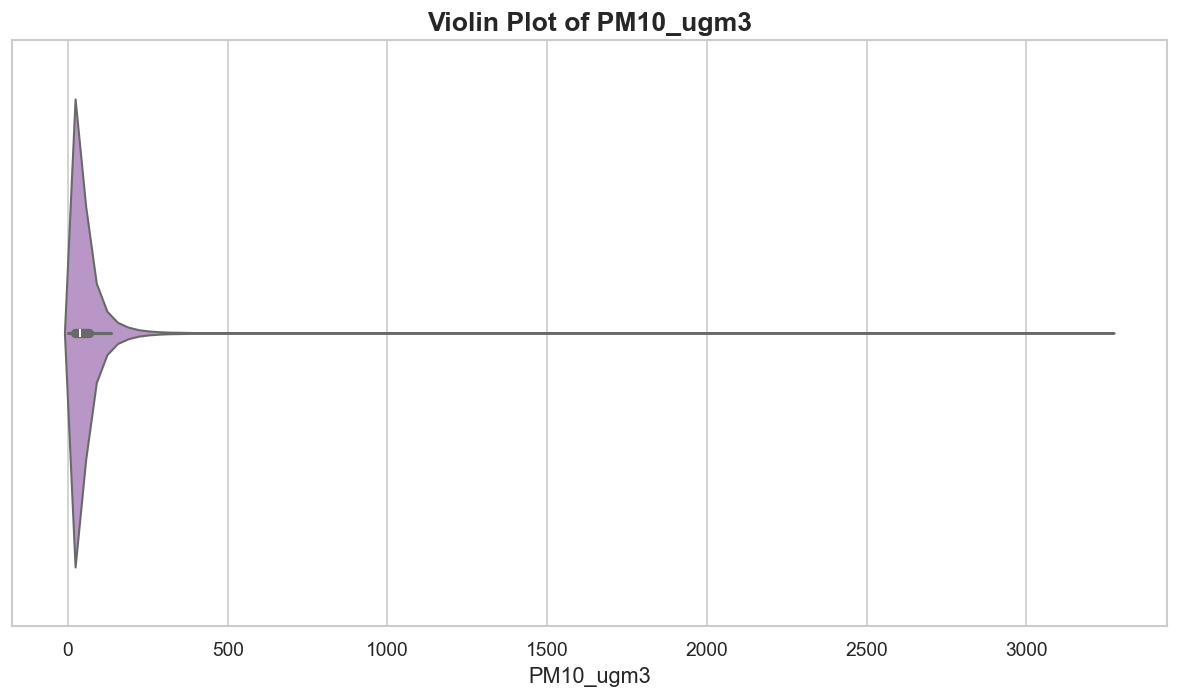

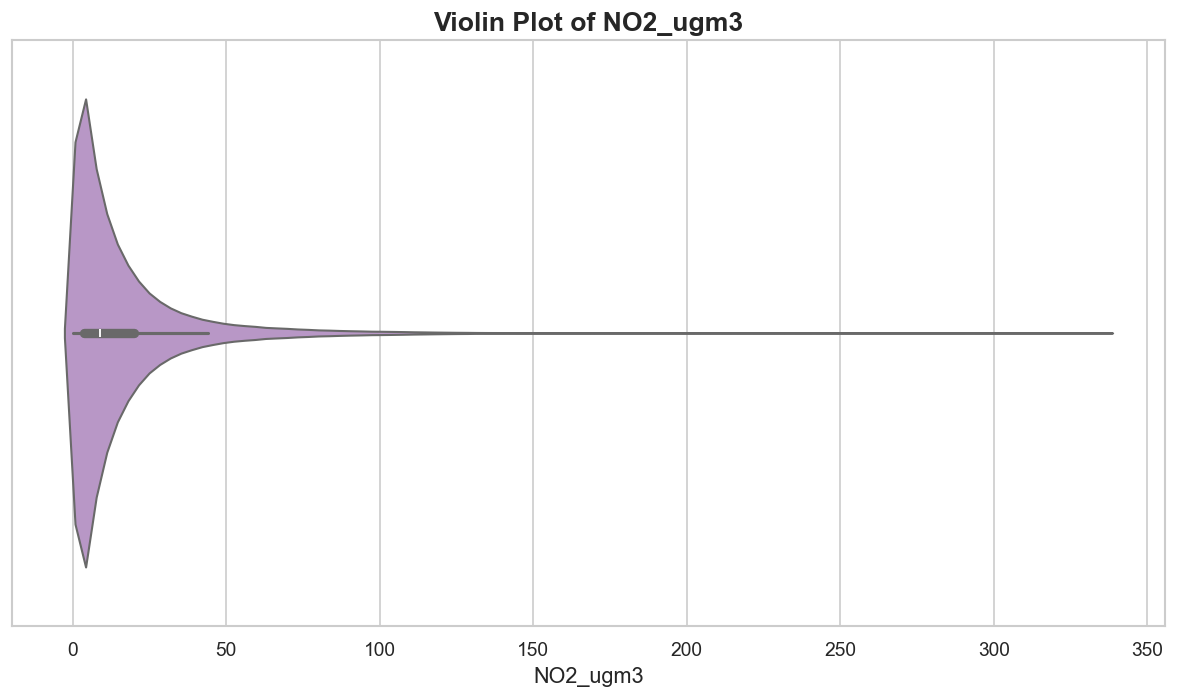

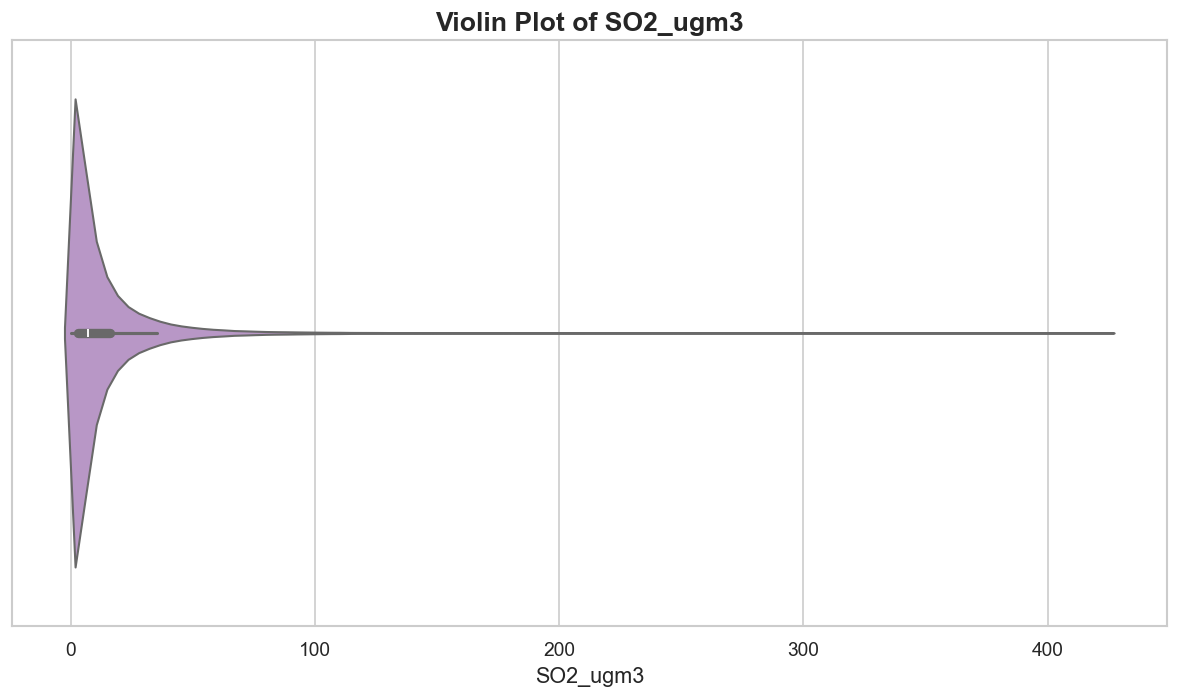

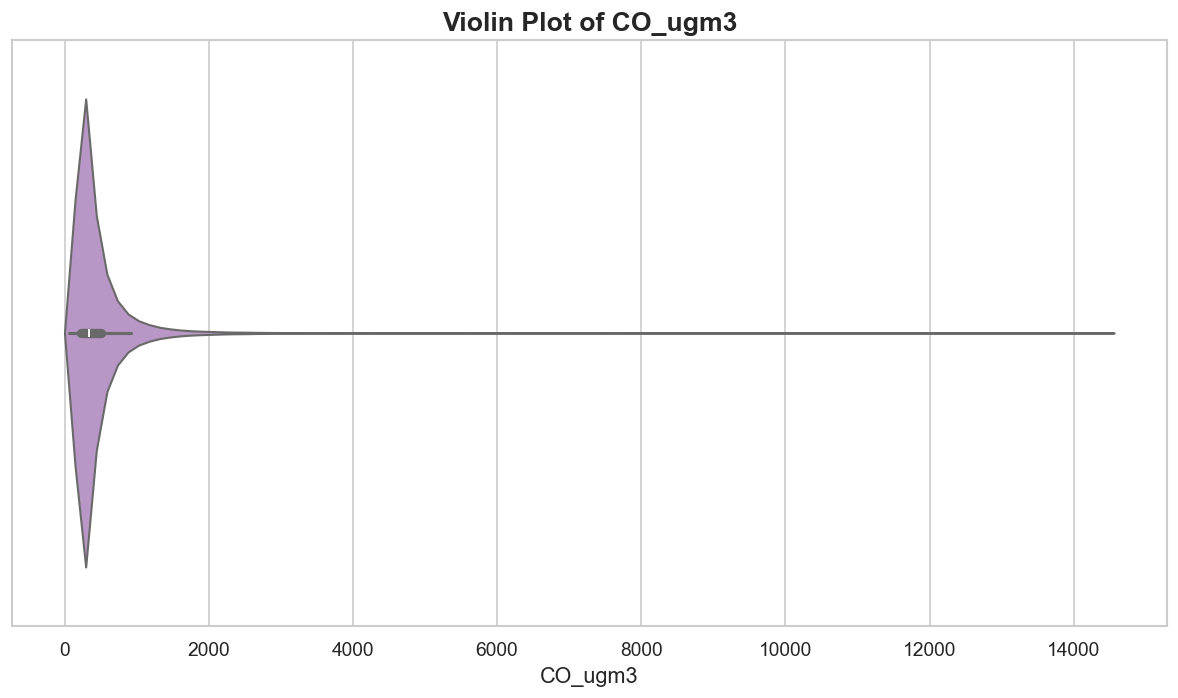

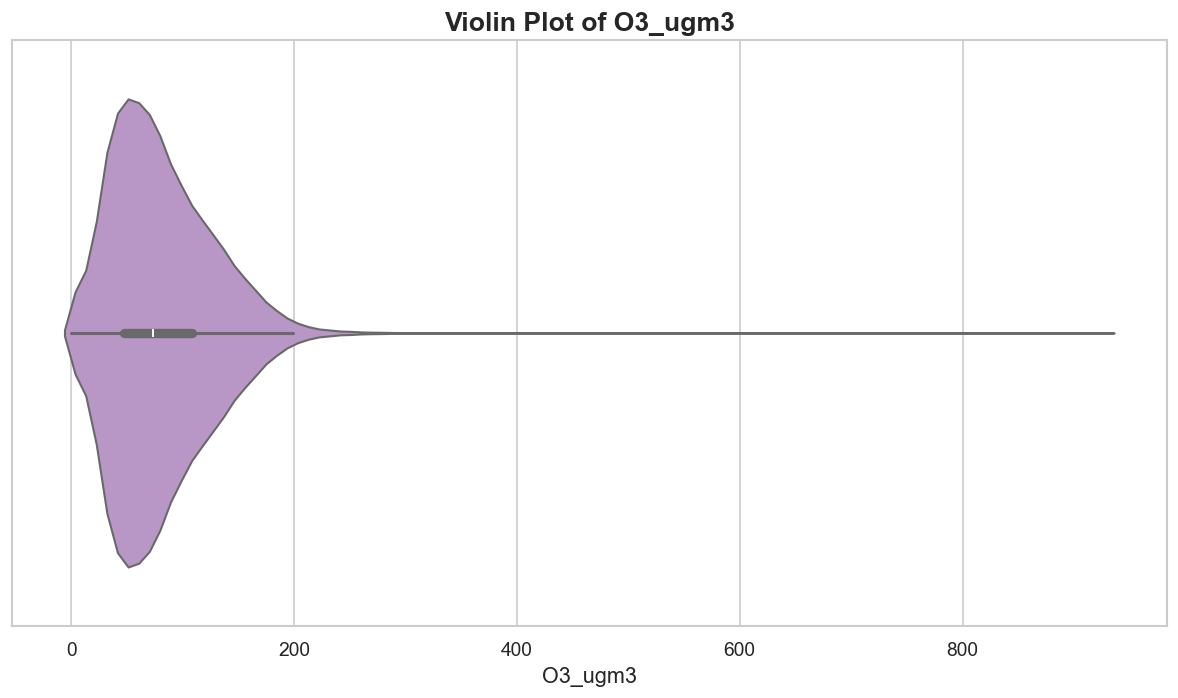

In [20]:
# Violin Plots of Air Pollutants

for col in pollutant_cols:

    plt.figure(figsize=FIG_SIZE)

    sns.violinplot(

        x=df[col],

        color=PALETTE[4]

    )

    plt.title(f"Violin Plot of {col}")

    plt.xlabel(col)

    plt.tight_layout()

    plt.show()

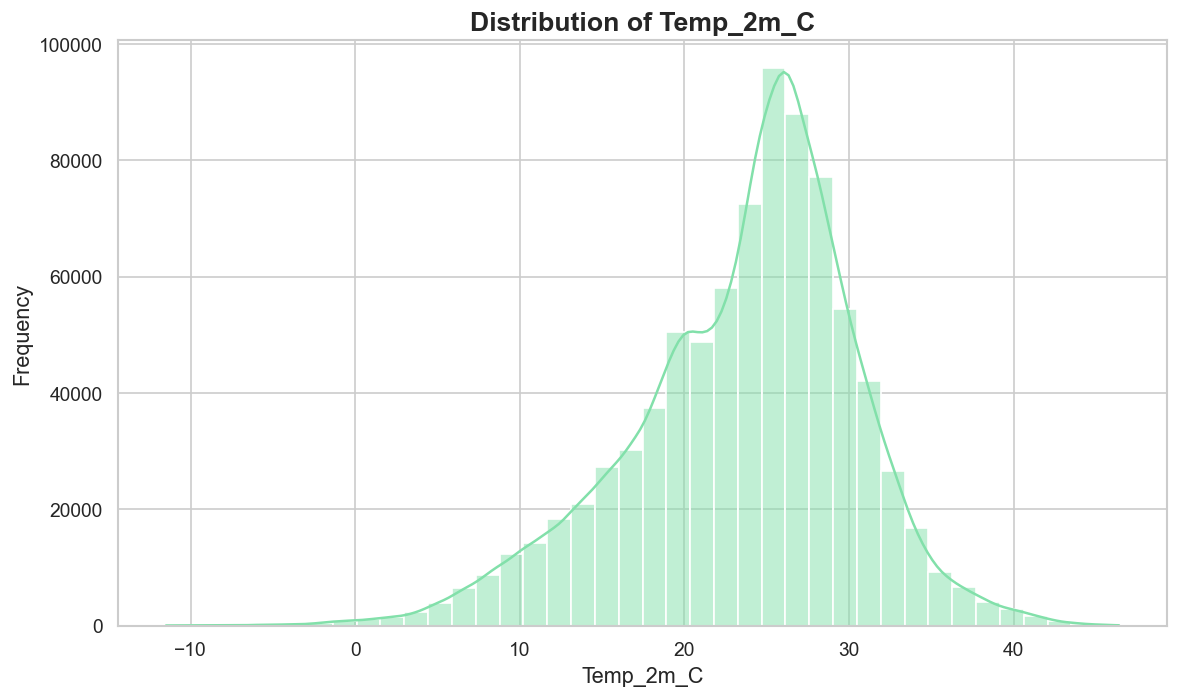

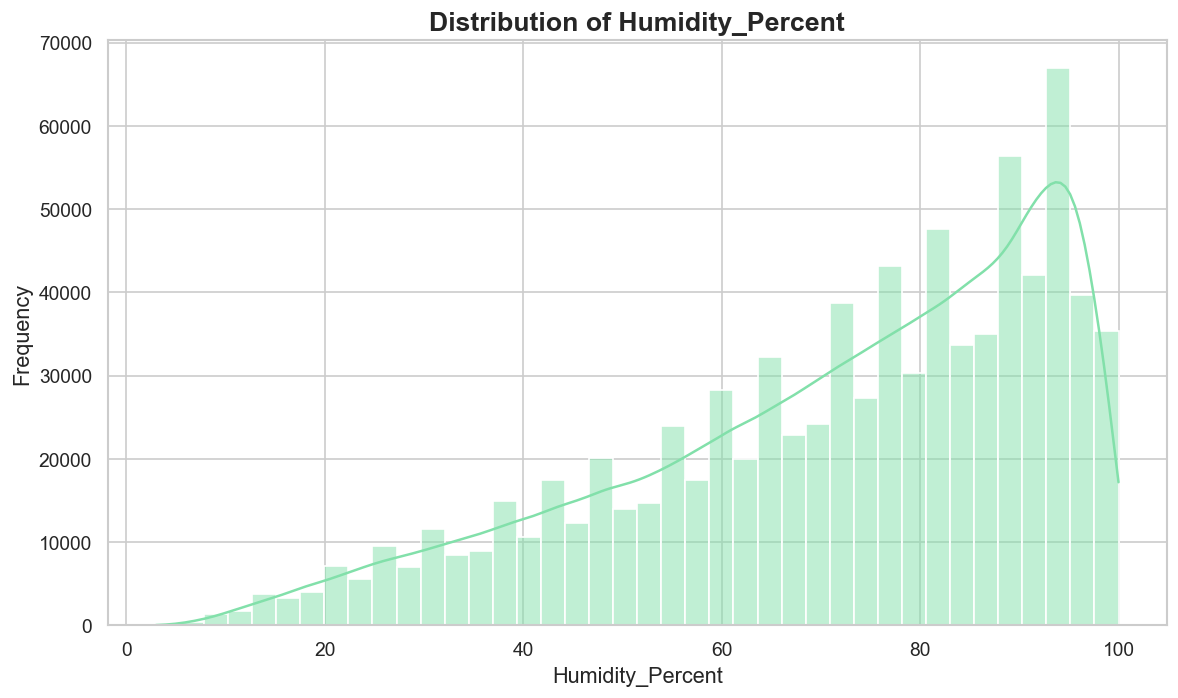

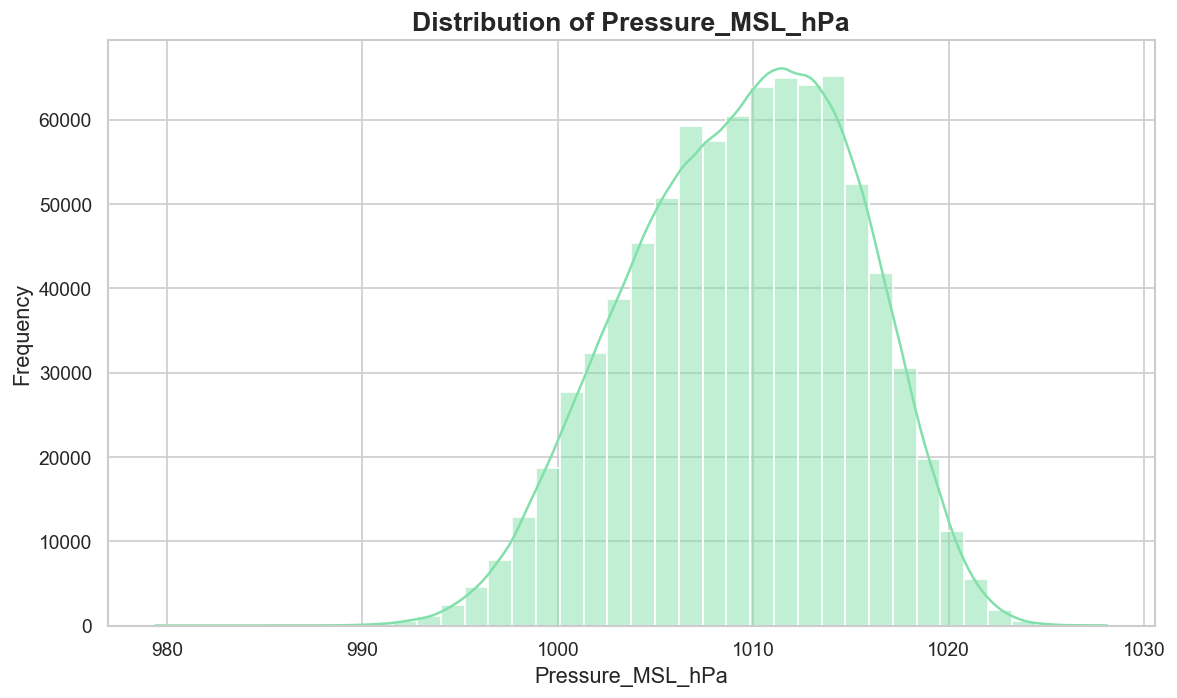

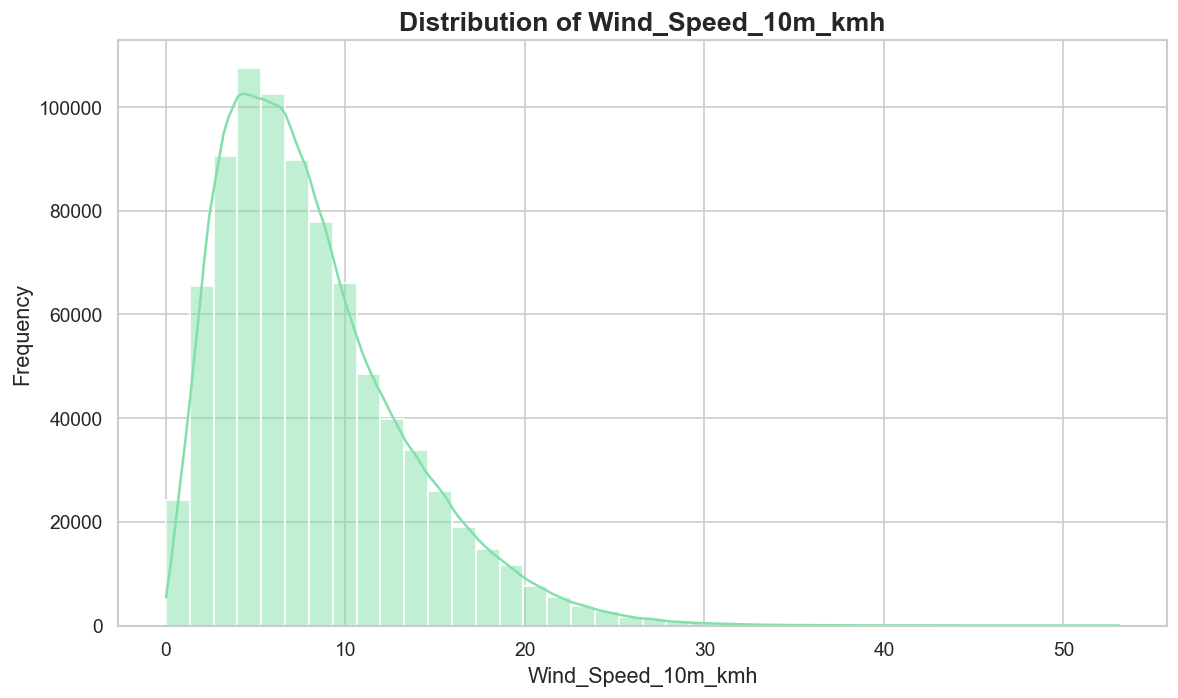

In [21]:
# Weather Variable distributions

for col in weather_cols:

    plt.figure(figsize=FIG_SIZE)

    sns.histplot(

        data=df,

        x=col,

        kde=True,

        bins=40,

        color=PALETTE[1]

    )

    plt.title(f"Distribution of {col}")

    plt.xlabel(col)

    plt.ylabel("Frequency")

    plt.tight_layout()

    plt.show()

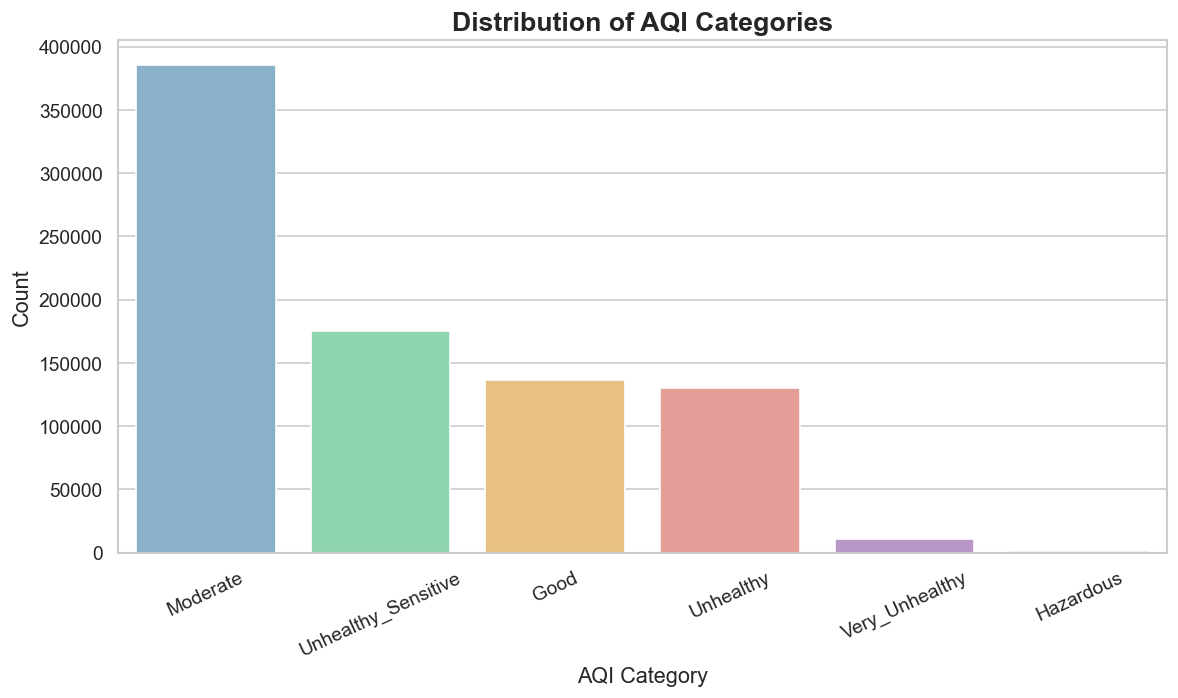

In [27]:
# AQI category distribution

plt.figure(figsize=(10,6))

sns.countplot(

    data=df,

    x="AQI_Category",

    palette=PALETTE,

    order=df["AQI_Category"].value_counts().index

)

plt.title("Distribution of AQI Categories")

plt.xlabel("AQI Category")

plt.ylabel("Count")

plt.xticks(rotation=25)

plt.tight_layout()

plt.show()

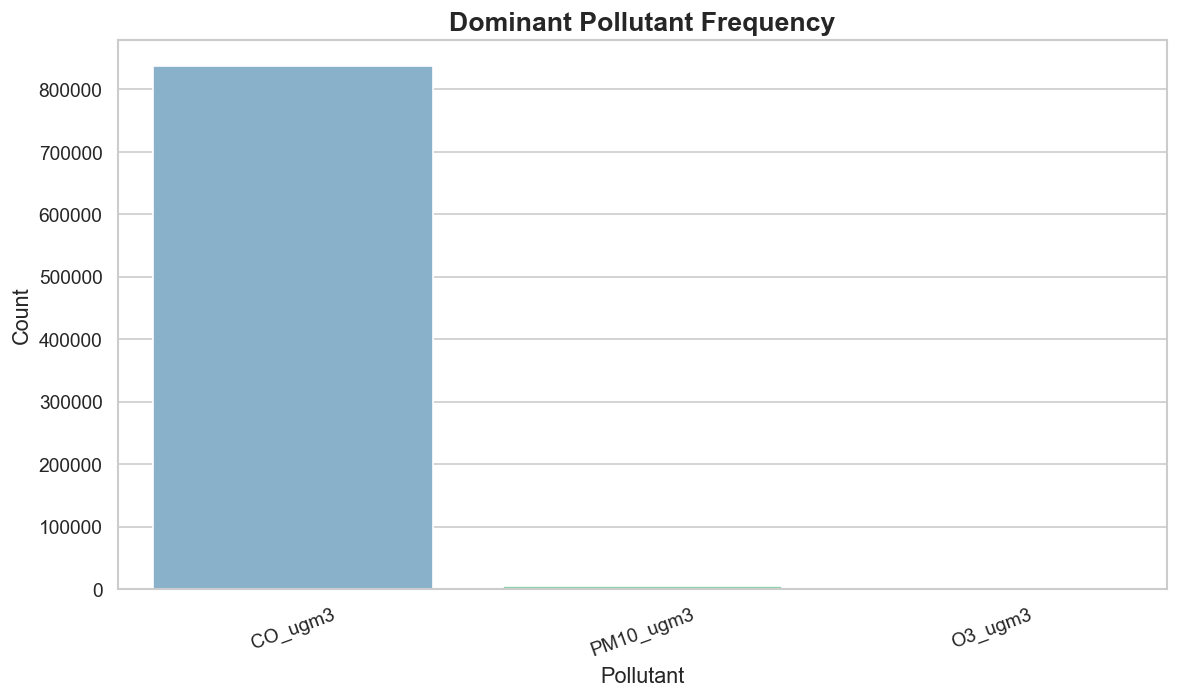

In [23]:
# Dominant Pollutant Distribution
plt.figure(figsize=(10,6))

sns.countplot(

    data=df,

    x="Dominant_Pollutant",

    palette=PALETTE,

    order=df["Dominant_Pollutant"].value_counts().index

)

plt.title("Dominant Pollutant Frequency")

plt.xlabel("Pollutant")

plt.ylabel("Count")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

In [24]:
# Summary statistics

pollutant_summary = (

    df[pollutant_cols]

    .describe()

    .T

)

pollutant_summary

,count,mean,std,min,25%,50%,75%,max
PM2_5_ugm3,842160.00,34.74,30.84,0.10,14.70,25.90,44.20,581.10
PM10_ugm3,842160.00,56.26,83.84,0.10,21.50,39.00,66.40,3263.40
NO2_ugm3,842160.00,16.13,20.81,0.00,3.70,9.00,19.90,336.00
SO2_ugm3,842160.00,13.60,20.62,0.00,2.80,6.90,15.80,424.60
CO_ugm3,842160.00,450.89,434.55,56.00,235.00,333.00,508.00,14504.00
O3_ugm3,842160.00,80.48,46.20,0.00,47.00,73.00,108.00,930.00


## 3. City-wise Air Quality Analysis

Compare air quality across Indian cities to identify pollution hotspots, cleaner cities, and pollutant-specific trends.

In [11]:
# Calculate city-level pollution statistics

city_summary = (

    df

    .groupby("City")[pollutant_cols]

    .mean()

    .round(2)

    .sort_values("PM2_5_ugm3", ascending=False)

)

city_summary.head()

,PM2_5_ugm3,PM10_ugm3,NO2_ugm3,SO2_ugm3,CO_ugm3,O3_ugm3
City,,,,,,
Gurugram,78.71,221.90,48.78,35.54,1047.38,80.04
Delhi,70.80,142.77,42.41,37.79,1004.90,85.58
Patna,59.90,83.74,18.63,16.20,576.50,94.71
Kolkata,57.04,77.13,24.78,22.20,662.89,83.55
Lucknow,56.29,89.81,19.12,15.01,538.17,90.96


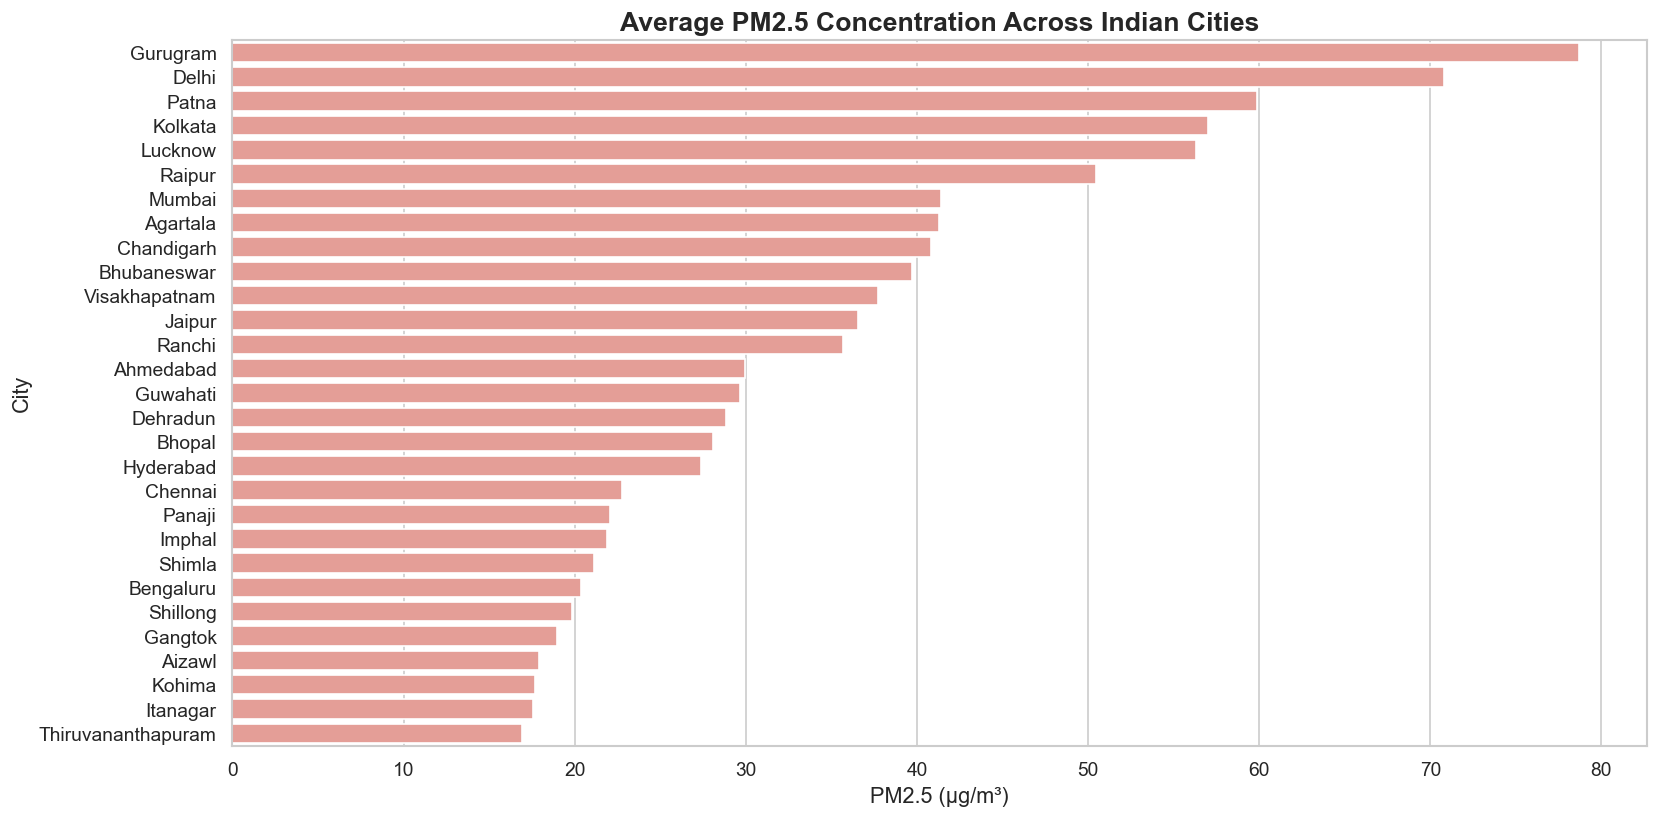

In [12]:
# Average PM2.5 Concentration by City
plt.figure(figsize=LARGE_FIG)

sns.barplot(

    data=city_summary.reset_index(),

    x="PM2_5_ugm3",

    y="City",

    color=PALETTE[3]

)

plt.title("Average PM2.5 Concentration Across Indian Cities")

plt.xlabel("PM2.5 (μg/m³)")

plt.ylabel("City")

plt.tight_layout()

plt.show()

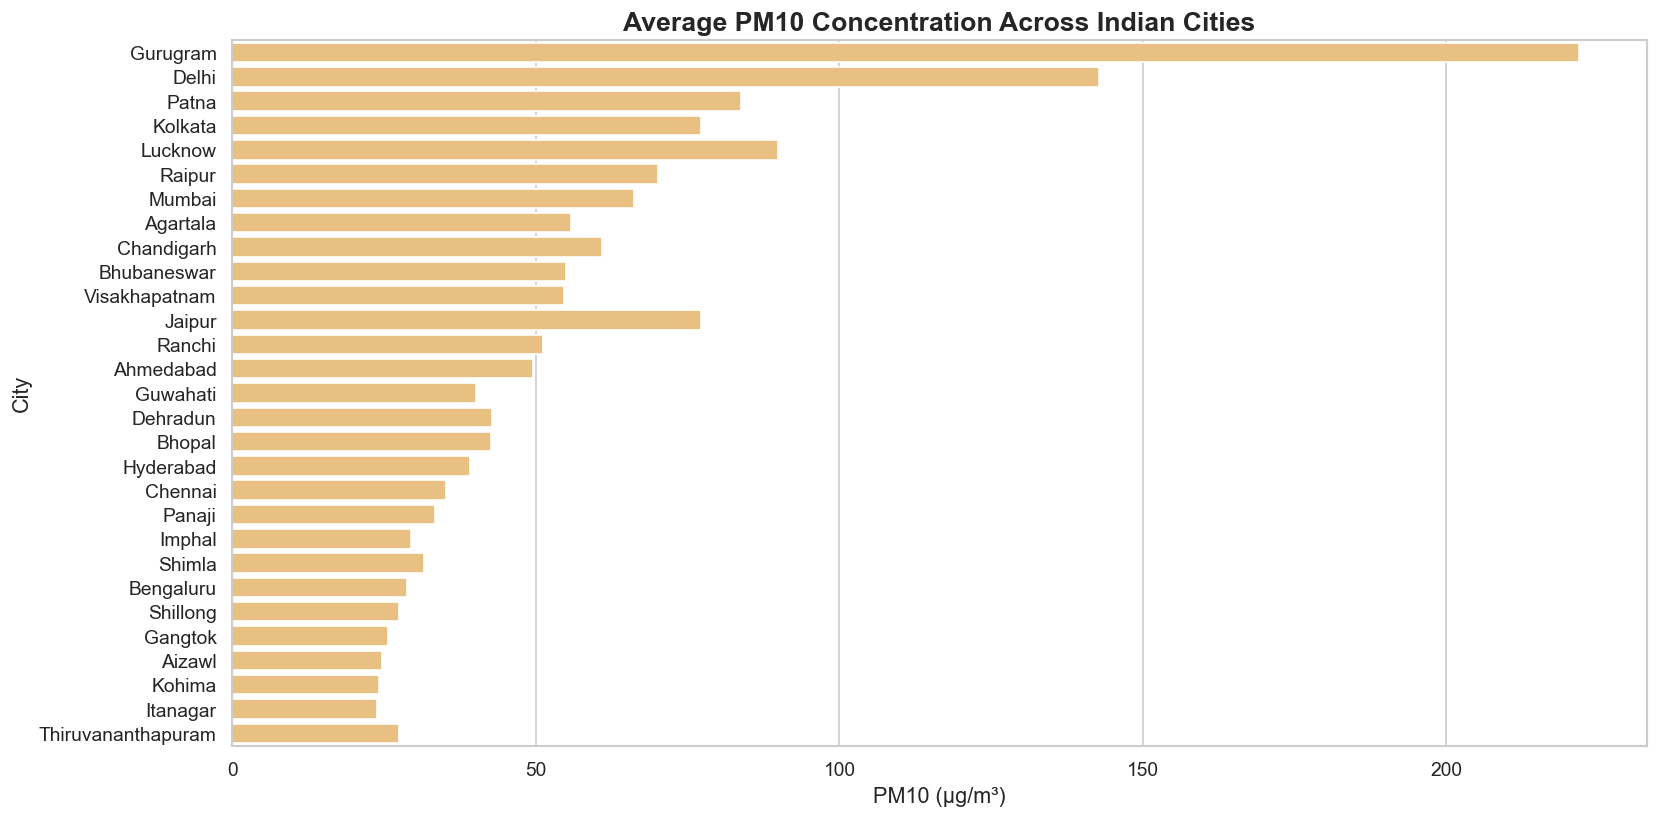

In [13]:
# Average PM10 Concentration by City
plt.figure(figsize=LARGE_FIG)

sns.barplot(

    data=city_summary.reset_index(),

    x="PM10_ugm3",

    y="City",

    color=PALETTE[2]

)

plt.title("Average PM10 Concentration Across Indian Cities")

plt.xlabel("PM10 (μg/m³)")

plt.ylabel("City")

plt.tight_layout()

plt.show()

### Top 10 Most Polluted Cities (PM2.5)

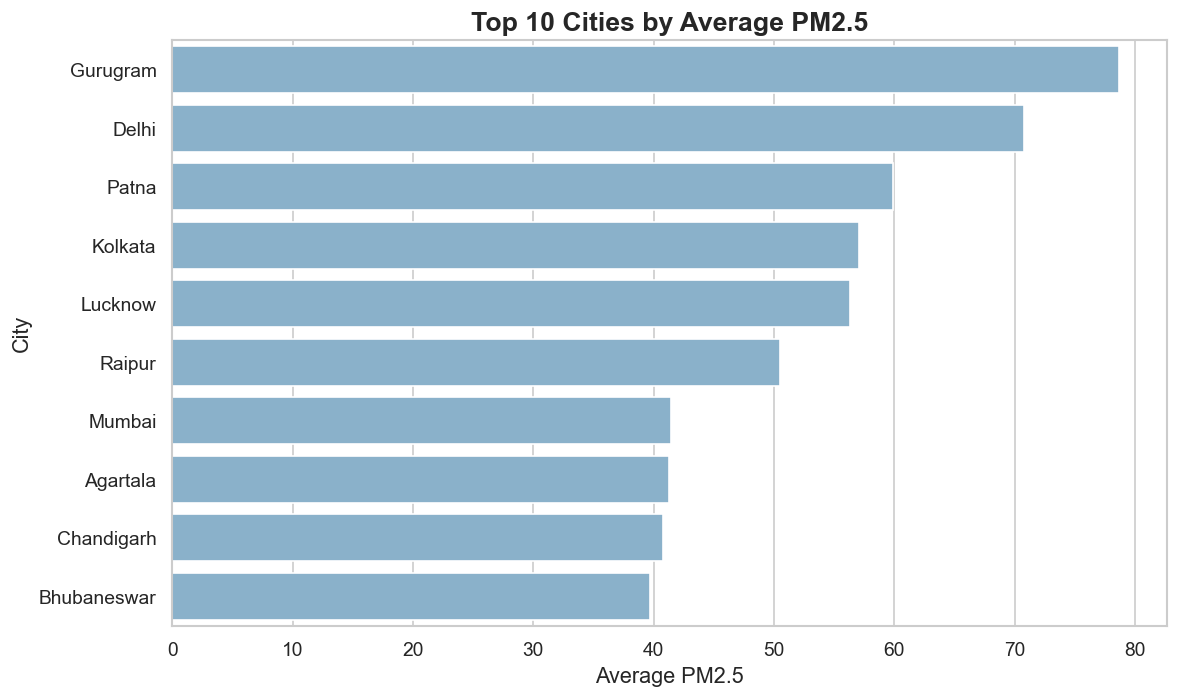

In [14]:
top10_pm25 = city_summary.head(10)

plt.figure(figsize=(10,6))

sns.barplot(

    data=top10_pm25.reset_index(),

    x="PM2_5_ugm3",

    y="City",

    color=PALETTE[0]

)

plt.title("Top 10 Cities by Average PM2.5")

plt.xlabel("Average PM2.5")

plt.ylabel("City")

plt.tight_layout()

plt.show()

### Top 10 Cleanest Cities (PM2.5)

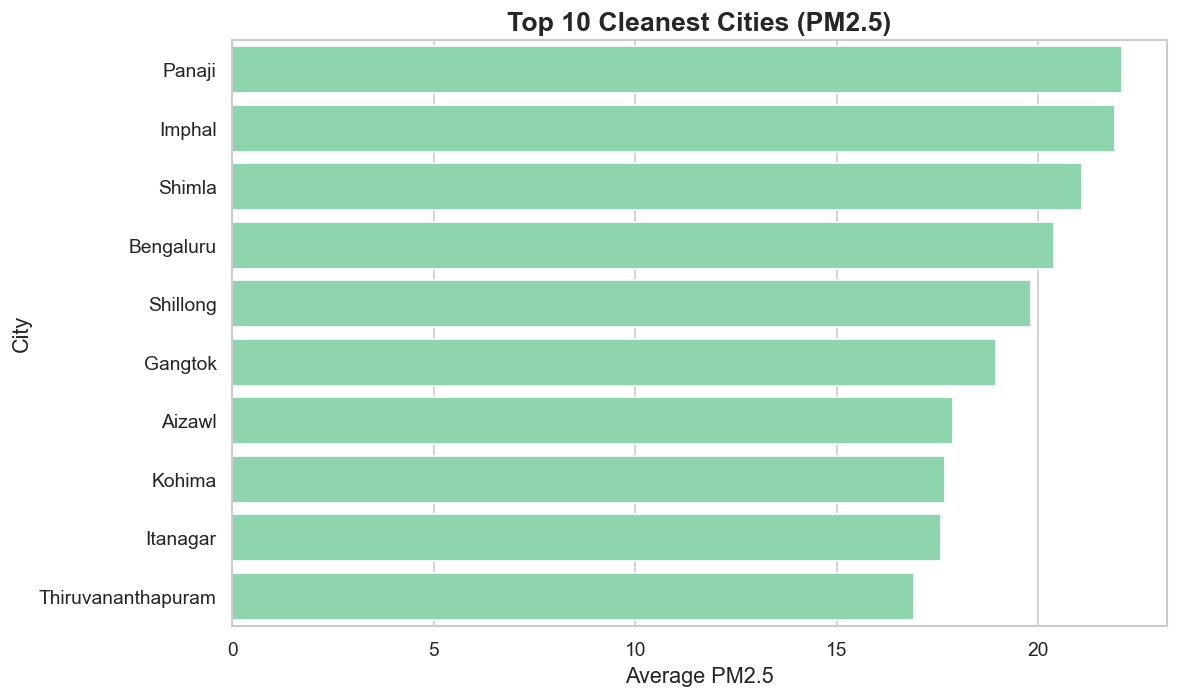

In [15]:
clean10_pm25 = city_summary.tail(10)

plt.figure(figsize=(10,6))

sns.barplot(

    data=clean10_pm25.reset_index(),

    x="PM2_5_ugm3",

    y="City",

    color=PALETTE[1]

)

plt.title("Top 10 Cleanest Cities (PM2.5)")

plt.xlabel("Average PM2.5")

plt.ylabel("City")

plt.tight_layout()

plt.show()

### Pollutant Composition Across Cities

Compare the average concentration of all pollutants across cities.

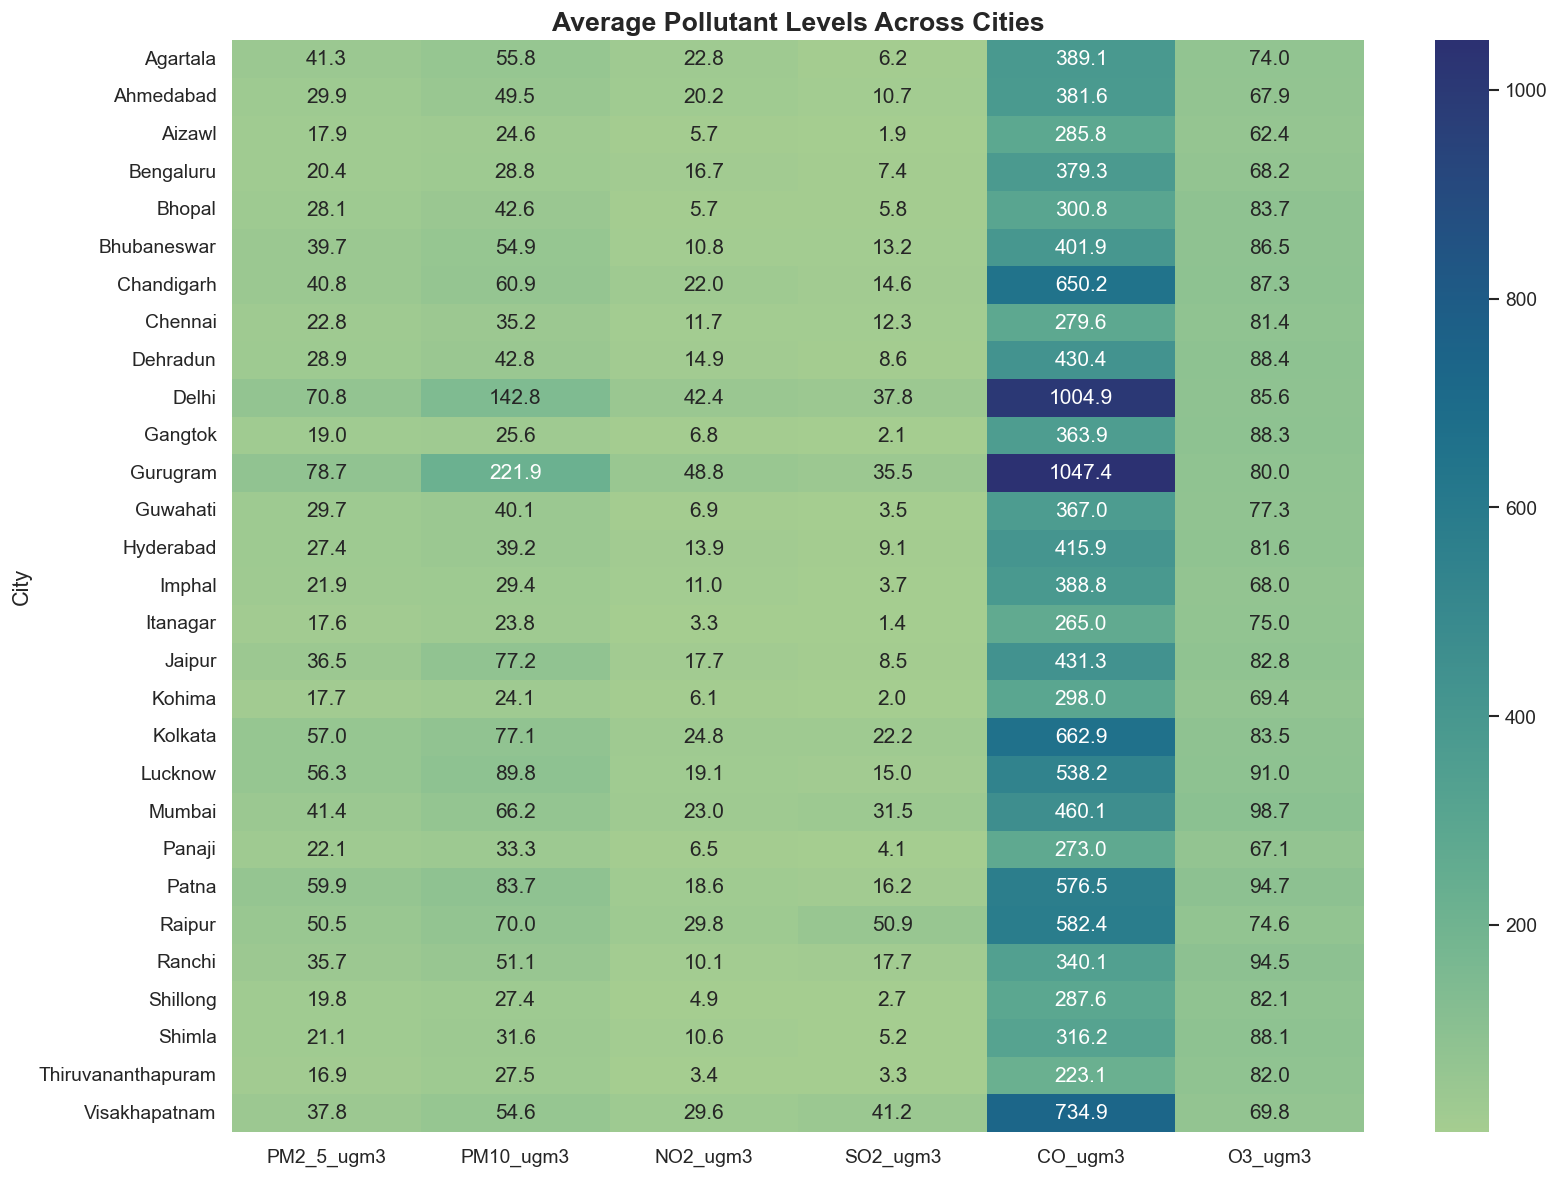

In [16]:
city_pollution = (

    df

    .groupby("City")[pollutant_cols]

    .mean()

    .round(2)

)

plt.figure(figsize=(14,10))

sns.heatmap(

    city_pollution,

    cmap="crest",

    annot=True,

    fmt=".1f"

)

plt.title("Average Pollutant Levels Across Cities")

plt.tight_layout()

plt.show()

### Average AQI by City

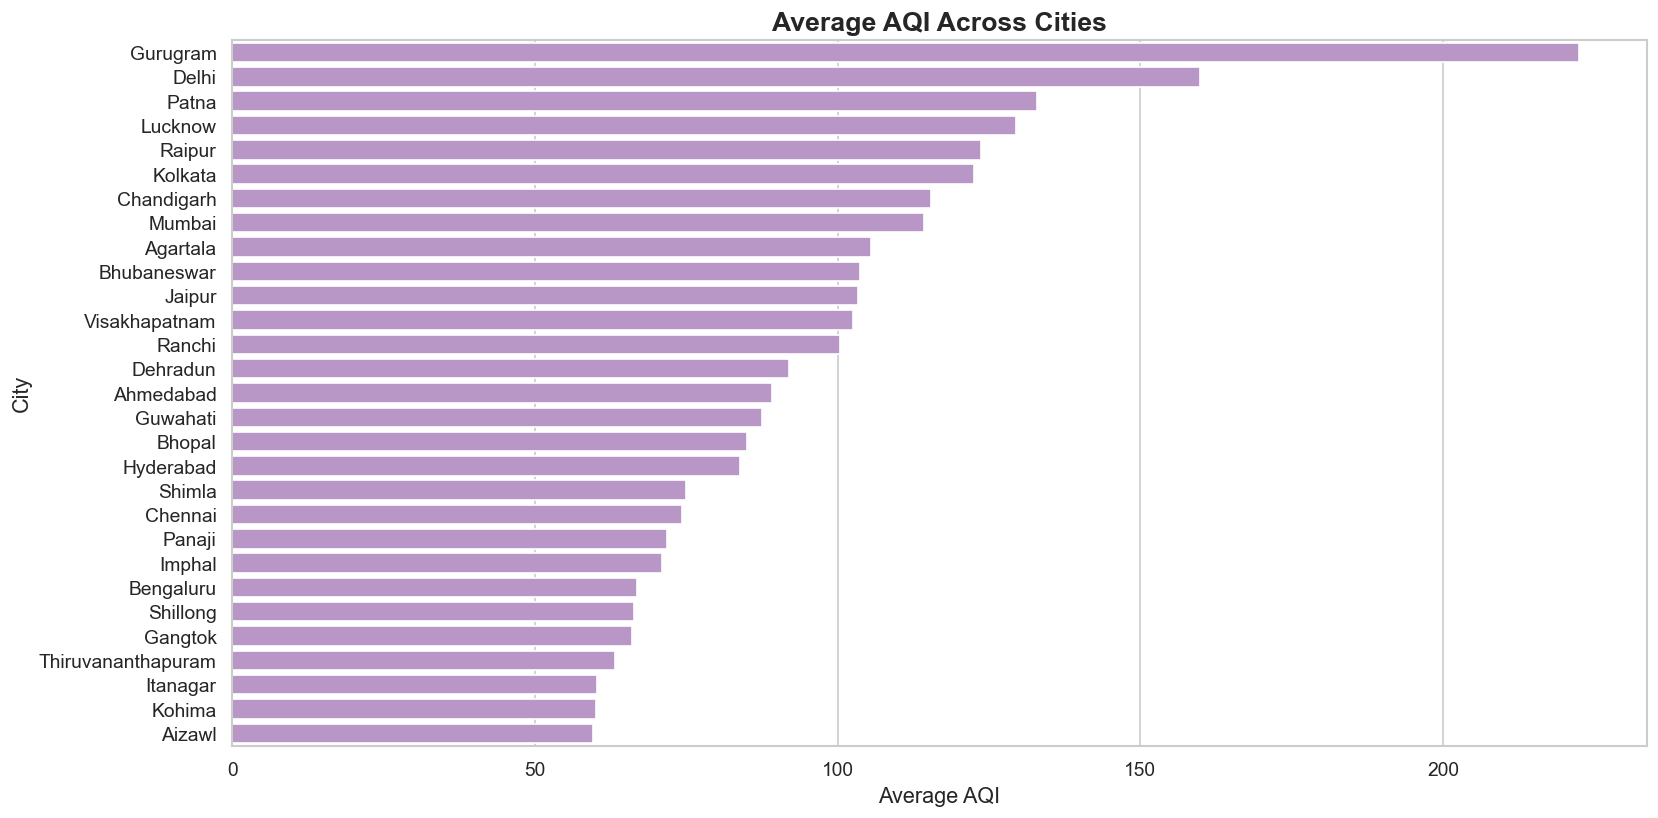

In [17]:
aqi_city = (

    df

    .groupby("City")["US_AQI"]

    .mean()

    .sort_values(ascending=False)

)

plt.figure(figsize=LARGE_FIG)

sns.barplot(

    x=aqi_city.values,

    y=aqi_city.index,

    color=PALETTE[4]

)

plt.title("Average AQI Across Cities")

plt.xlabel("Average AQI")

plt.ylabel("City")

plt.tight_layout()

plt.show()

### City-wise Observation Count


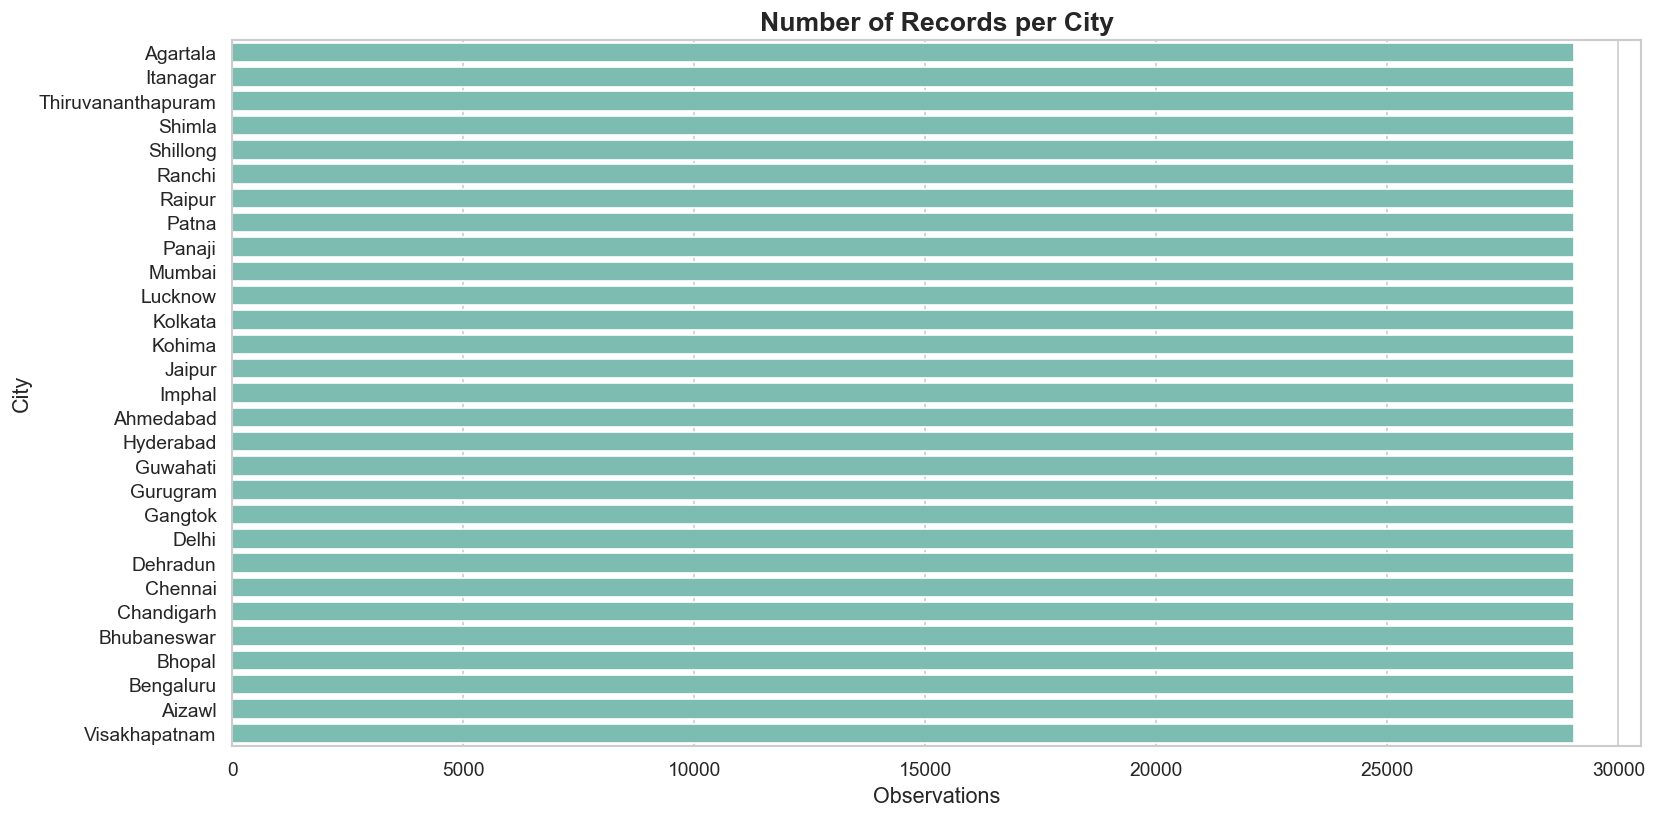

In [18]:
city_count = (

    df["City"]

    .value_counts()

)

plt.figure(figsize=LARGE_FIG)

sns.barplot(

    x=city_count.values,

    y=city_count.index,

    color=PALETTE[5]

)

plt.title("Number of Records per City")

plt.xlabel("Observations")

plt.ylabel("City")

plt.tight_layout()

plt.show()

In [19]:
# City Summary Table
city_overview = (

    df

    .groupby("City")

    .agg(

        Records=("City", "size"),

        Avg_PM25=("PM2_5_ugm3", "mean"),

        Avg_PM10=("PM10_ugm3", "mean"),

        Avg_NO2=("NO2_ugm3", "mean"),

        Avg_SO2=("SO2_ugm3", "mean"),

        Avg_CO=("CO_ugm3", "mean"),

        Avg_O3=("O3_ugm3", "mean"),

        Avg_AQI=("US_AQI", "mean")

    )

    .round(2)

    .sort_values("Avg_AQI", ascending=False)

)

city_overview

,Records,Avg_PM25,Avg_PM10,Avg_NO2,Avg_SO2,Avg_CO,Avg_O3,Avg_AQI
City,,,,,,,,
Gurugram,29040,78.71,221.90,48.78,35.54,1047.38,80.04,222.52
Delhi,29040,70.80,142.77,42.41,37.79,1004.90,85.58,159.84
Patna,29040,59.90,83.74,18.63,16.20,576.50,94.71,132.85
Lucknow,29040,56.29,89.81,19.12,15.01,538.17,90.96,129.41
Raipur,29040,50.47,70.03,29.78,50.94,582.43,74.63,123.69
Kolkata,29040,57.04,77.13,24.78,22.20,662.89,83.55,122.46
Chandigarh,29040,40.80,60.86,22.01,14.56,650.18,87.33,115.34
Mumbai,29040,41.41,66.19,23.01,31.48,460.06,98.66,114.23
Agartala,29040,41.27,55.80,22.76,6.24,389.07,74.03,105.53


## 4. Weather vs Pollution Analysis

Analyze the relationship between meteorological variables and air pollution to understand how weather conditions influence pollutant concentrations across Indian cities.

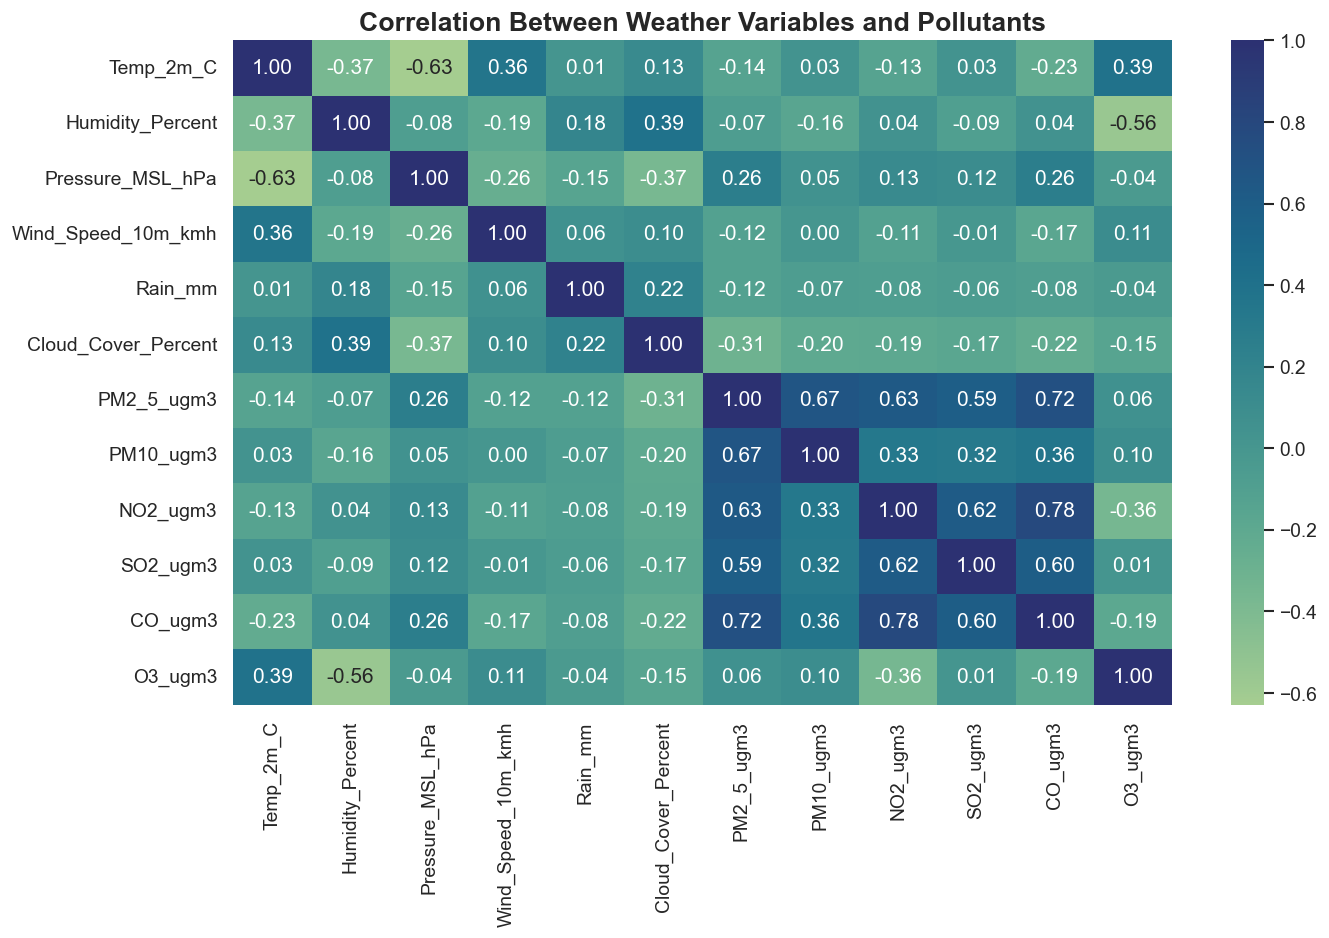

In [24]:
# Correlation between weather variables and pollutants

weather_cols = [

    "Temp_2m_C",
    "Humidity_Percent",
    "Pressure_MSL_hPa",
    "Wind_Speed_10m_kmh",
    "Rain_mm",
    "Cloud_Cover_Percent"

]

corr = df[weather_cols + pollutant_cols].corr()

plt.figure(figsize=HEATMAP_SIZE)

sns.heatmap(

    corr,

    cmap="crest",

    annot=True,

    fmt=".2f"

)

plt.title("Correlation Between Weather Variables and Pollutants")

plt.tight_layout()

plt.show()

In [21]:
df.columns.tolist()

['City',
 'State',
 'Latitude',
 'Longitude',
 'Datetime',
 'Year',
 'Month',
 'Day',
 'Hour',
 'Day_of_Week',
 'Day_Name',
 'Week_of_Year',
 'Is_Weekend',
 'Quarter',
 'Season',
 'Time_of_Day',
 'Temp_2m_C',
 'Humidity_Percent',
 'Dew_Point_C',
 'Humidity_Category',
 'Wind_Speed_10m_kmh',
 'Wind_Dir_10m',
 'Wind_Gusts_kmh',
 'Wind_Category',
 'Wind_Stagnation',
 'Precipitation_mm',
 'Rain_mm',
 'Is_Raining',
 'Heavy_Rain',
 'Pressure_MSL_hPa',
 'Surface_Pressure_hPa',
 'Solar_Radiation_Wm2',
 'Direct_Radiation_Wm2',
 'Diffuse_Radiation_Wm2',
 'Cloud_Cover_Percent',
 'Cloud_Low_Percent',
 'Cloud_Mid_Percent',
 'Cloud_High_Percent',
 'Is_Daytime',
 'Sunshine_Seconds',
 'PM2_5_ugm3',
 'PM10_ugm3',
 'PM_Ratio',
 'CO_ugm3',
 'NO2_ugm3',
 'SO2_ugm3',
 'O3_ugm3',
 'Dust_ugm3',
 'AOD',
 'US_AQI',
 'US_AQI_PM25',
 'US_AQI_PM10',
 'US_AQI_NO2',
 'US_AQI_O3',
 'US_AQI_CO',
 'EU_AQI',
 'EU_AQI_PM25',
 'EU_AQI_PM10',
 'AQI_Category',
 'PM25_Category_India',
 'Temp_Inversion',
 'Festival_Period',
 

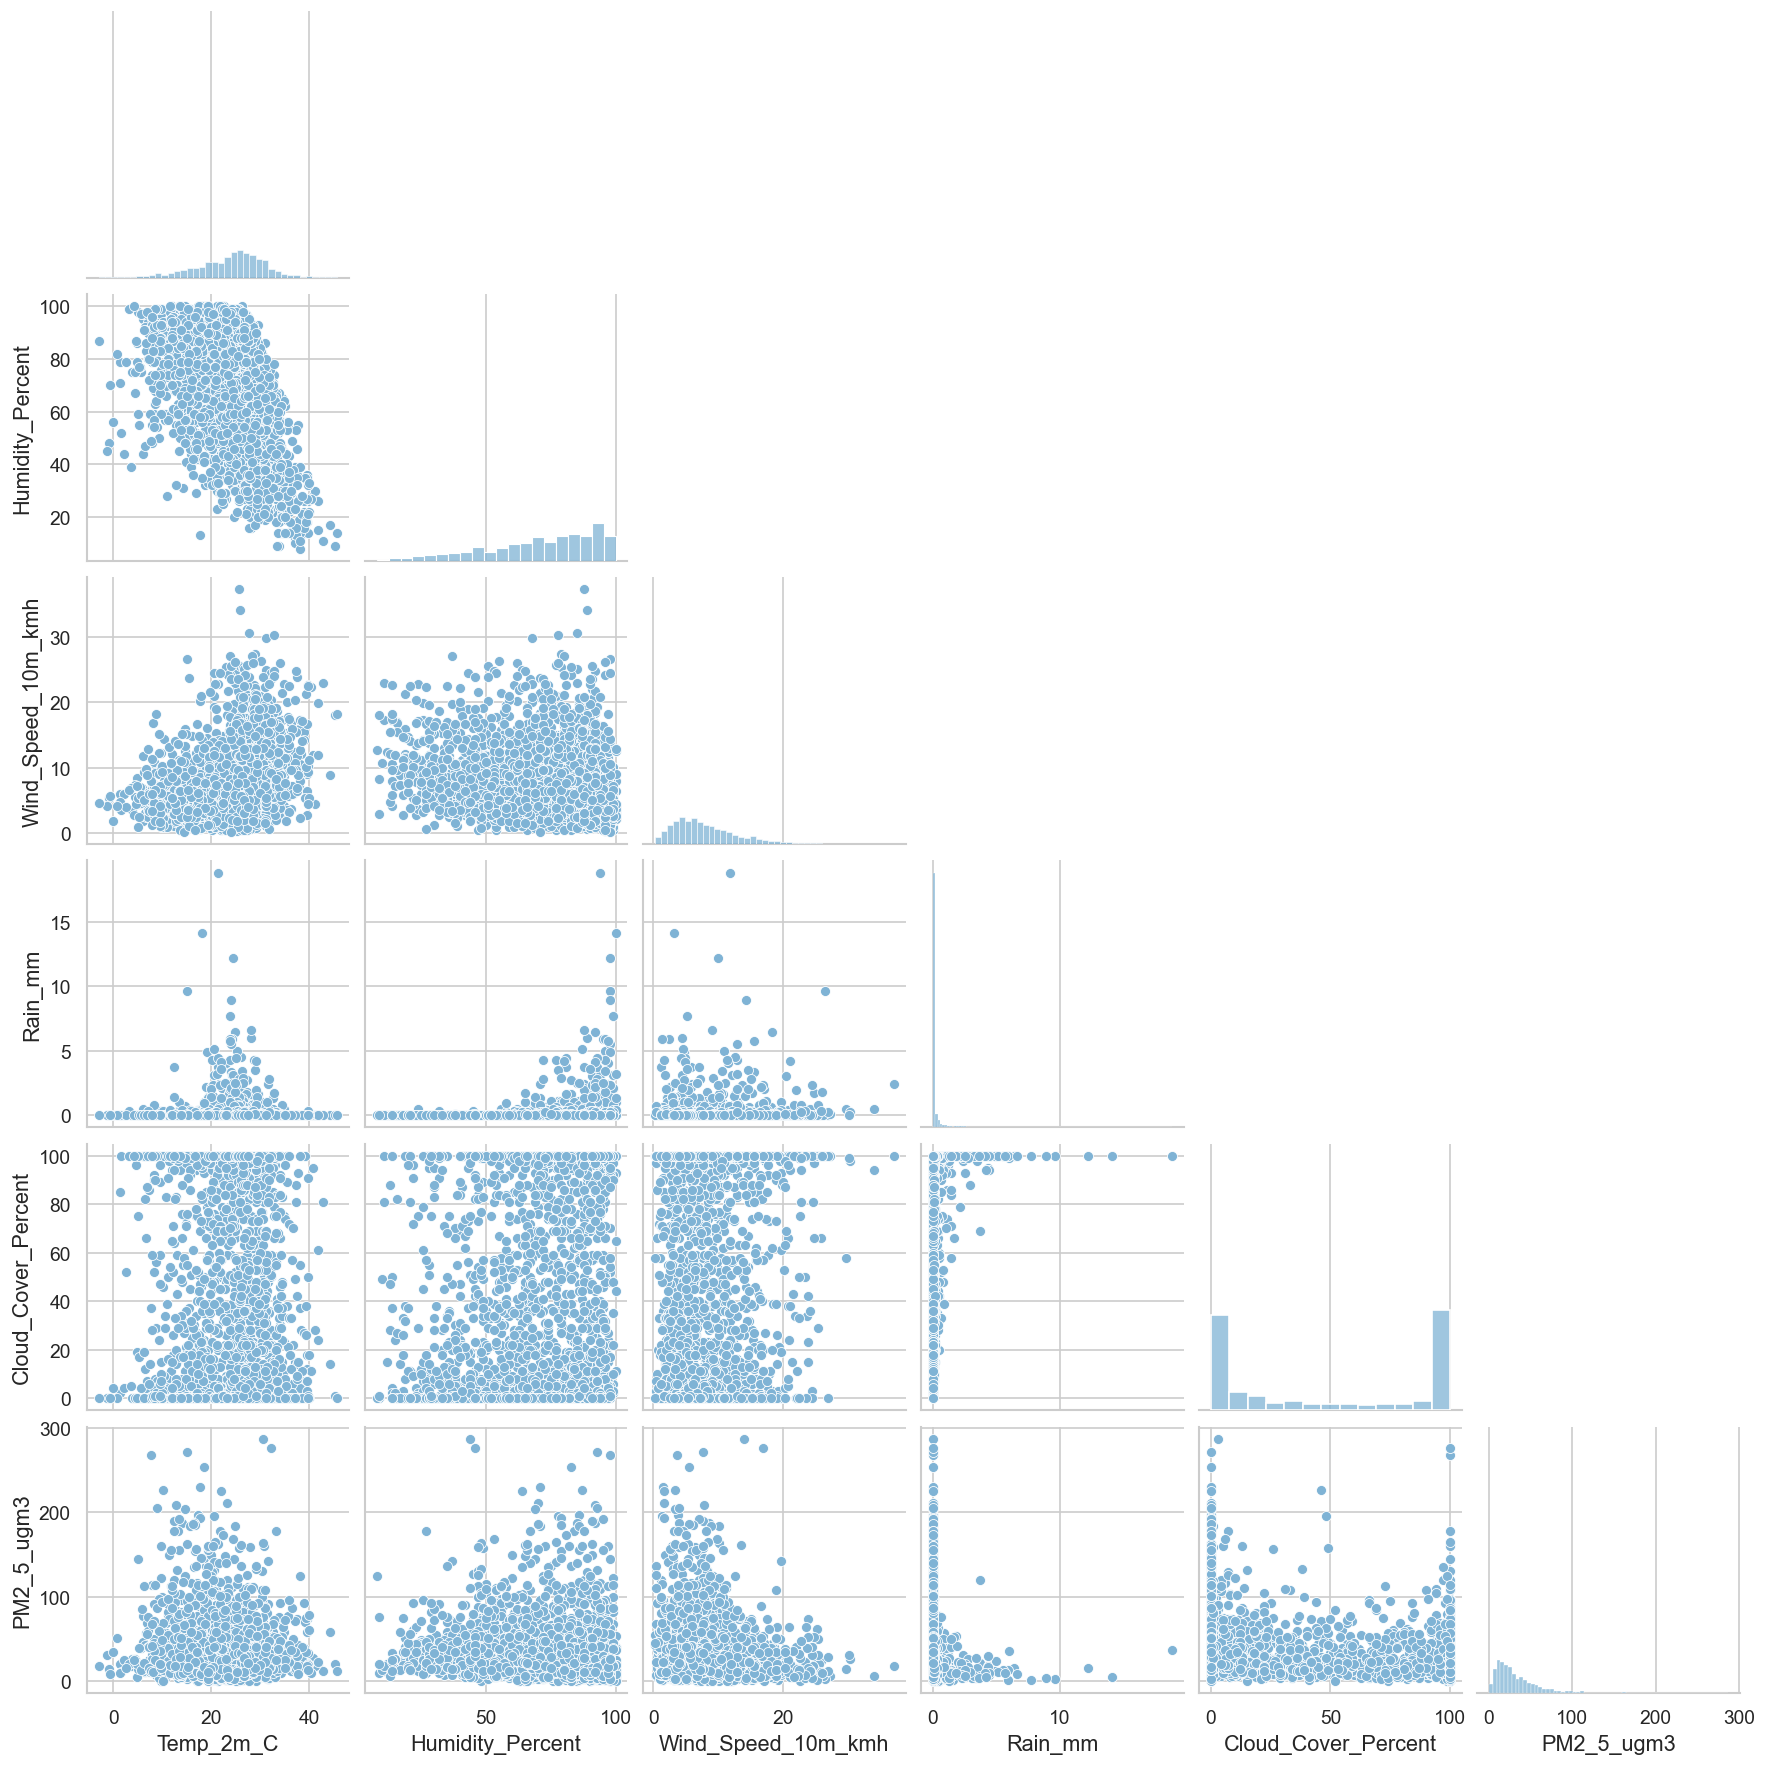

In [25]:
# Pairwise relationship between weather variables and PM2.5

pair_cols = [

    "Temp_2m_C",
    "Humidity_Percent",
    "Wind_Speed_10m_kmh",
    "Rain_mm",
    "Cloud_Cover_Percent",
    "PM2_5_ugm3"

]

sns.pairplot(

    df[pair_cols].sample(2500, random_state=42),

    corner=True

)

plt.show()

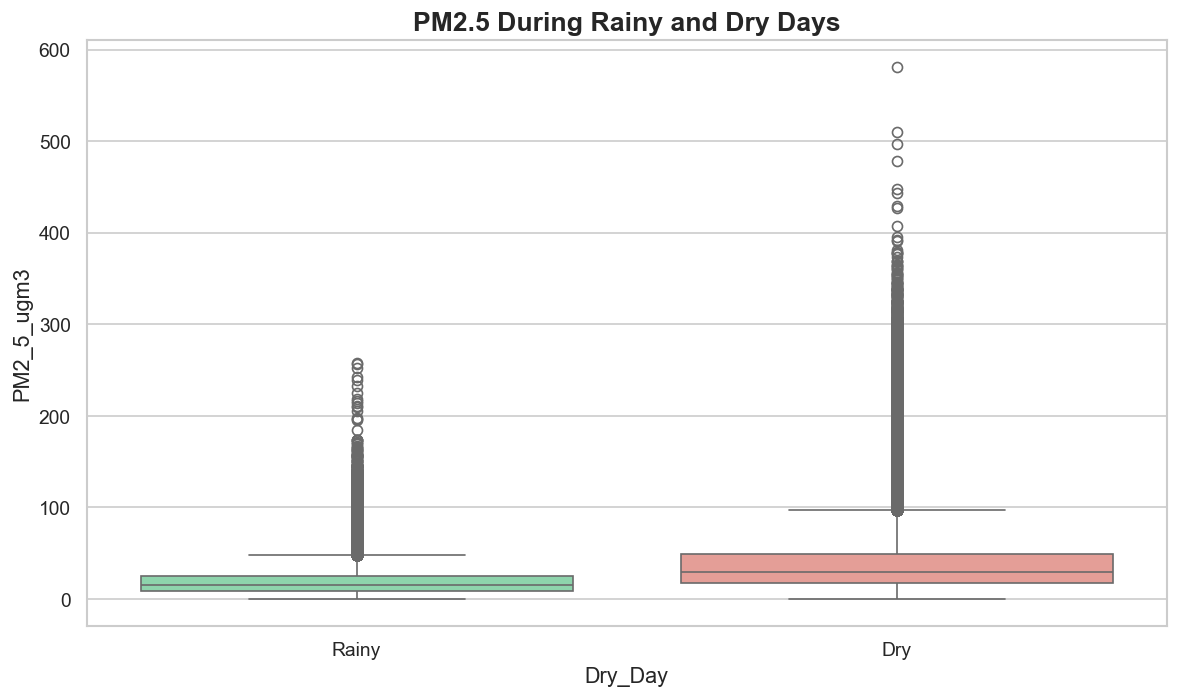

In [26]:
# PM2.5 during rainy and dry conditions

plt.figure(figsize=FIG_SIZE)

sns.boxplot(

    data=df,

    x="Dry_Day",

    y="PM2_5_ugm3",

    palette=[PALETTE[1], PALETTE[3]]

)

plt.xticks(

    [0,1],

    ["Rainy","Dry"]

)

plt.title("PM2.5 During Rainy and Dry Days")

plt.tight_layout()

plt.show()

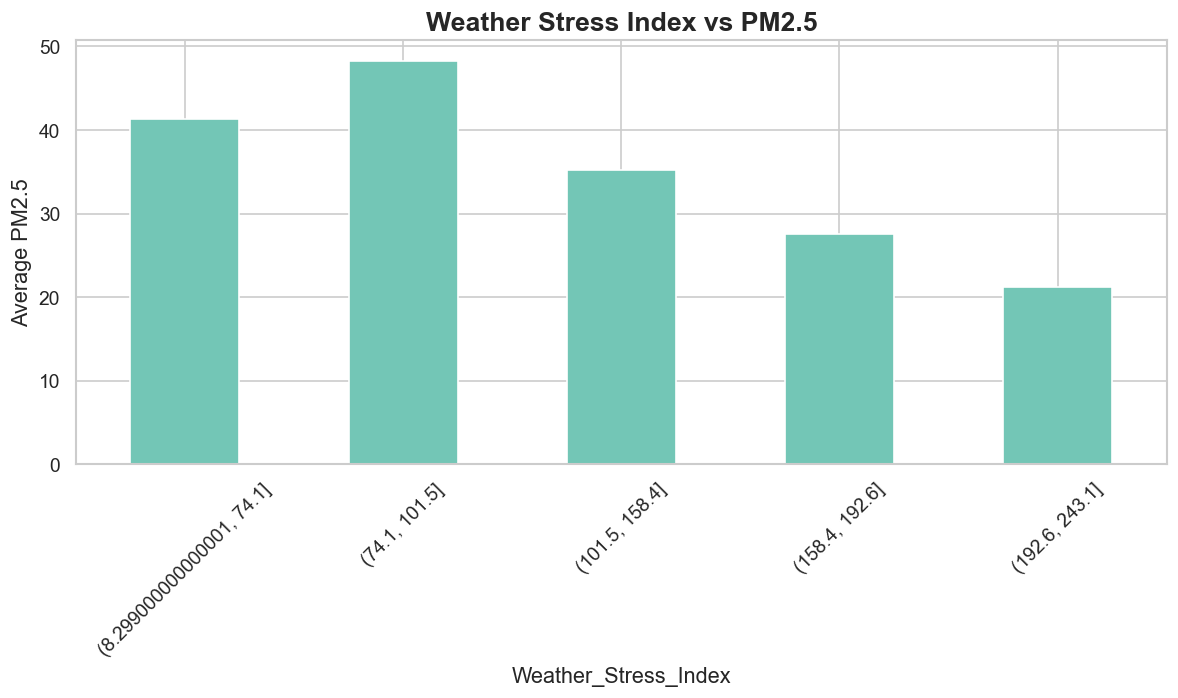

In [35]:
# Weather stress and PM2.5

weather_summary = (

    df

    .groupby(

        pd.qcut(

            df["Weather_Stress_Index"],

            5

        )

    )

    ["PM2_5_ugm3"]

    .mean()

)

plt.figure(figsize=FIG_SIZE)

weather_summary.plot(

    kind="bar",

    color=PALETTE[5]

)

plt.ylabel("Average PM2.5")

plt.title("Weather Stress Index vs PM2.5")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Time-Series Analysis

Analyze temporal pollution patterns across different time scales to understand hourly, daily, monthly and seasonal variations.

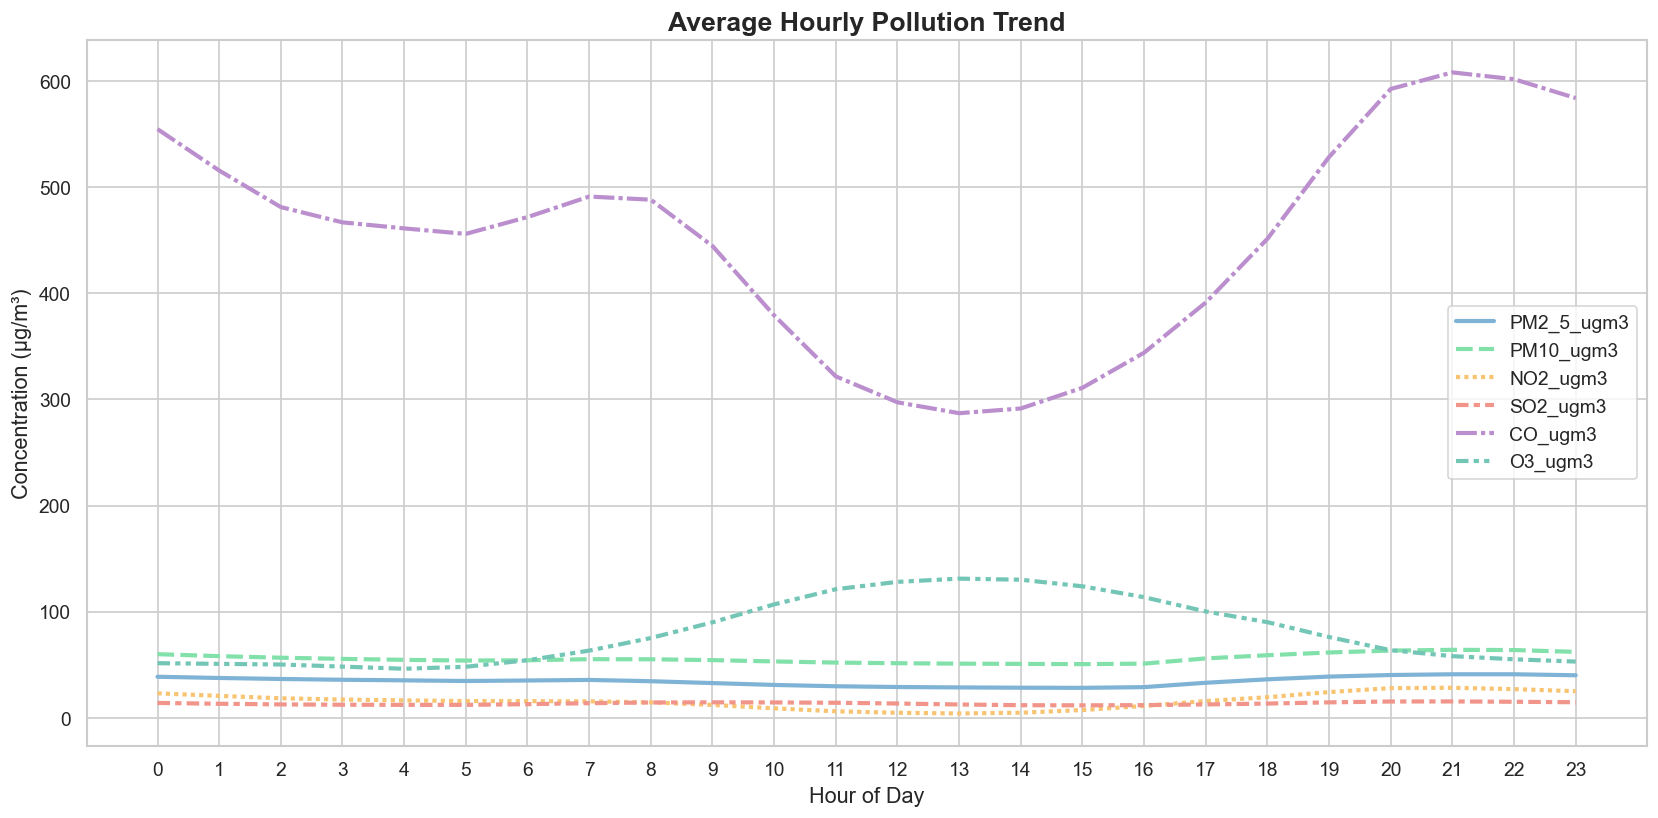

In [29]:
# Average hourly pollution trend

hourly_pollution = (

    df

    .groupby("Hour")[pollutant_cols]

    .mean()

)

plt.figure(figsize=LARGE_FIG)

sns.lineplot(

    data=hourly_pollution,

    palette=PALETTE,

    linewidth=2.5

)

plt.title("Average Hourly Pollution Trend")

plt.xlabel("Hour of Day")

plt.ylabel("Concentration (μg/m³)")

plt.xticks(range(24))

plt.tight_layout()

plt.show()

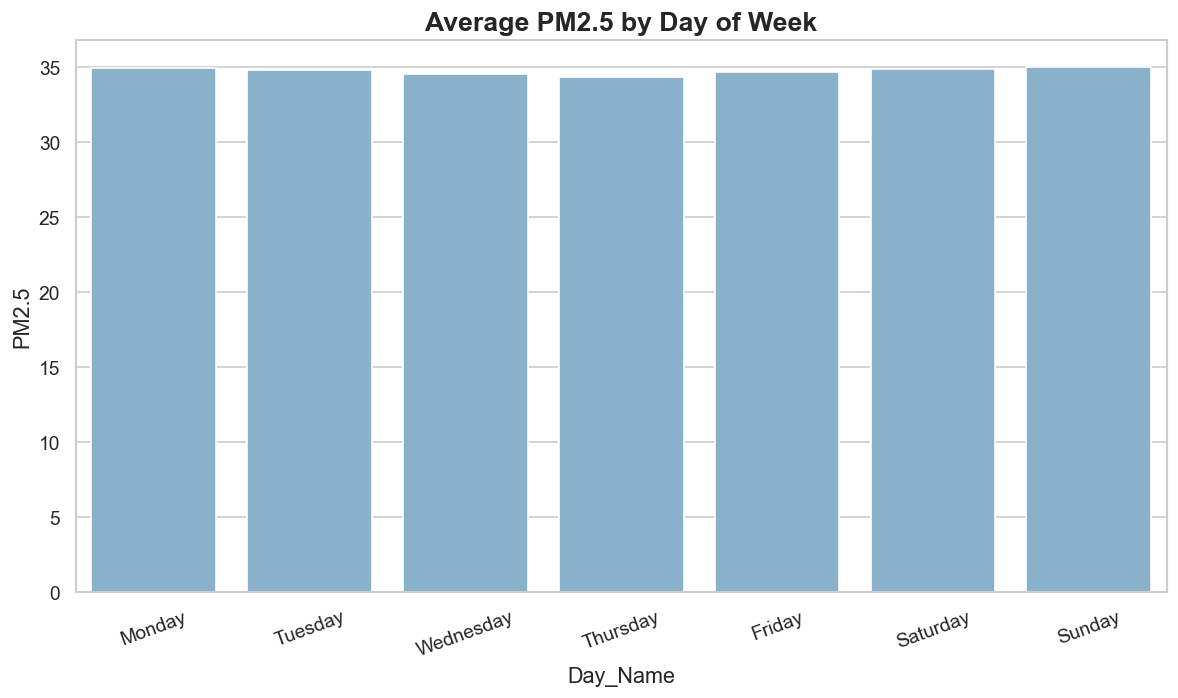

In [30]:
# Average pollution by day of week

weekday_order = [

    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"

]

weekday_pollution = (

    df

    .groupby("Day_Name")["PM2_5_ugm3"]

    .mean()

    .reindex(weekday_order)

)

plt.figure(figsize=FIG_SIZE)

sns.barplot(

    x=weekday_pollution.index,

    y=weekday_pollution.values,

    color=PALETTE[0]

)

plt.title("Average PM2.5 by Day of Week")

plt.xticks(rotation=20)

plt.ylabel("PM2.5")

plt.tight_layout()

plt.show()

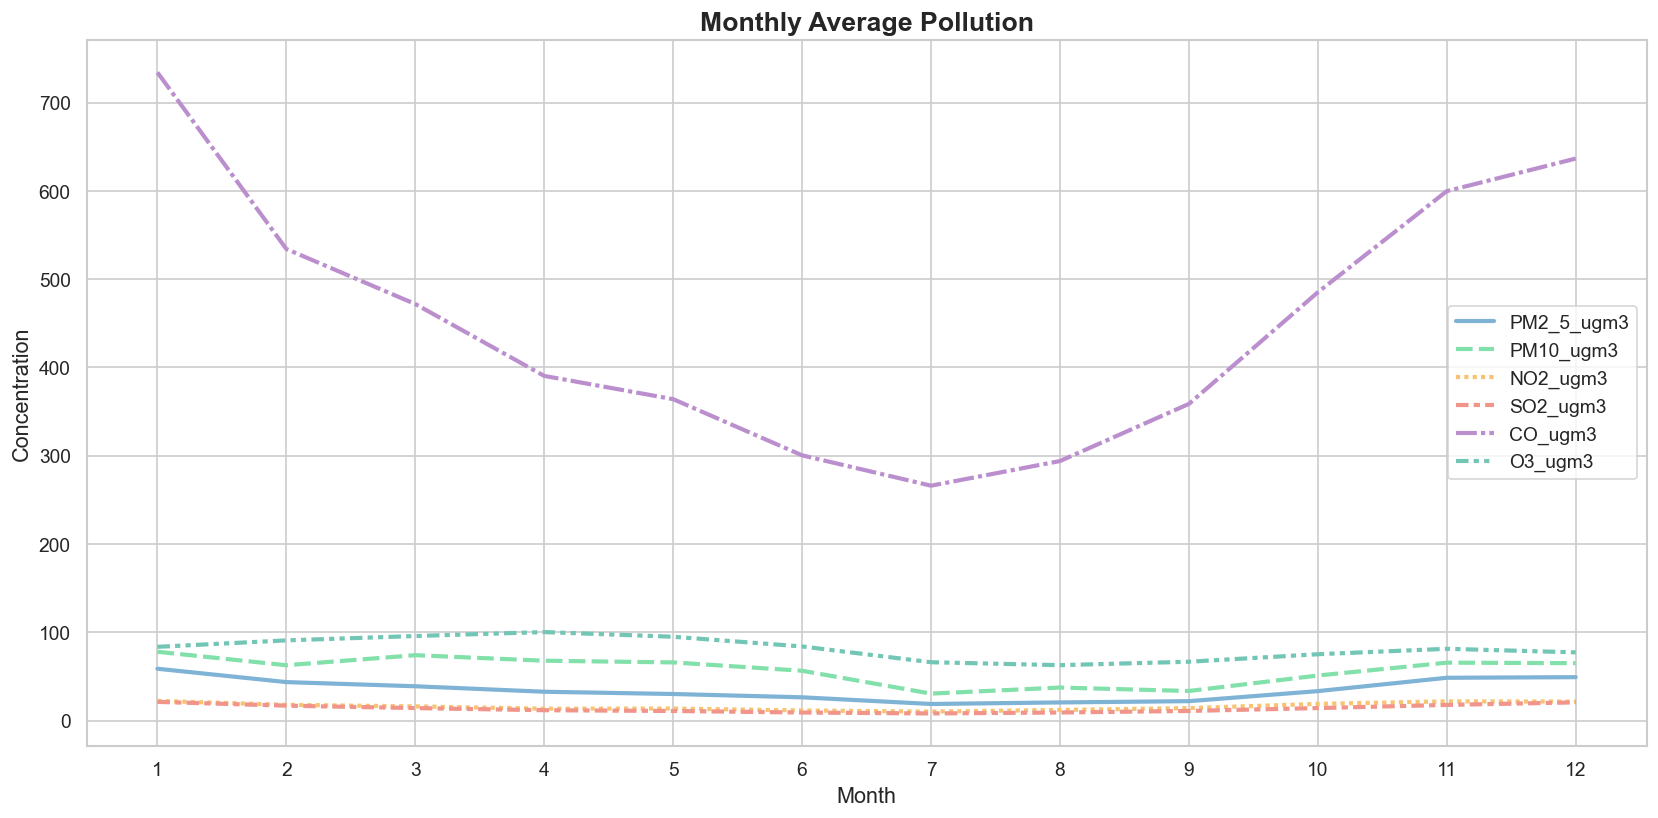

In [31]:
# Monthly pollution trend

monthly_pollution = (

    df

    .groupby("Month")[pollutant_cols]

    .mean()

)

plt.figure(figsize=LARGE_FIG)

sns.lineplot(

    data=monthly_pollution,

    palette=PALETTE,

    linewidth=2.5

)

plt.title("Monthly Average Pollution")

plt.xlabel("Month")

plt.ylabel("Concentration")

plt.xticks(range(1,13))

plt.tight_layout()

plt.show()

<Figure size 1680x840 with 0 Axes>

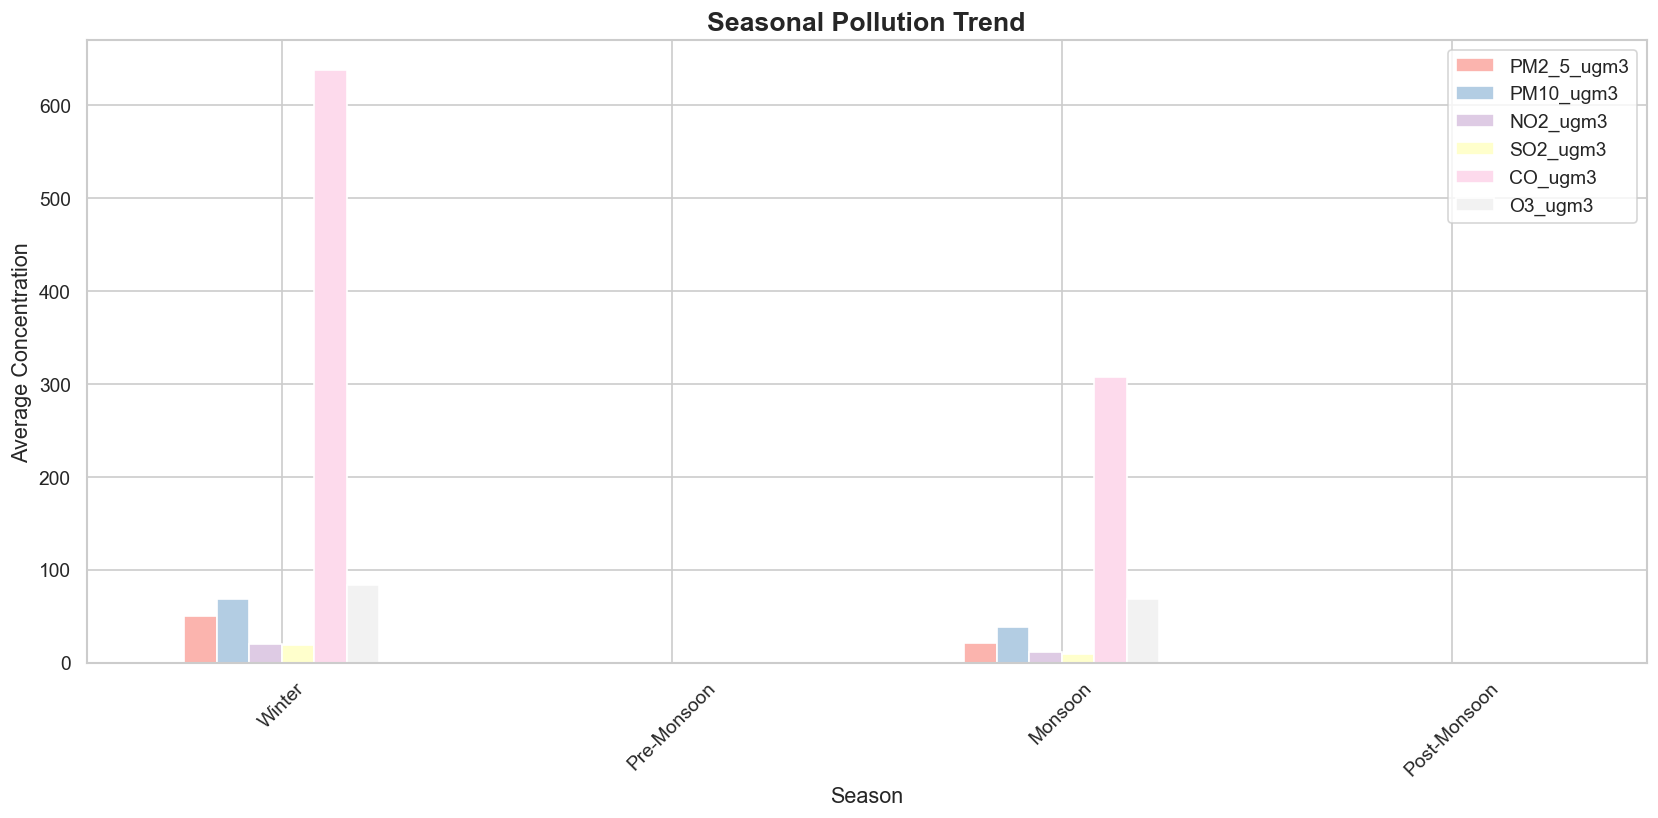

In [34]:
# Seasonal pollution trend

season_order = [

    "Winter",
    "Pre-Monsoon",
    "Monsoon",
    "Post-Monsoon"

]

seasonal = (

    df

    .groupby("Season")[pollutant_cols]

    .mean()

    .reindex(season_order)

)

plt.figure(figsize=LARGE_FIG)

seasonal.plot(

    kind="bar",

    figsize=LARGE_FIG,

    colormap="Pastel1"

)

plt.title("Seasonal Pollution Trend")

plt.ylabel("Average Concentration")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

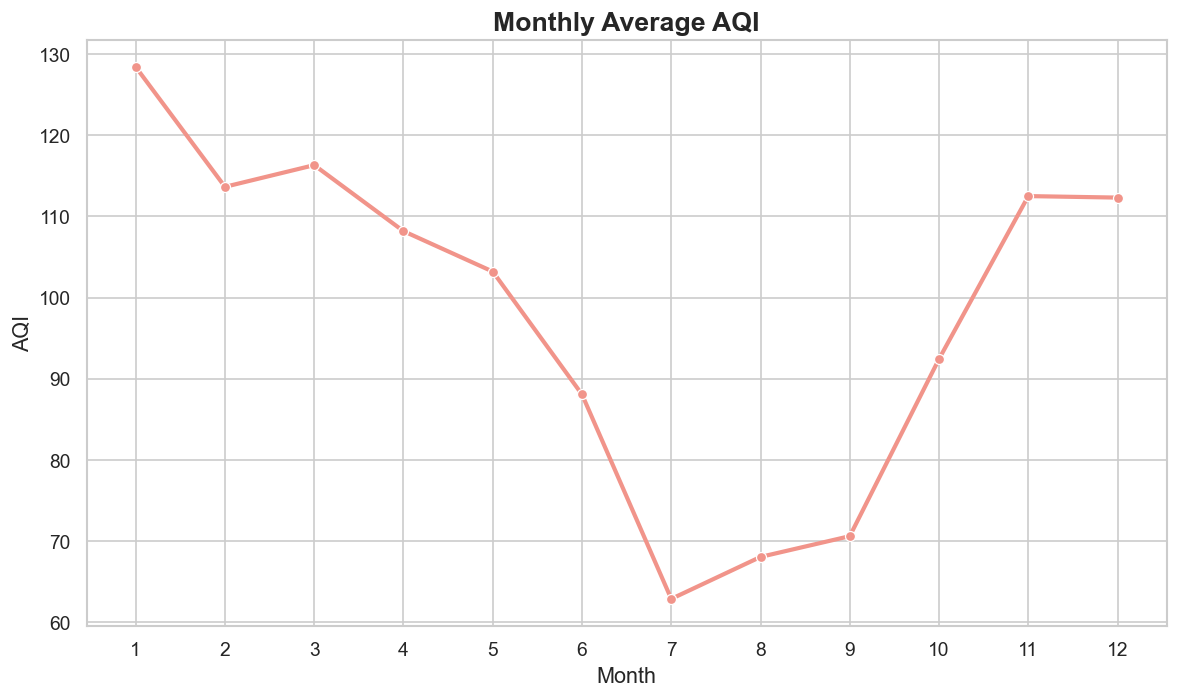

In [36]:
# Average AQI by month

monthly_aqi = (

    df

    .groupby("Month")["US_AQI"]

    .mean()

)

plt.figure(figsize=FIG_SIZE)

sns.lineplot(

    x=monthly_aqi.index,

    y=monthly_aqi.values,

    marker="o",

    linewidth=2.5,

    color=PALETTE[3]

)

plt.title("Monthly Average AQI")

plt.xlabel("Month")

plt.ylabel("AQI")

plt.xticks(range(1,13))

plt.tight_layout()

plt.show()

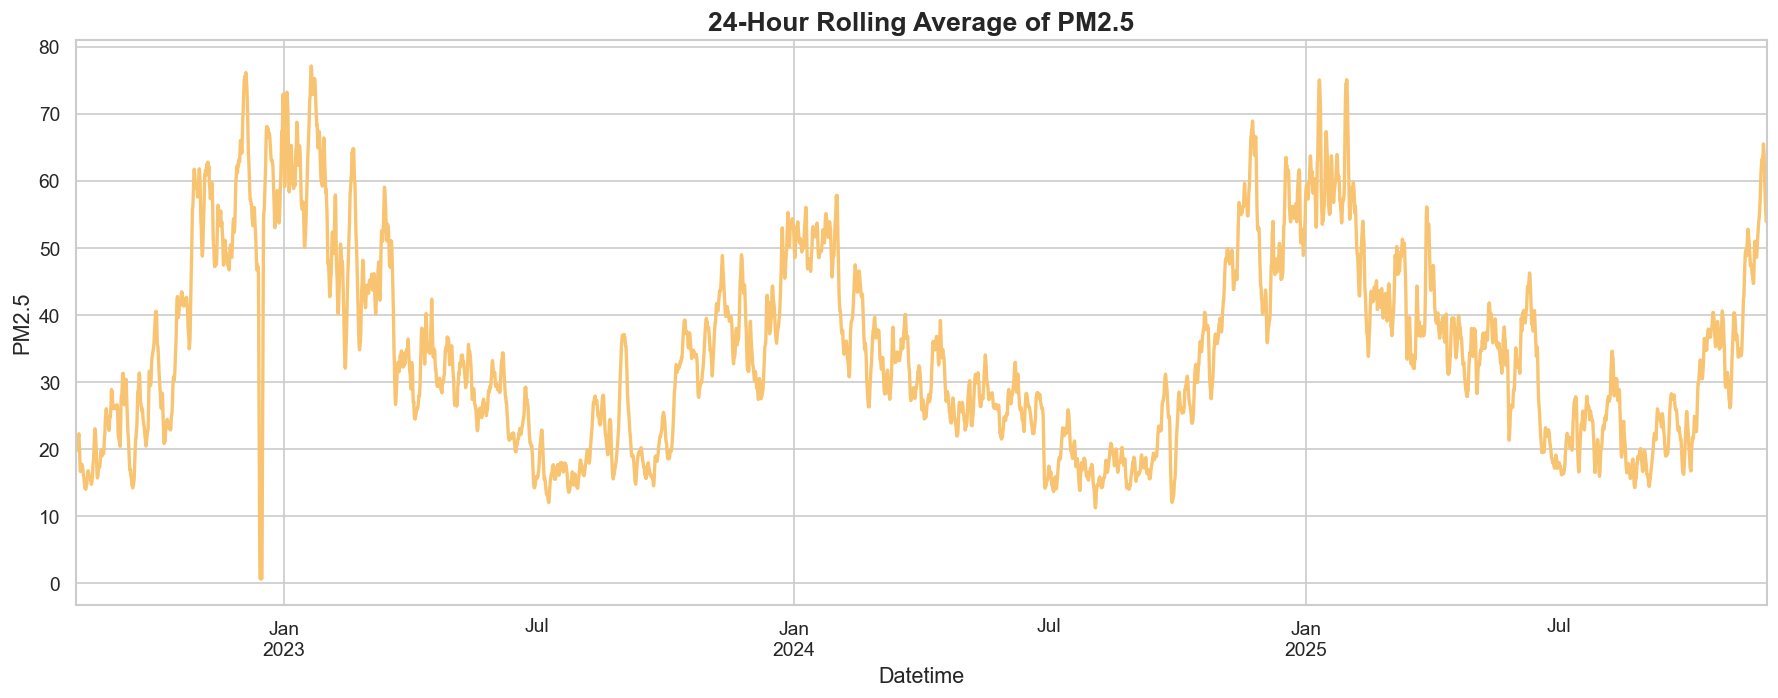

In [37]:
# Rolling PM2.5 trend

rolling_pm25 = (

    df

    .sort_values("Datetime")

    .groupby("Datetime")["PM2_5_ugm3"]

    .mean()

    .rolling(24)

    .mean()

)

plt.figure(figsize=(15,6))

rolling_pm25.plot(

    color=PALETTE[2],

    linewidth=2

)

plt.title("24-Hour Rolling Average of PM2.5")

plt.ylabel("PM2.5")

plt.tight_layout()

plt.show()

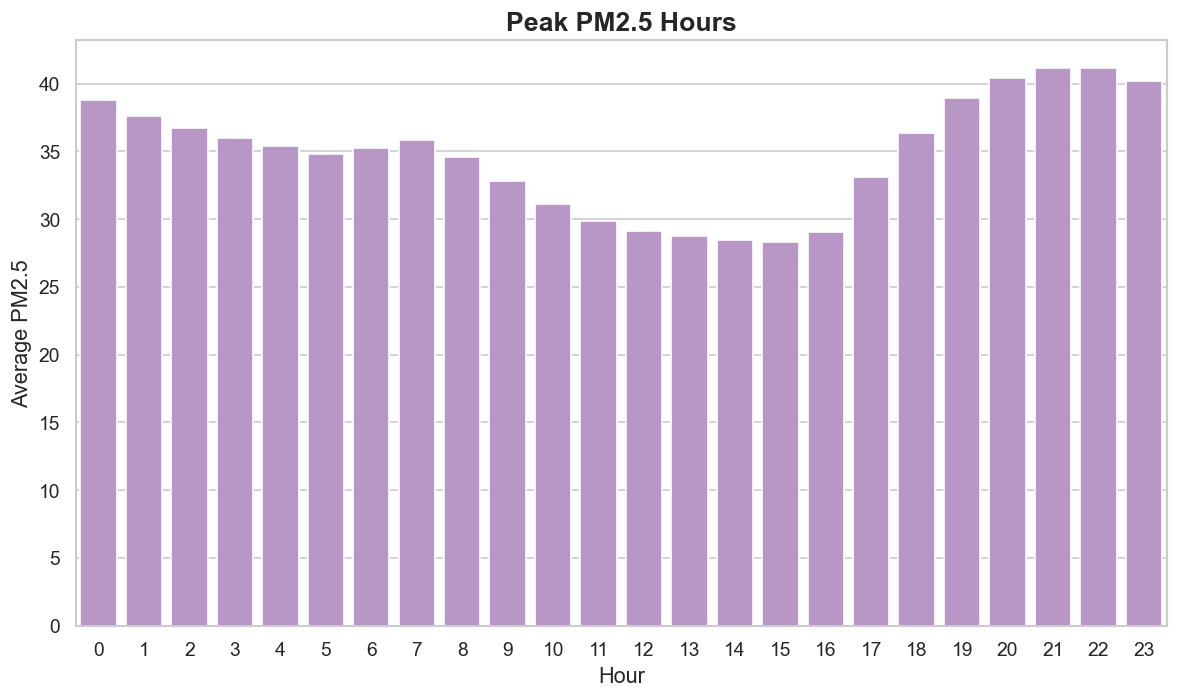

In [38]:
# Peak pollution hours

peak_hours = (

    df

    .groupby("Hour")["PM2_5_ugm3"]

    .mean()

    .sort_values(ascending=False)

)

plt.figure(figsize=FIG_SIZE)

sns.barplot(

    x=peak_hours.index,

    y=peak_hours.values,

    color=PALETTE[4]

)

plt.title("Peak PM2.5 Hours")

plt.xlabel("Hour")

plt.ylabel("Average PM2.5")

plt.tight_layout()

plt.show()

In [39]:
# Time-series summary

time_summary = pd.DataFrame({

    "Metric":[

        "Peak PM2.5 Hour",

        "Highest AQI Month",

        "Highest PM2.5 Month",

        "Lowest PM2.5 Month"

    ],

    "Value":[

        peak_hours.idxmax(),

        monthly_aqi.idxmax(),

        monthly_pollution["PM2_5_ugm3"].idxmax(),

        monthly_pollution["PM2_5_ugm3"].idxmin()

    ]

})

time_summary

,Metric,Value
0,Peak PM2.5 Hour,22
1,Highest AQI Month,1
2,Highest PM2.5 Month,1
3,Lowest PM2.5 Month,7


## 5. Multivariate & Correlation Analysis

Analyze relationships between pollutants, weather variables and engineered features to identify dependencies, multicollinearity and potential predictive patterns.

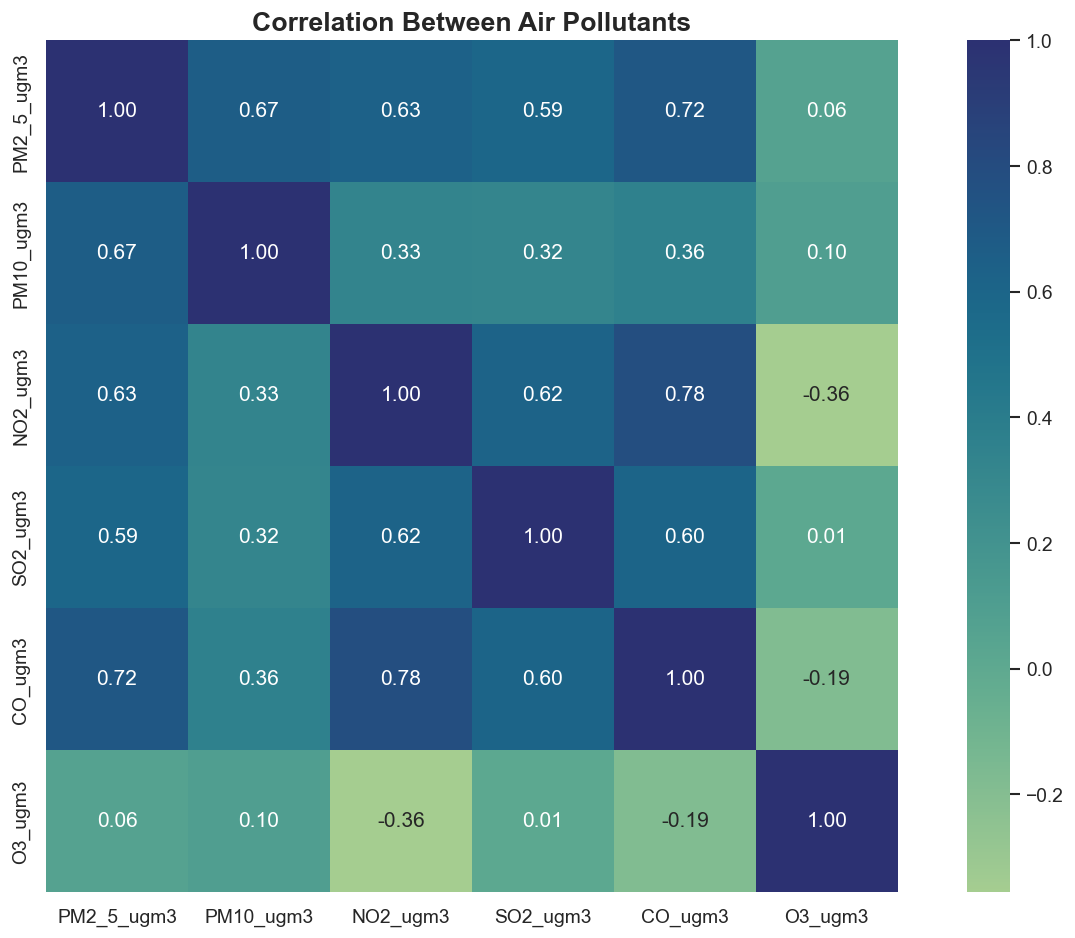

In [40]:
# Correlation among air pollutants

pollutant_corr = df[pollutant_cols].corr()

plt.figure(figsize=HEATMAP_SIZE)

sns.heatmap(

    pollutant_corr,

    cmap="crest",

    annot=True,

    fmt=".2f",

    square=True

)

plt.title("Correlation Between Air Pollutants")

plt.tight_layout()

plt.show()

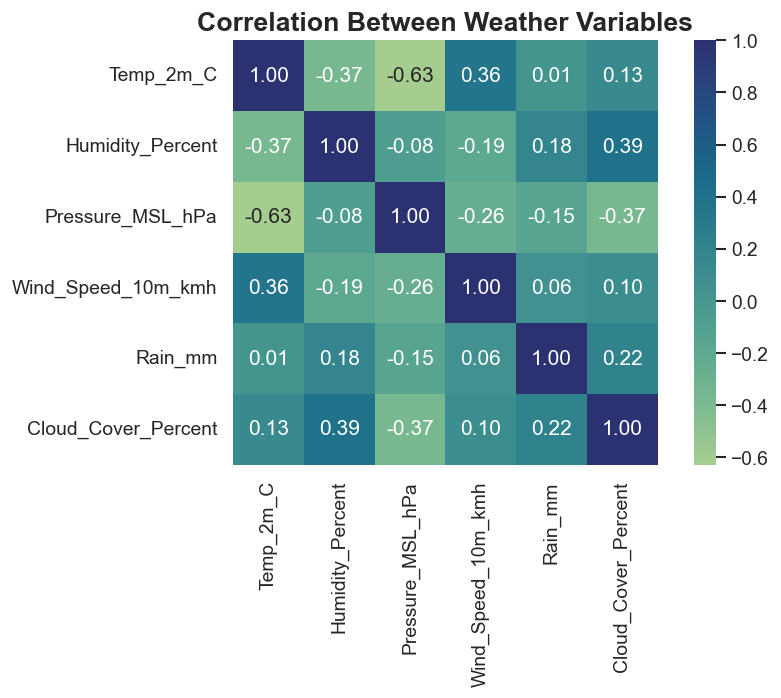

In [41]:
# Correlation among important weather variables

weather_cols = [

    "Temp_2m_C",

    "Humidity_Percent",

    "Pressure_MSL_hPa",

    "Wind_Speed_10m_kmh",

    "Rain_mm",

    "Cloud_Cover_Percent"

]

weather_corr = df[weather_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(

    weather_corr,

    cmap="crest",

    annot=True,

    fmt=".2f",

    square=True

)

plt.title("Correlation Between Weather Variables")

plt.tight_layout()

plt.show()

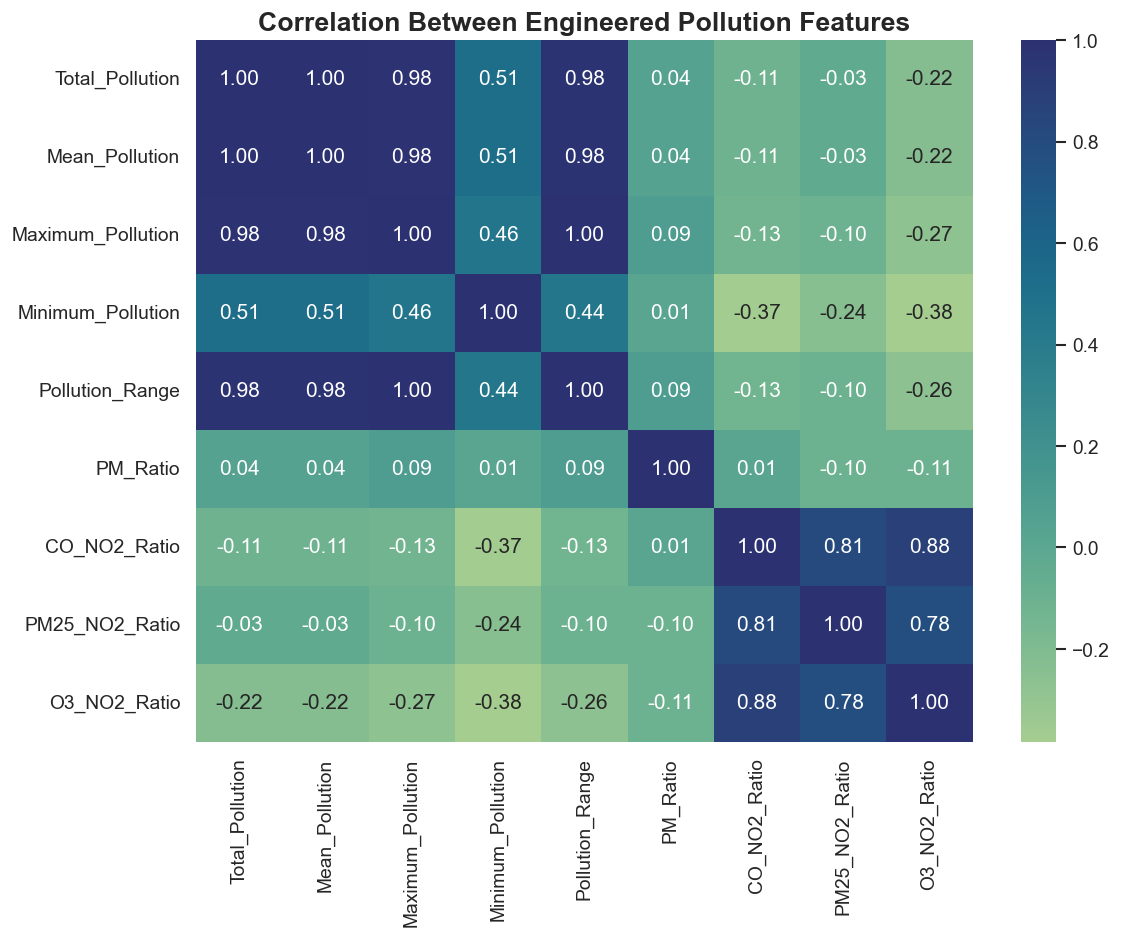

In [42]:
# Correlation between engineered pollution features

engineered_cols = [

    "Total_Pollution",

    "Mean_Pollution",

    "Maximum_Pollution",

    "Minimum_Pollution",

    "Pollution_Range",

    "PM_Ratio",

    "CO_NO2_Ratio",

    "PM25_NO2_Ratio",

    "O3_NO2_Ratio"

]

plt.figure(figsize=(10,8))

sns.heatmap(

    df[engineered_cols].corr(),

    cmap="crest",

    annot=True,

    fmt=".2f"

)

plt.title("Correlation Between Engineered Pollution Features")

plt.tight_layout()

plt.show()

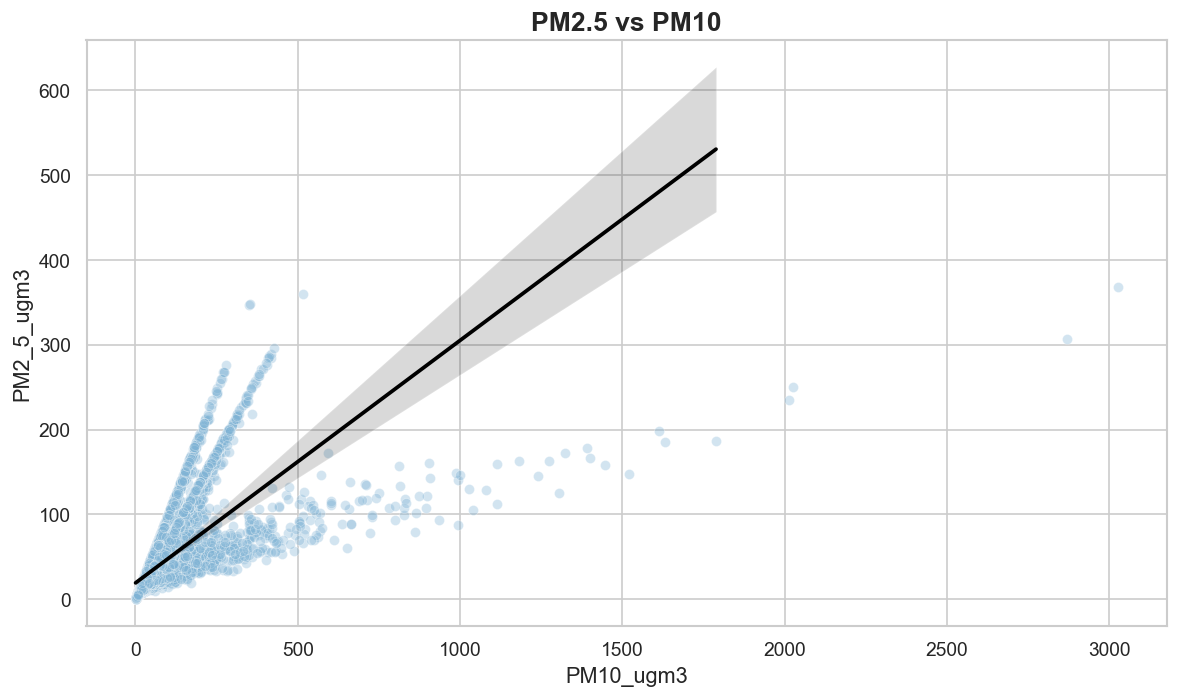

In [43]:
# Relationship between PM2.5 and PM10

plt.figure(figsize=FIG_SIZE)

sns.scatterplot(

    data=df.sample(25000, random_state=42),

    x="PM10_ugm3",

    y="PM2_5_ugm3",

    alpha=0.35,

    color=PALETTE[0]

)

sns.regplot(

    data=df.sample(8000, random_state=42),

    x="PM10_ugm3",

    y="PM2_5_ugm3",

    scatter=False,

    color="black"

)

plt.title("PM2.5 vs PM10")

plt.tight_layout()

plt.show()

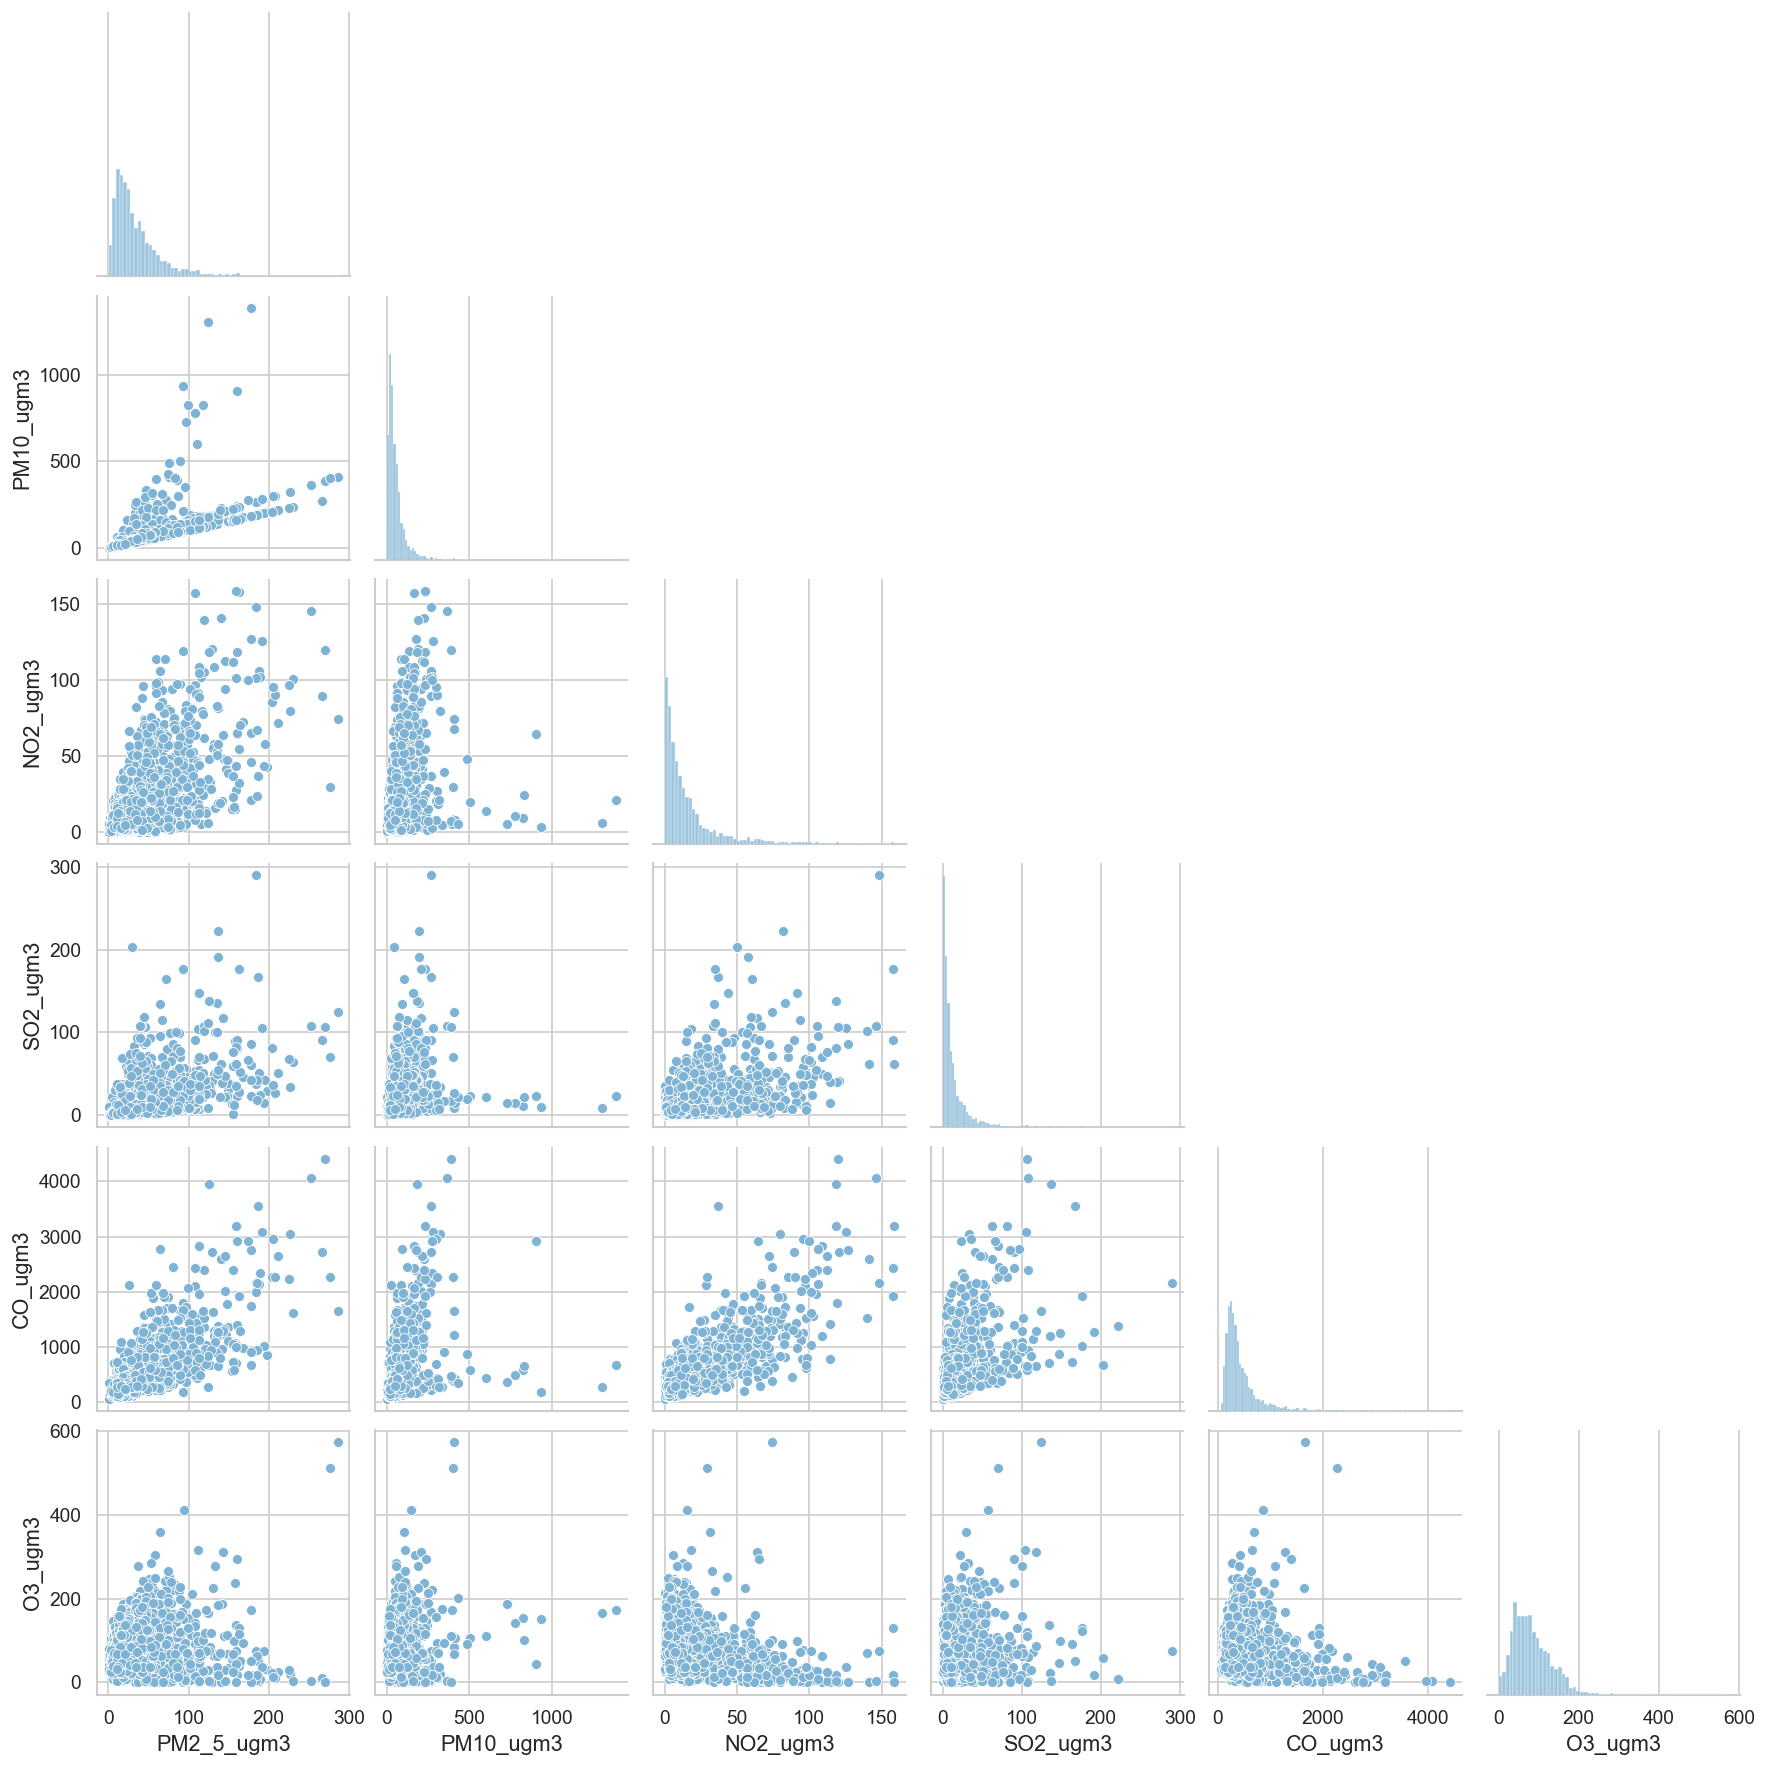

In [44]:
# Pairwise relationship among major pollutants

pair_pollutants = [

    "PM2_5_ugm3",

    "PM10_ugm3",

    "NO2_ugm3",

    "SO2_ugm3",

    "CO_ugm3",

    "O3_ugm3"

]

sns.pairplot(

    df[pair_pollutants].sample(2500, random_state=42),

    corner=True

)

plt.show()

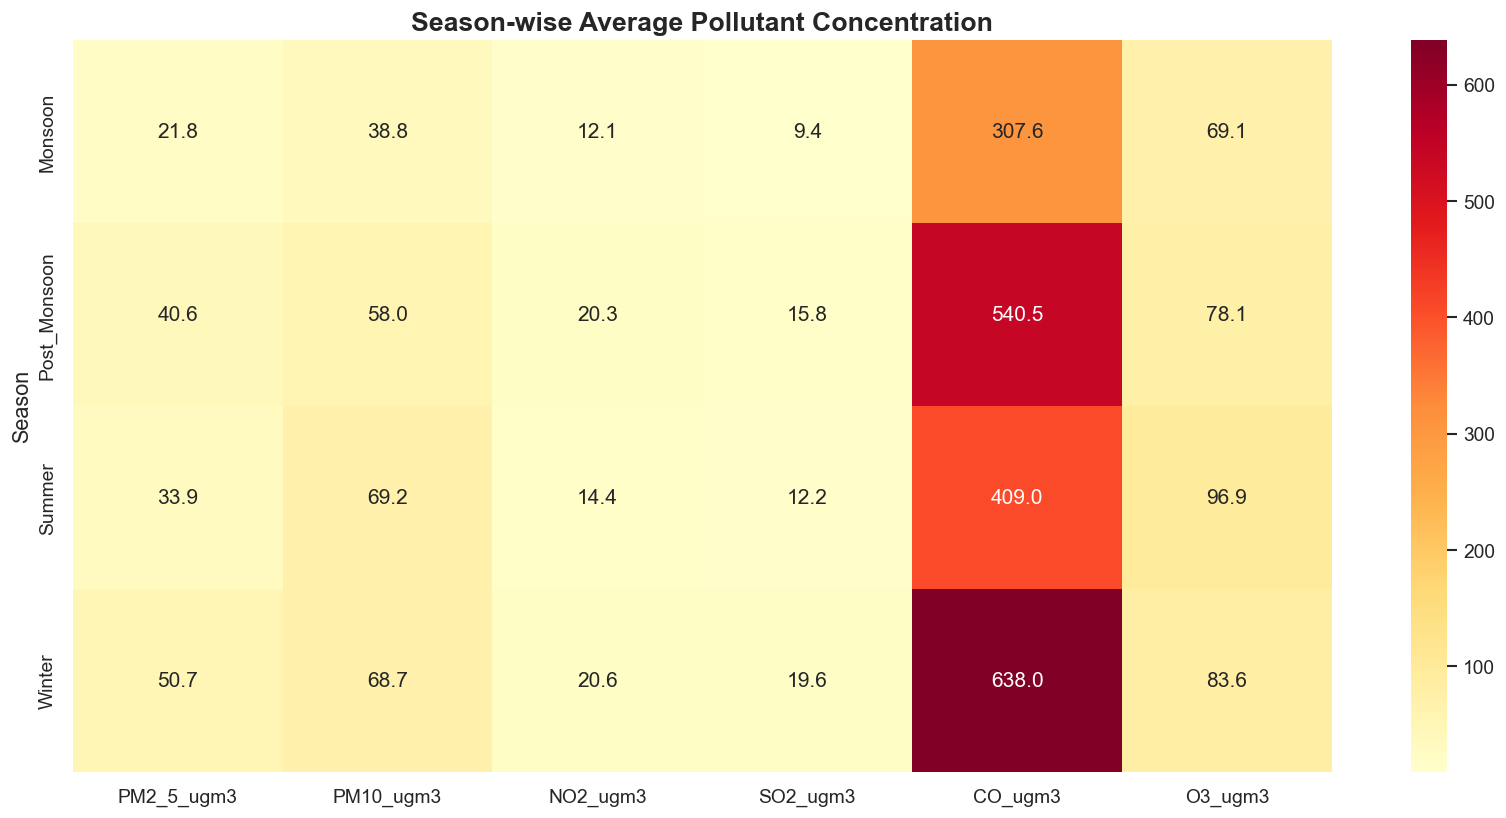

In [45]:
# Average pollutant concentration by season

season_pollution = (

    df

    .groupby("Season")[pollutant_cols]

    .mean()

)

plt.figure(figsize=(14,7))

sns.heatmap(

    season_pollution,

    cmap="YlOrRd",

    annot=True,

    fmt=".1f"

)

plt.title("Season-wise Average Pollutant Concentration")

plt.tight_layout()

plt.show()

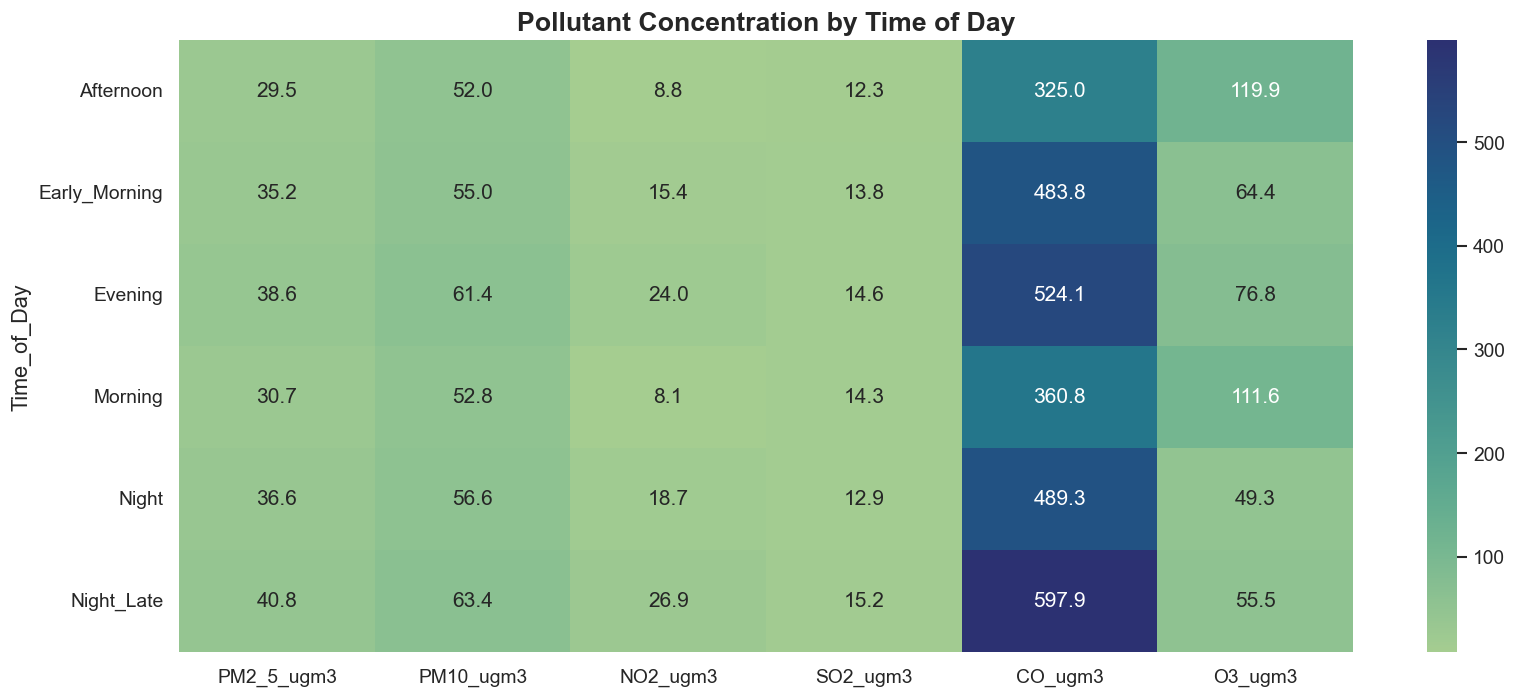

In [46]:
# Average pollutant concentration by time of day

time_pollution = (

    df

    .groupby("Time_of_Day")[pollutant_cols]

    .mean()

)

plt.figure(figsize=(14,6))

sns.heatmap(

    time_pollution,

    cmap="crest",

    annot=True,

    fmt=".1f"

)

plt.title("Pollutant Concentration by Time of Day")

plt.tight_layout()

plt.show()

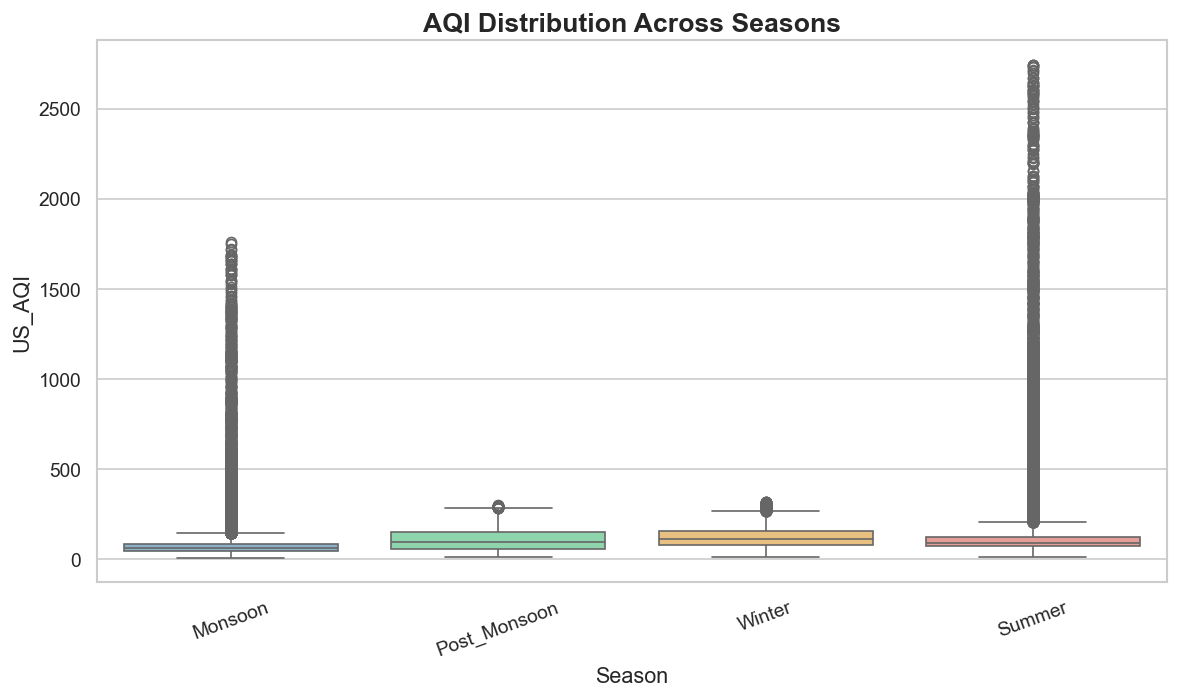

In [47]:
# Average AQI by season

plt.figure(figsize=FIG_SIZE)

sns.boxplot(

    data=df,

    x="Season",

    y="US_AQI",

    palette=PALETTE

)

plt.title("AQI Distribution Across Seasons")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

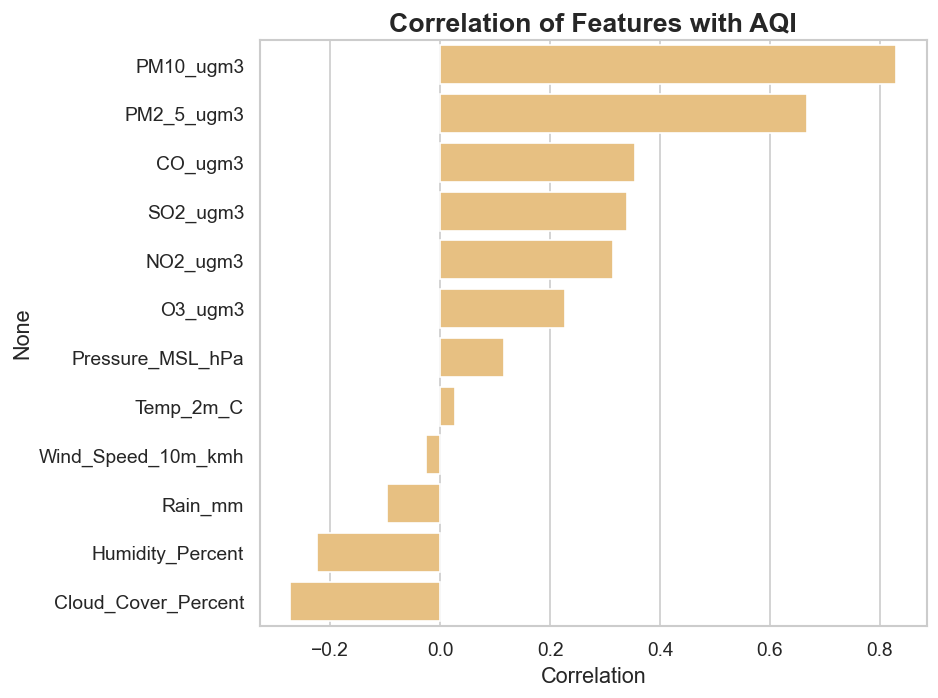

In [48]:
# Correlation with AQI

aqi_corr = (

    df[pollutant_cols + weather_cols + ["US_AQI"]]

    .corr()["US_AQI"]

    .sort_values(ascending=False)

)

aqi_corr = aqi_corr.drop("US_AQI")

plt.figure(figsize=(8,6))

sns.barplot(

    x=aqi_corr.values,

    y=aqi_corr.index,

    color=PALETTE[2]

)

plt.title("Correlation of Features with AQI")

plt.xlabel("Correlation")

plt.tight_layout()

plt.show()

In [49]:
# Summary of correlation analysis

correlation_summary = pd.DataFrame({

    "Metric":[

        "Highest AQI Correlation",

        "Highest Pollutant Correlation",

        "Highest Weather Correlation"

    ],

    "Feature":[

        aqi_corr.idxmax(),

        pollutant_corr.where(

            np.triu(

                np.ones(pollutant_corr.shape),

                k=1

            ).astype(bool)

        ).stack().idxmax(),

        weather_corr.where(

            np.triu(

                np.ones(weather_corr.shape),

                k=1

            ).astype(bool)

        ).stack().idxmax()

    ]

})

correlation_summary

,Metric,Feature
0,Highest AQI Correlation,PM10_ugm3
1,Highest Pollutant Correlation,"(NO2_ugm3, CO_ugm3)"
2,Highest Weather Correlation,"(Humidity_Percent, Cloud_Cover_Percent)"


## 6. Extreme Pollution Events

Analyze observations with exceptionally high pollution levels to identify the most severe air quality episodes.

In [50]:
# Top 20 highest PM2.5 observations

top_pm25 = (

    df

    .nlargest(

        20,

        "PM2_5_ugm3"

    )

)

top_pm25[
    [
        "City",
        "State",
        "Datetime",
        "PM2_5_ugm3",
        "US_AQI"
    ]
]

,City,State,Datetime,PM2_5_ugm3,US_AQI
586095,Mumbai,Maharashtra,2023-03-13 15:00:00,581.10,362.00
586094,Mumbai,Maharashtra,2023-03-13 14:00:00,510.40,369.00
586096,Mumbai,Maharashtra,2023-03-13 16:00:00,497.30,324.00
586093,Mumbai,Maharashtra,2023-03-13 13:00:00,478.70,307.00
586118,Mumbai,Maharashtra,2023-03-14 14:00:00,448.00,312.00
342958,Gurugram,Haryana,2025-04-10 22:00:00,443.30,1135.00
342957,Gurugram,Haryana,2025-04-10 21:00:00,429.30,1128.00
586092,Mumbai,Maharashtra,2023-03-13 12:00:00,427.50,265.00
342628,Gurugram,Haryana,2025-03-28 04:00:00,407.90,959.00
343172,Gurugram,Haryana,2025-04-19 20:00:00,395.80,1719.00


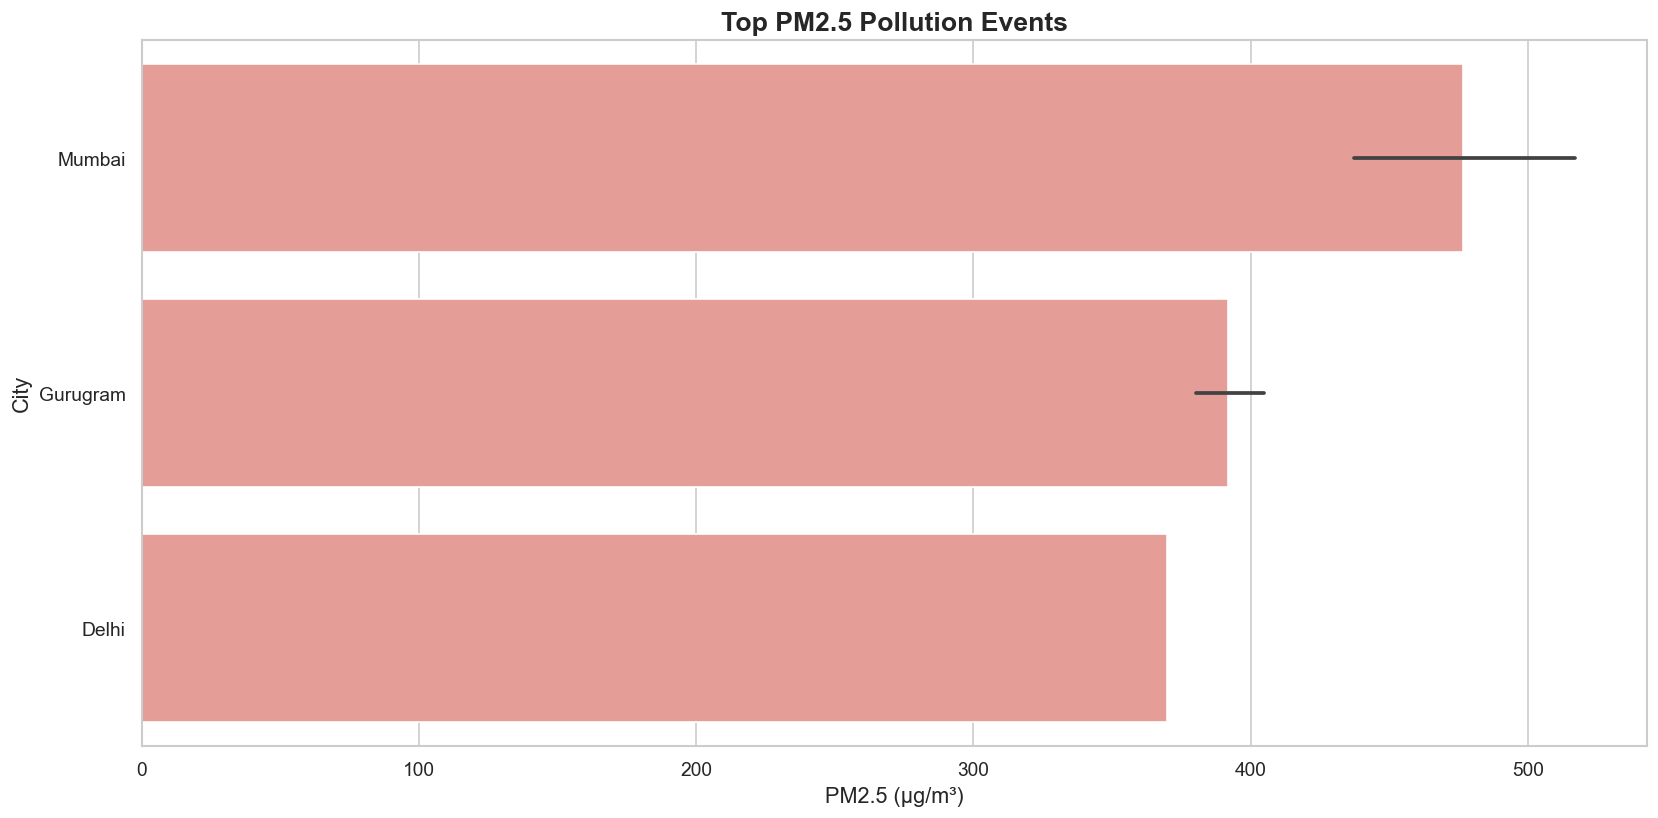

In [51]:
# Highest PM2.5 events by city

plt.figure(figsize=LARGE_FIG)

sns.barplot(

    data=top_pm25,

    x="PM2_5_ugm3",

    y="City",

    color=PALETTE[3]

)

plt.title("Top PM2.5 Pollution Events")

plt.xlabel("PM2.5 (μg/m³)")

plt.tight_layout()

plt.show()

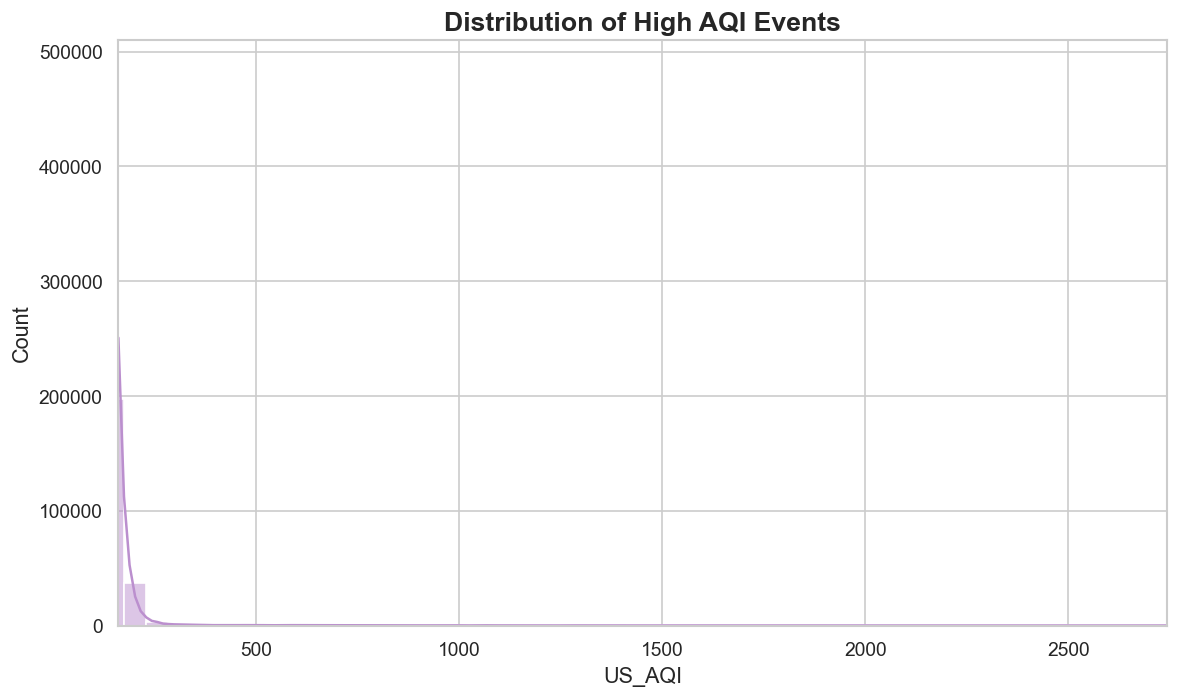

In [52]:
# Distribution of extreme AQI values

plt.figure(figsize=FIG_SIZE)

sns.histplot(

    df["US_AQI"],

    bins=50,

    kde=True,

    color=PALETTE[4]

)

plt.xlim(

    df["US_AQI"].quantile(0.90),

    df["US_AQI"].max()

)

plt.title("Distribution of High AQI Events")

plt.tight_layout()

plt.show()

## 7. Geospatial Analysis

Compare pollution levels across geographical locations using latitude and longitude information.

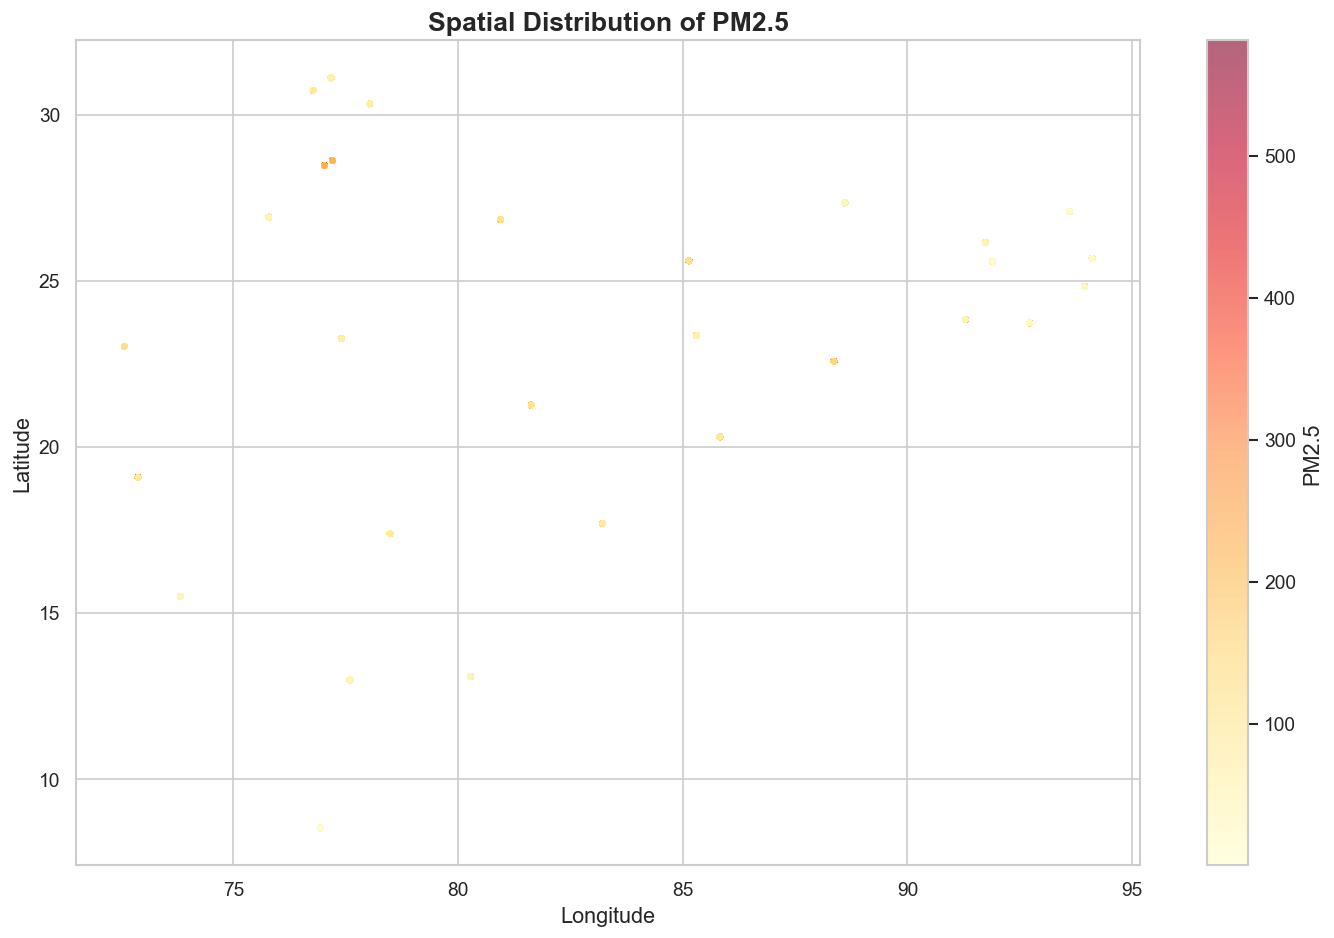

In [53]:
# Geographic distribution of PM2.5

plt.figure(figsize=(12,8))

scatter = plt.scatter(

    df["Longitude"],

    df["Latitude"],

    c=df["PM2_5_ugm3"],

    cmap="YlOrRd",

    s=8,

    alpha=0.6

)

plt.colorbar(scatter,label="PM2.5")

plt.xlabel("Longitude")

plt.ylabel("Latitude")

plt.title("Spatial Distribution of PM2.5")

plt.tight_layout()

plt.show()

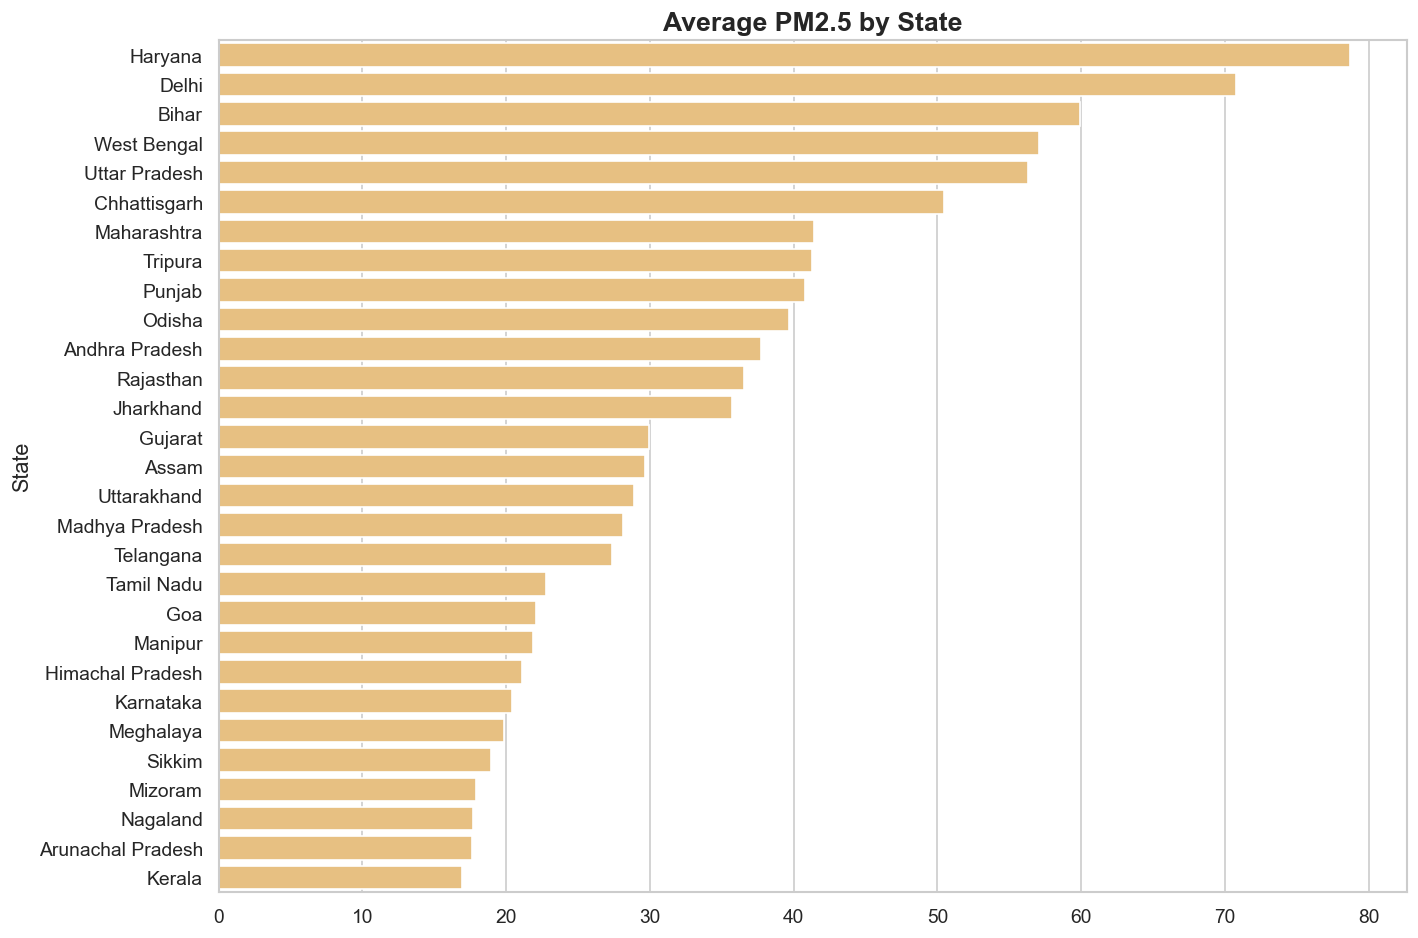

In [54]:
# Average PM2.5 by state

state_pm = (

    df

    .groupby("State")["PM2_5_ugm3"]

    .mean()

    .sort_values(ascending=False)

)

plt.figure(figsize=(12,8))

sns.barplot(

    x=state_pm.values,

    y=state_pm.index,

    color=PALETTE[2]

)

plt.title("Average PM2.5 by State")

plt.tight_layout()

plt.show()

## 8. Interactive Visualizations

Interactive charts provide dynamic exploration of pollution trends across cities and time.

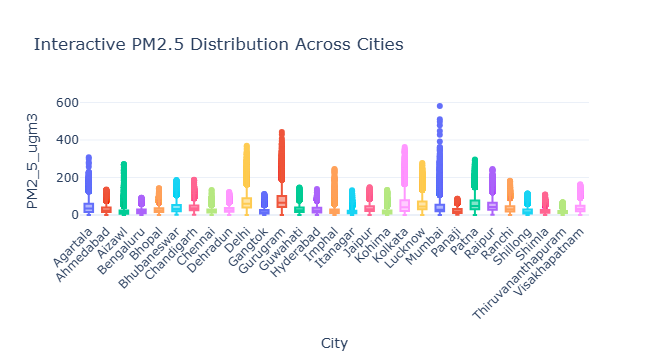

In [56]:
# Interactive PM2.5 by city

fig = px.box(

    df,

    x="City",

    y="PM2_5_ugm3",

    color="City",

    template=PLOTLY_TEMPLATE,

    title="Interactive PM2.5 Distribution Across Cities"

)

fig.update_layout(

    showlegend=False,

    xaxis_tickangle=-45

)

fig.show()

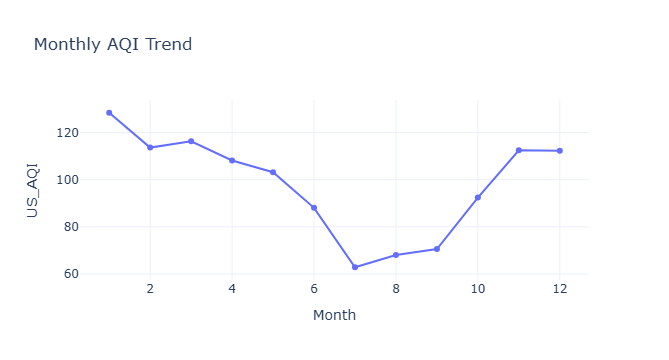

In [57]:
# Interactive monthly AQI trend

monthly = (

    df

    .groupby("Month")["US_AQI"]

    .mean()

    .reset_index()

)

fig = px.line(

    monthly,

    x="Month",

    y="US_AQI",

    markers=True,

    template=PLOTLY_TEMPLATE,

    title="Monthly AQI Trend"

)

fig.show()

In [58]:
# Interactive pollutant comparison

pollution_long = (

    df[pollutant_cols]

    .melt(

        var_name="Pollutant",

        value_name="Concentration"

    )

)

fig = px.box(

    pollution_long,

    x="Pollutant",

    y="Concentration",

    color="Pollutant",

    template=PLOTLY_TEMPLATE,

    title="Pollutant Distribution"

)

fig.show()

## Exploratory Data Analysis Summary

In [60]:
# Summary of EDA

eda_summary = pd.DataFrame({

    "Analysis":[

        "Dataset Overview",

        "Missing Value Analysis",

        "Univariate Analysis",

        "City-wise Analysis",

        "Weather vs Pollution",

        "Time-Series Analysis",

        "Correlation Analysis",

        "Extreme Pollution Analysis",

        "Geospatial Analysis",

        "Interactive Visualizations"

    ],

    "Status":[

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed"

    ]

})

eda_summary

,Analysis,Status
0,Dataset Overview,Completed
1,Missing Value Analysis,Completed
2,Univariate Analysis,Completed
3,City-wise Analysis,Completed
4,Weather vs Pollution,Completed
5,Time-Series Analysis,Completed
6,Correlation Analysis,Completed
7,Extreme Pollution Analysis,Completed
8,Geospatial Analysis,Completed
9,Interactive Visualizations,Completed
